<font face="B Mitra" size=4>
<div dir=rtl align=center>
<br>
<img src="https://aut.ac.ir/templates/tmpl_modern01/images/logo_fa.png" alt="Amirkabir University Logo" width="100">
<br>
<font size=6>
<b>پروژه سوم هوش مصنوعی</b>
<br>
<font size=5> استاد درس: دکتر مهدی قطعی و آقای بهنام یوسفی‌مهر
<br>
<font size=5> طراحان پروژه: ایلیا اسدی ، محمدرضا شیخ الاسلامی ، سید سینا نگهبان ، آرین جعفری
<br>
<font size=4> پاییز ۱۴۰۴
<hr>
</div>
</font>

### Import Libraries

In [1]:
!pip install opendatasets

In [2]:
import opendatasets as od
import pandas as pd
import numpy as np
import os
import opendatasets as od
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from imblearn.combine import SMOTEENN
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import RandomUnderSampler
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import RandomUnderSampler
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from scipy.stats import randint, uniform
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

### Load the dataset

You have to use the `opendatasets` library to download and then use it in either Google Colab or your local Jupyter Notebook

You can do the following steps:
- Create a Kaggle account
- Go to the Setting
- Find the API section
- Select **Create New Token**
- Now you have `Kaggle.json` file, which provides you your "kaggle username" and "kaggle key"

In [3]:
od.download("https://www.kaggle.com/datasets/priyamchoksi/100000-diabetes-clinical-dataset/data")

Dataset URL: https://www.kaggle.com/datasets/priyamchoksi/100000-diabetes-clinical-dataset


100%|██████████| 896k/896k [00:00<00:00, 537MB/s]

In [4]:

os.listdir("./100000-diabetes-clinical-dataset")


['diabetes_dataset.csv']

In [5]:
# read the csv file and make a data frame
# TODO

import pandas as pd

df = pd.read_csv("./100000-diabetes-clinical-dataset/diabetes_dataset.csv")
df.head()


,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
0,2020,Female,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100,0
1,2015,Female,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90,0
2,2015,Male,18.0,Alabama,0,0,0,0,1,0,0,never,23.76,4.8,160,0
3,2015,Male,41.0,Alabama,0,0,1,0,0,0,0,never,27.32,4.0,159,0
4,2016,Female,52.0,Alabama,1,0,0,0,0,0,0,never,23.75,6.5,90,0


---
<font color="#ffcc00">Answer the following question:

- Give a strong reason that why for each sample, only one value amongst African-American, Asian, Caucasian, Hispanic and Other races, is 1? Furthermore, explain are there any other ways to show all these 5 columns together?

<b> <font color='green'>Your Answer:</font></b><br>
سؤال:

یک دلیل قوی بده که چرا برای هر نمونه، فقط یک مقدار بین African-American ، Asian ، Caucasian ، Hispanic و Other races برابر 1 است؟
و همچنین توضیح بده آیا راه‌های دیگری هم وجود دارد که بتوان این ۵ ستون را با هم نشان داد؟

در این دیتاست، برای هر نمونه فقط یکی از ستون‌های African-American ، Asian ، Caucasian ، Hispanic و Other مقدار ۱ دارد، چون هر فرد فقط می‌تواند به یک نژاد خاص تعلق داشته باشد. بنابراین منطقی است که برای هر رکورد فقط یک مقدار برابر ۱ باشد و بقیه صفر باشند. این روش نمایش داده در یادگیری ماشین به آن One-Hot Encoding گفته می‌شود.

راه‌های دیگر برای نمایش این ۵ ستون وجود دارد. مثلاً می‌توانستیم فقط یک ستون داشته باشیم و نژاد هر فرد به صورت متن (categorical) در همان یک ستون ذخیره شود (مثل: “Asian” یا “Hispanic”). یا می‌توانستیم این ستون متنی را به عدد تبدیل کنیم (Label Encoding). اما معمولاً One-Hot Encoding برای الگوریتم‌های مدل‌های یادگیری ماشین بهتر کار می‌کند، چون مدل راحت‌تر تفاوت بین کلاس‌ها را متوجه می‌شود.
و در واقع  تبدیل به Label Encoding به این صورت است که
 بجای ۵ ستون، یک ستون داریم ولی مقدارش عددی هست (مثلاً Caucasian=0 ، Asian=1 ، Hispanic=2، ...).
ولی معمولاً برای مدل‌های ML، one-hot بهتر است.
</p>
</font>
<hr>

## Preprocessing

### Explore the Dataset

Now that we've loaded the dataset, it's time to explore it!
<br/>
In Data Science, Exploratory Data Analysis (EDA) is the process of analyzing datasets to summarize their main characteristics—often using statistical graphics, plots, and other visualization tools.
<br/>
<br/>
EDA typically involves two main parts:
- Numerical statistics
- Visual analysis

### Numerical statistics

describe the data, examine are there any missing values and find data types for each feature( you should use one cell for each of these tasks)

In [6]:
# TODO

# نمایش ۵ سطر اول برای درک ساختار داده‌ها
print(" 5 سطر اول DataFrame:")
df.head()


 5 سطر اول DataFrame:


,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
0,2020,Female,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100,0
1,2015,Female,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90,0
2,2015,Male,18.0,Alabama,0,0,0,0,1,0,0,never,23.76,4.8,160,0
3,2015,Male,41.0,Alabama,0,0,1,0,0,0,0,never,27.32,4.0,159,0
4,2016,Female,52.0,Alabama,1,0,0,0,0,0,0,never,23.75,6.5,90,0


In [7]:
# نمایش اطلاعات کلی شامل تعداد سطرها، ستون‌ها، مقادیر غیر تهی و نوع داده‌ها
print(" اطلاعات کلی DataFrame (شامل نوع داده‌ها و مقادیر غیر تهی):")
df.info()

 اطلاعات کلی DataFrame (شامل نوع داده‌ها و مقادیر غیر تهی):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   year                  100000 non-null  int64  
 1   gender                100000 non-null  object 
 2   age                   100000 non-null  float64
 3   location              100000 non-null  object 
 4   race:AfricanAmerican  100000 non-null  int64  
 5   race:Asian            100000 non-null  int64  
 6   race:Caucasian        100000 non-null  int64  
 7   race:Hispanic         100000 non-null  int64  
 8   race:Other            100000 non-null  int64  
 9   hypertension          100000 non-null  int64  
 10  heart_disease         100000 non-null  int64  
 11  smoking_history       100000 non-null  object 
 12  bmi                   100000 non-null  float64
 13  hbA1c_level           100000 non-null  float6

In [8]:
# آمار توصیفی برای ستون‌های عددی (Numerical Statistics)
print(" آمار توصیفی برای ستون‌های عددی:")
df.describe()

 آمار توصیفی برای ستون‌های عددی:


,year,age,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,bmi,hbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,2018.360820,41.885856,0.202230,0.200150,0.198760,0.19888,0.199980,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,1.345239,22.516840,0.401665,0.400114,0.399069,0.39916,0.399987,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,2015.000000,0.080000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,2019.000000,24.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,2019.000000,43.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,2019.000000,60.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,2022.000000,80.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [9]:
# محاسبه تعداد مقادیر گمشده (NaN) در هر ستون
print(" تعداد مقادیر گمشده (Missing Values) در هر ستون:")
df.isnull().sum()


 تعداد مقادیر گمشده (Missing Values) در هر ستون:


,0
year,0
gender,0
age,0
location,0
race:AfricanAmerican,0
race:Asian,0
race:Caucasian,0
race:Hispanic,0
race:Other,0
hypertension,0


In [10]:
# آمار توصیفی برای ستون‌های دسته‌ای (Categorical/Object)
print(" آمار توصیفی برای ستون‌های دسته‌ای:")
df.describe(include='object')

 آمار توصیفی برای ستون‌های دسته‌ای:


,gender,location,smoking_history
count,100000,100000,100000
unique,3,55,6
top,Female,Kentucky,No Info
freq,58552,2038,35816


### Data Visualization and Visual Analysis

Now, we need to find some relations between features as well as between the target column and features. This helps us understand the shape of the data, detect outliers, and identify potential data quality issues or patterns.

#### How to detect whether our data is `Imbalanced` or not?

First, you have to count the number of samples in each class, then plot both `pie chart` and `count plot` to achieve a visualization of what you did

In [11]:
# TODO

# شمارش مقادیر در ستون هدف 'diabetes'
class_counts = df['diabetes'].value_counts()

print(" تعداد نمونه‌ها در هر کلاس (0: عدم دیابت، 1: دیابت):")
print(class_counts)

# محاسبه درصد هر کلاس
total_samples = len(df)
class_percentage = (class_counts / total_samples) * 100

print("\n٪ درصد نمونه‌ها در هر کلاس:")
print(class_percentage)

# اگر درصد یک کلاس بسیار کمتر از بقیه باشد (مثلاً زیر 10%)، داده‌ها نامتوازن هستند.
if class_percentage.min() < 10:
    print("\n داده‌ها نامتوازن (Imbalanced) هستند!")
else:
    print("\n داده‌ها از لحاظ تعداد کلاس‌ها نسبتاً متعادل هستند.")

 تعداد نمونه‌ها در هر کلاس (0: عدم دیابت، 1: دیابت):
diabetes
0    91500
1     8500
Name: count, dtype: int64

٪ درصد نمونه‌ها در هر کلاس:
diabetes
0    91.5
1     8.5
Name: count, dtype: float64

 داده‌ها نامتوازن (Imbalanced) هستند!


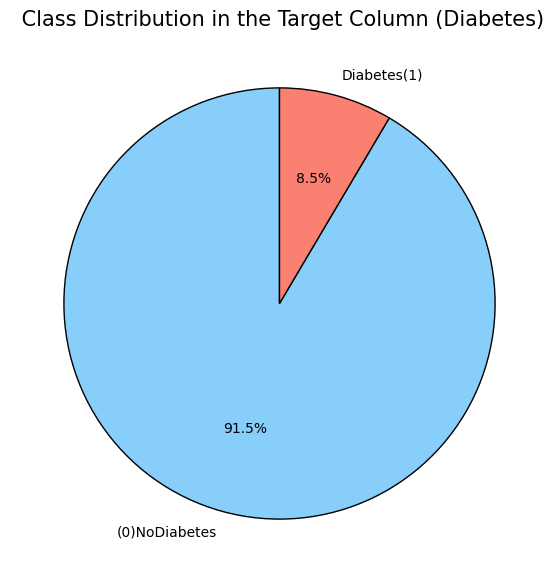

In [12]:
# TODO


# تنظیمات نمودار دایره‌ای
plt.figure(figsize=(7, 7))
class_counts.plot(
    kind='pie',
    autopct='%1.1f%%',  # نمایش درصد با یک رقم اعشار
    startangle=90,
    colors=['lightskyblue', 'salmon'],  # رنگ‌های دلخواه
    labels=['(0)NoDiabetes', 'Diabetes(1)'],
    wedgeprops={'edgecolor': 'black'}
)

plt.title(' Class Distribution in the Target Column (Diabetes)', fontsize=15)
plt.ylabel('')  # حذف عنوان محور Y که غیرضروری است
plt.show()

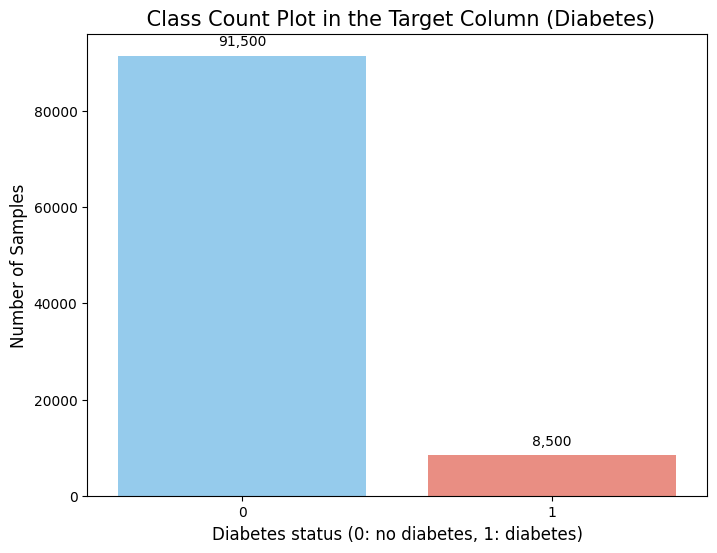

In [13]:
# TODO


# تنظیمات نمودار شمارش
plt.figure(figsize=(8, 6))
sns.countplot(x='diabetes', data=df, palette=['lightskyblue', 'salmon'])

plt.title(' Class Count Plot in the Target Column (Diabetes)', fontsize=15)
plt.xlabel('Diabetes status (0: no diabetes, 1: diabetes)', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)

# نمایش تعداد بالای هر میله
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height()):,}',
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha = 'center', va = 'center',
                       xytext = (0, 10),
                       textcoords = 'offset points',
                       fontsize=10)

plt.show()

#### Exploring the relation between gender and diabetes

In [14]:
# TODO
# 1. ایجاد جدول متقاطع (Crosstab) برای مشاهده رابطه بین gender و diabetes
gender_diabetes_crosstab = pd.crosstab(df['gender'], df['diabetes'])
print(" Crosstabulation of Gender and Diabetes (Columns: 0=Non-Diabetic, 1=Diabetic):")
print(gender_diabetes_crosstab)

# 2. محاسبه درصد برای هر گروه جنسیتی
gender_diabetes_percentage = pd.crosstab(df['gender'], df['diabetes'], normalize='index') * 100
print("\n Percentage of Diabetic and Non-Diabetic individuals within each Gender group:")
print(gender_diabetes_percentage)

 Crosstabulation of Gender and Diabetes (Columns: 0=Non-Diabetic, 1=Diabetic):
diabetes      0     1
gender               
Female    54091  4461
Male      37391  4039
Other        18     0

 Percentage of Diabetic and Non-Diabetic individuals within each Gender group:
diabetes           0         1
gender                        
Female     92.381131  7.618869
Male       90.251026  9.748974
Other     100.000000  0.000000


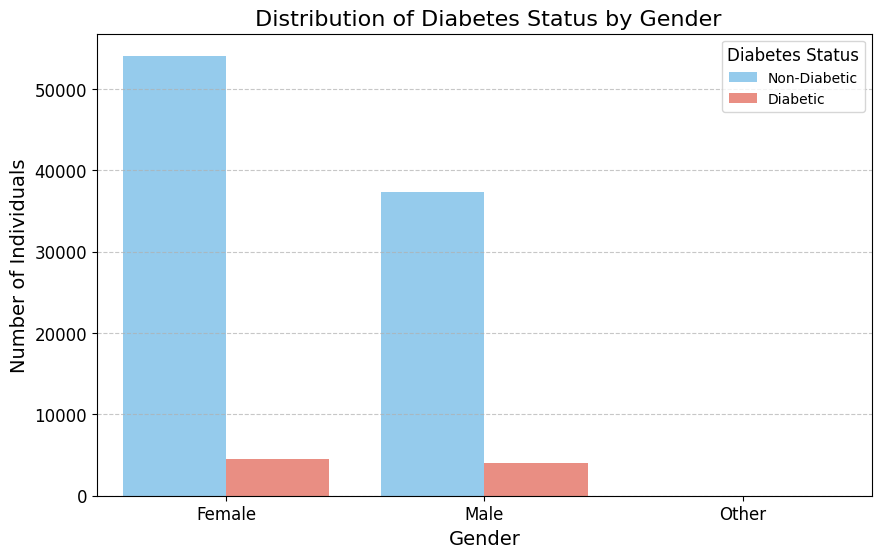

In [15]:


# رسم نمودار Count Plot با تفکیک رنگی بر اساس ستون هدف
plt.figure(figsize=(10, 6))

# استفاده از ستون اصلی 'gender'
sns.countplot(x='gender', hue='diabetes', data=df, palette=['lightskyblue', 'salmon'])

# --- تنظیمات انگلیسی سازی نمودار ---
plt.title(' Distribution of Diabetes Status by Gender', fontsize=16)
plt.xlabel('Gender', fontsize=14)
plt.ylabel('Number of Individuals', fontsize=14)

# انگلیسی سازی Legend (راهنمای نمودار)
legend_labels = ['Non-Diabetic', 'Diabetic']
plt.legend(title='Diabetes Status', labels=legend_labels, fontsize=10, title_fontsize='12')

plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

---
<font color="#ffcc00">Answer the following question:

- What percentage of men have Diabetes?

<b> <font color='green'>Your Answer:</font></b><br>

با توجه به  اطلاعات بدست آمده از  جدول متقاطع  9.748974 درصد از  مرد ها دیابت دارند
</p>
</font>
<hr>

#### Exploring the relation between age and diabetes(Age Distribution by Diabetes Status)

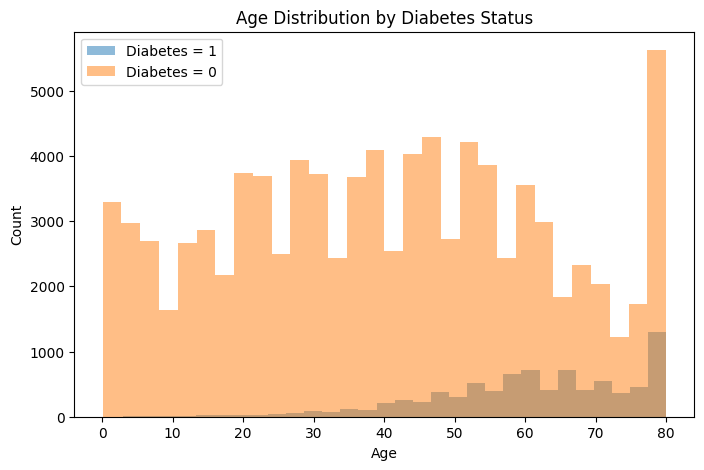

In [16]:
# TODO

# فرض میکنیم ستون diabetes یک ستون 0 و 1 هست
diabetic = df[df['diabetes'] == 1]['age']
non_diabetic = df[df['diabetes'] == 0]['age']

plt.figure(figsize=(8,5))
plt.hist(diabetic, bins=30, alpha=0.5, label='Diabetes = 1')
plt.hist(non_diabetic, bins=30, alpha=0.5, label='Diabetes = 0')
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Age Distribution by Diabetes Status')
plt.legend()
plt.show()


#### Exploring the relation between BMI and diabetes, hbA1c and diabetes and blood Glucose and diabetes

At this point, We need to find outliers and ommit them from the dataset, compare their medians and so on.

---
<font color="#ffcc00">Answer the following question:

- Which plot is appropriate for this purpose? Why?

برای این نوع بررسی، نمودار Box Plot مناسب‌ترین نمودار است، زیرا Box Plot مقدارهای خارج از محدوده (outlier) را به شکل واضح نمایش می‌دهد، توزیع داده را برای دو گروه دیابتی و غیر دیابتی به طور همزمان نشان می‌دهد، و همچنین امکان مقایسه‌ی مستقیم میانه (median) را بین این دو گروه فراهم می‌کند. به همین دلیل، برای مقایسه‌ی BMI، HbA1c و قند خون بین بیماران دیابتی و غیر دیابتی، Box Plot بهترین انتخاب است.

<Figure size 500x400 with 0 Axes>

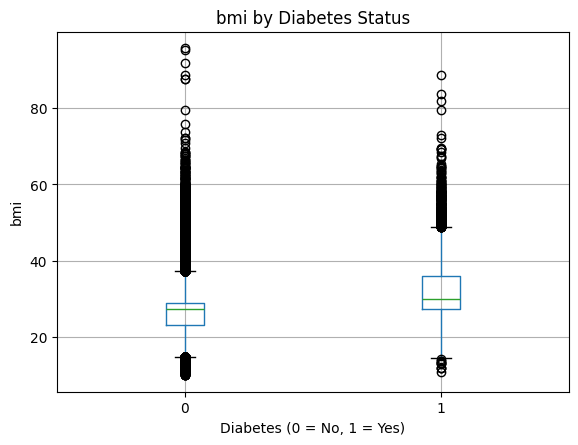

<Figure size 500x400 with 0 Axes>

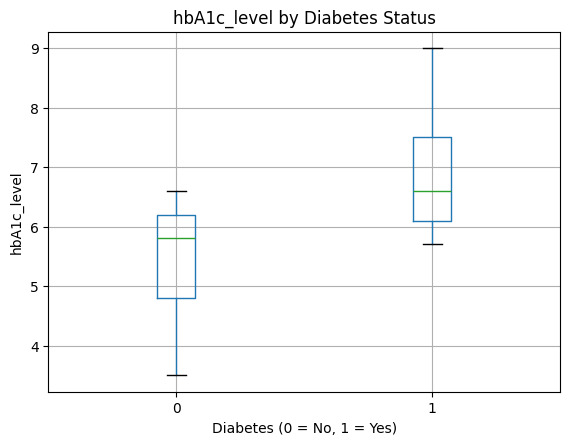

<Figure size 500x400 with 0 Axes>

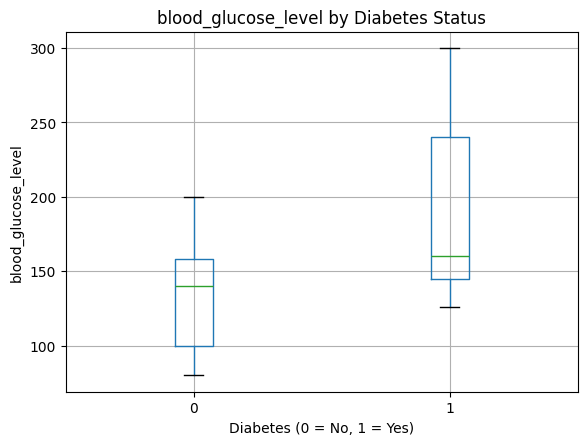

In [17]:
# TODO

features = ['bmi', 'hbA1c_level', 'blood_glucose_level']

for feature in features:
    plt.figure(figsize=(5,4))
    df.boxplot(column=feature, by='diabetes')
    plt.title(f'{feature} by Diabetes Status')
    plt.suptitle('')
    plt.xlabel('Diabetes (0 = No, 1 = Yes)')
    plt.ylabel(feature)
    plt.show()


Now, remove outliers

In [18]:
# TODO

# remove outliers using IQR method
for feature in ['bmi', 'hbA1c_level', 'blood_glucose_level']:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5*IQR
    upper_bound = Q3 + 1.5*IQR
    df = df[(df[feature] >= lower_bound) & (df[feature] <= upper_bound)]

df.reset_index(drop=True, inplace=True)


#### The relation between hypertension, heart disease and smoking history, with diabetes, based on precentage


Columns: ['year', 'gender', 'age', 'location', 'race:AfricanAmerican', 'race:Asian', 'race:Caucasian', 'race:Hispanic', 'race:Other', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'hbA1c_level', 'blood_glucose_level', 'diabetes']

Percentage diabetic by hypertension status:
 hypertension
0     4.043669
1    18.200202
Name: diabetes, dtype: float64


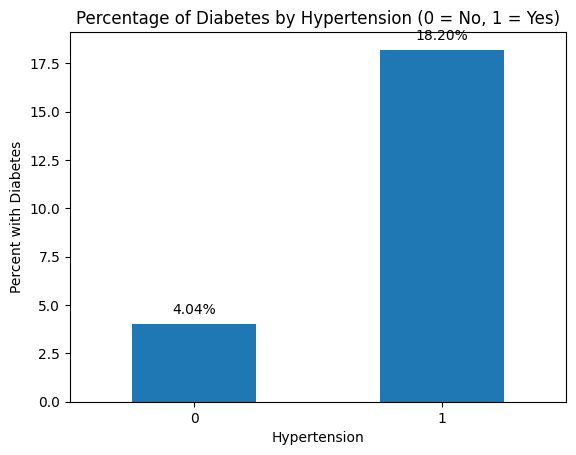


Percentage diabetic by heart disease status:
 heart_disease
0     4.364037
1    21.459627
Name: diabetes, dtype: float64


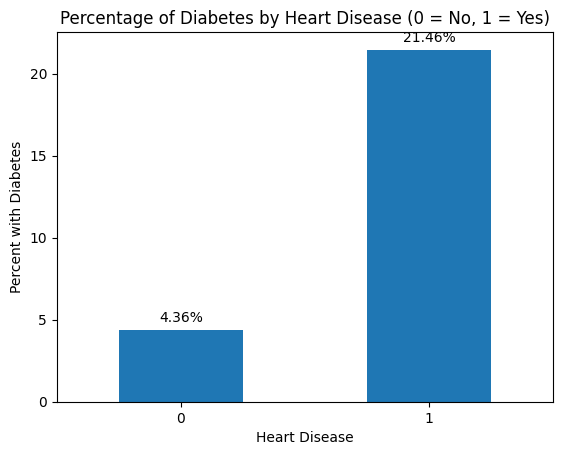


Percentage diabetic by smoking_history:
 smoking_history
former         10.787353
ever            7.199322
not current     5.934409
current         5.844156
never           5.569161
No Info         2.378232
Name: diabetes, dtype: float64


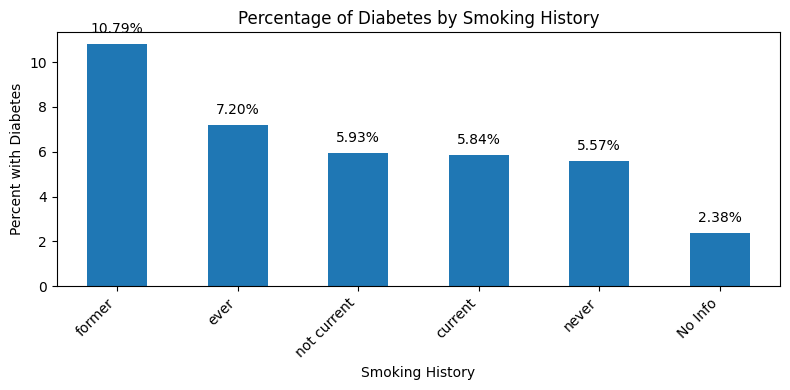


Summary (dict) ready for report/printing:
 {'hypertension': {0: 4.043669259824991, 1: 18.200202224469162}, 'heart_disease': {0: 4.364036848807461, 1: 21.459627329192546}, 'smoking_history_percent': {'former': 10.787352758834471, 'ever': 7.199322416713722, 'not current': 5.9344091618948465, 'current': 5.844155844155844, 'never': 5.569161286218631, 'No Info': 2.3782321106434154}}


In [19]:
# TODO

# نمایش نام ستون‌ها (برای اطمینان از اسم درست ستون‌ها)
print("Columns:", df.columns.tolist())

# ---------- 1) Hypertension vs Diabetes (percentage) ----------
# درصد دیابتی‌ها بین افراد با و بدون هایپرتنشن
hypertension_pct = df.groupby('hypertension')['diabetes'].mean() * 100
print("\nPercentage diabetic by hypertension status:\n", hypertension_pct)

# رسم نمودار ستونی برای hypertension
import matplotlib.pyplot as plt

hypertension_pct.plot(kind='bar')
plt.title('Percentage of Diabetes by Hypertension (0 = No, 1 = Yes)')
plt.xlabel('Hypertension')
plt.ylabel('Percent with Diabetes')
plt.xticks(rotation=0)
# نمایش عدد درصد بالای هر ستون
for i, v in enumerate(hypertension_pct):
    plt.text(i, v + 0.5, f"{v:.2f}%", ha='center')
plt.show()


# ---------- 2) Heart Disease vs Diabetes (percentage) ----------
heart_pct = df.groupby('heart_disease')['diabetes'].mean() * 100
print("\nPercentage diabetic by heart disease status:\n", heart_pct)

heart_pct.plot(kind='bar')
plt.title('Percentage of Diabetes by Heart Disease (0 = No, 1 = Yes)')
plt.xlabel('Heart Disease')
plt.ylabel('Percent with Diabetes')
plt.xticks(rotation=0)
for i, v in enumerate(heart_pct):
    plt.text(i, v + 0.5, f"{v:.2f}%", ha='center')
plt.show()


# ---------- 3) Smoking History vs Diabetes (percentage) ----------
# برای متغیرهای متنی یا دسته‌ای (مثلاً 'smoking_history'):
smoke_pct = df.groupby('smoking_history')['diabetes'].mean() * 100
smoke_pct = smoke_pct.sort_values(ascending=False)  # مرتب سازی از بیشترین به کمترین برای نمایش بهتر
print("\nPercentage diabetic by smoking_history:\n", smoke_pct)

# رسم نمودار ستونی برای smoking_history
smoke_pct.plot(kind='bar', figsize=(8,4))
plt.title('Percentage of Diabetes by Smoking History')
plt.xlabel('Smoking History')
plt.ylabel('Percent with Diabetes')
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(smoke_pct):
    plt.text(i, v + 0.5, f"{v:.2f}%", ha='center', rotation=0)
plt.tight_layout()
plt.show()


# ---------- خلاصه‌ی عددی برای استفاده در گزارش ----------
summary = {
    'hypertension': hypertension_pct.to_dict(),
    'heart_disease': heart_pct.to_dict(),
    'smoking_history_percent': smoke_pct.to_dict()
}
print("\nSummary (dict) ready for report/printing:\n", summary)


---
<font color="#ffcc00">Answer the following questions:

- What percentage of samples with Heart Disease are Diabetic?
- Based on smoking history, which group of samples has the highest rate of Diabetes?

<b> <font color='green'>Your Answer:</font></b><br>
ا 2 سؤال:

چه درصدی از نمونه‌هایی که بیماری قلبی دارند، دیابتی هستند؟

با توجه به سابقه‌ی سیگار کشیدن، کدام گروه بیشترین نرخ دیابت را دارد؟

در این داده‌ها، حدود ۲۱.۴۵٪ از افرادی که بیماری قلبی دارند، دیابتی هستند.
همچنین بر اساس smoking_history، گروه former یعنی افرادی که قبلاً سیگار می‌کشیدند ولی الان دیگر نمی‌کشند، بالاترین نرخ دیابت را دارد و درصد دیابت در این گروه حدود ۱۰.۷۸٪ است.
</p>
</font>
<hr>

In [20]:
# TODO                                        این قسمت برای  چیه =)))

#### Exploring the trend of diabetes based on year column

year
2015     5.070458
2016     4.991110
2018     5.230386
2019     4.952362
2020     2.702703
2021    14.285714
2022     0.000000
Name: diabetes, dtype: float64


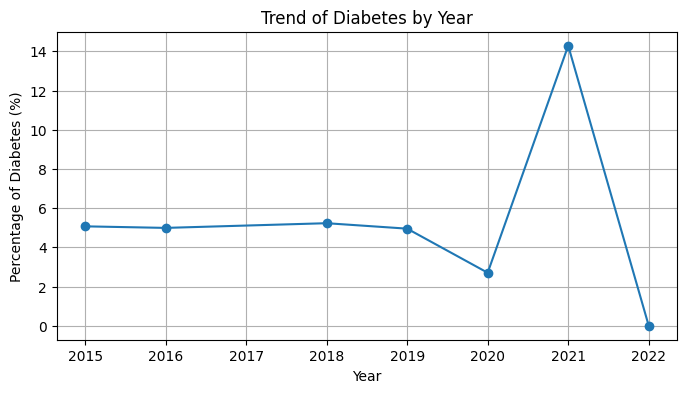

In [21]:
# TODO

# درصد دیابتی ها در هر سال
trend_by_year = df.groupby('year')['diabetes'].mean() * 100

print(trend_by_year)

# رسم نمودار خطی (برای دیدن تغییرات در طول سال ها)


plt.figure(figsize=(8,4))
plt.plot(trend_by_year.index, trend_by_year.values, marker='o')
plt.xlabel('Year')
plt.ylabel('Percentage of Diabetes (%)')
plt.title('Trend of Diabetes by Year')
plt.grid(True)
plt.show()


### Feature Selection and Feature Engineering

Based on the previous step, you have to decide which features could be helpful? Moreover, what other featuers could potentially/should be added?

In [22]:
# محاسبه درصد دیابت برای هر race

race_cols = [
    'race:AfricanAmerican', 'race:Asian', 'race:Caucasian', 'race:Hispanic', 'race:Other'
]

for col in race_cols:
    percent = df[df[col] == 1]['diabetes'].mean() * 100
    print(col, " --> diabetes rate: ", round(percent, 2), "%")


race:AfricanAmerican  --> diabetes rate:  5.17 %
race:Asian  --> diabetes rate:  5.11 %
race:Caucasian  --> diabetes rate:  5.07 %
race:Hispanic  --> diabetes rate:  4.89 %
race:Other  --> diabetes rate:  4.62 %


In [23]:
# انتخاب فیچرهای مهم بر اساس آنالیزهای قبلی
selected_features = [
    'age',
    'hypertension',
    'heart_disease',
    'smoking_history',
    'hbA1c_level',          # این قبلاً بود
    'bmi',
    'blood_glucose_level',
    'race:AfricanAmerican',
    'race:Asian',
    'race:Caucasian',
    'race:Hispanic',
    'race:Other',
    'gender'
]

# ایجاد کپی از df برای جلوگیری از تغییر داده اصلی
df_processed = df.copy()

X = df_processed[selected_features]
y = df_processed['diabetes']

# ساخت ویژگی جدید age_group روی کپی
df_processed['age_group'] = pd.cut(df_processed['age'],
                         bins=[0,30,45,60,80,120],
                         labels=['0-30','30-45','45-60','60-80','80+'])

# تبدیل age_group به one-hot
age_group_dummies = pd.get_dummies(df_processed['age_group'], prefix='age_group')

# اضافه کردن age_groupها به X
X = pd.concat([X, age_group_dummies], axis=1)

X.head()


,age,hypertension,heart_disease,smoking_history,hbA1c_level,bmi,blood_glucose_level,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,gender,age_group_0-30,age_group_30-45,age_group_45-60,age_group_60-80,age_group_80+
0,32.0,0,0,never,5.0,27.32,100,0,0,0,0,1,Female,False,True,False,False,False
1,29.0,0,0,never,5.0,19.95,90,0,1,0,0,0,Female,True,False,False,False,False
2,18.0,0,0,never,4.8,23.76,160,0,0,0,0,1,Male,True,False,False,False,False
3,41.0,0,0,never,4.0,27.32,159,0,0,1,0,0,Male,False,True,False,False,False
4,52.0,0,0,never,6.5,23.75,90,1,0,0,0,0,Female,False,False,True,False,False


#### Encode the Categorical features

In [24]:
# TODO
# Encode the categorical features: smoking_history and gender

# ایجاد کپی از df برای جلوگیری از تغییر داده اصلی
df_processed = df.copy()

# انتخاب فیچرهای اولیه
selected_features = [
    'age',
    'hypertension',
    'heart_disease',
    'smoking_history',
    'hbA1c_level',
    'bmi',
    'blood_glucose_level',
    'race:AfricanAmerican',
    'race:Asian',
    'race:Caucasian',
    'race:Hispanic',
    'race:Other',
    'gender'
]

#X = df_processed[selected_features].copy()
#y = df_processed['diabetes']

# ساخت ویژگی جدید age_group روی X
X['age_group'] = pd.cut(X['age'],
                       bins=[0,30,45,60,80,120],
                       labels=['0-30','30-45','45-60','60-80','80+'])

# تبدیل age_group به one-hot
age_group_dummies = pd.get_dummies(X['age_group'], prefix='age_group')
X = pd.concat([X, age_group_dummies], axis=1)

# Encode the categorical feature: smoking_history روی X
smoke_dummies = pd.get_dummies(X['smoking_history'], prefix='smoke')
X = pd.concat([X, smoke_dummies], axis=1)

# Encode the categorical feature: gender روی X
gender_dummies = pd.get_dummies(X['gender'], prefix='gender')
X = pd.concat([X, gender_dummies], axis=1)

# --- تبدیل True/False به 0/1 و حذف ستون‌های متنی ---

# 1) حذف ستون‌های متنی از X
X = X.drop(columns=['smoking_history', 'age_group', 'gender'])

# 2) پیدا کردن ستون‌های age_group_*
age_group_cols = [c for c in X.columns if c.startswith('age_group_')]

# 3) پیدا کردن ستون‌های smoke_*
smoke_cols = [c for c in X.columns if c.startswith('smoke_')]

# 4) پیدا کردن ستون‌های gender_*
gender_cols = [c for c in X.columns if c.startswith('gender_')]

# 5) تبدیل مقادیر بولی به عددی (0/1) در X
for c in age_group_cols + smoke_cols + gender_cols:
    X[c] = X[c].astype(int)

# 6) مطمئن شو بقیه ستون‌های انتخاب شده عددی هستند
for c in ['hypertension','heart_disease']:
    if X[c].dtype == 'bool':
        X[c] = X[c].astype(int)

# 7) ساخت لیست نهایی فیچرها - اینجا همه ستون‌های مهم را شامل می‌کنیم
selected_features_final = [
    'age',
    'hypertension',
    'heart_disease',
    'hbA1c_level',
    'bmi',
    'blood_glucose_level',
    'race:AfricanAmerican',
    'race:Asian',
    'race:Caucasian',
    'race:Hispanic',
    'race:Other'
] + age_group_cols + smoke_cols + gender_cols

# 8) مطمئن شویم X فقط شامل ستون‌های نهایی است
X = X[selected_features_final].copy()

# 9) نگاهی سریع به جدول نهایی
print("Final feature columns:", X.columns.tolist())
print("Shape of X:", X.shape)
print("\nData types:")
print(X.dtypes)
print(f"\nNumber of features: {len(X.columns)}")
print("First few rows:")
X.head()

Final feature columns: ['age', 'hypertension', 'heart_disease', 'hbA1c_level', 'bmi', 'blood_glucose_level', 'race:AfricanAmerican', 'race:Asian', 'race:Caucasian', 'race:Hispanic', 'race:Other', 'age_group_0-30', 'age_group_0-30', 'age_group_30-45', 'age_group_30-45', 'age_group_45-60', 'age_group_45-60', 'age_group_60-80', 'age_group_60-80', 'age_group_80+', 'age_group_80+', 'age_group_0-30', 'age_group_0-30', 'age_group_30-45', 'age_group_30-45', 'age_group_45-60', 'age_group_45-60', 'age_group_60-80', 'age_group_60-80', 'age_group_80+', 'age_group_80+', 'smoke_No Info', 'smoke_current', 'smoke_ever', 'smoke_former', 'smoke_never', 'smoke_not current', 'gender_Female', 'gender_Male', 'gender_Other']
Shape of X: (90387, 40)

Data types:
age                     float64
hypertension              int64
heart_disease             int64
hbA1c_level             float64
bmi                     float64
blood_glucose_level       int64
race:AfricanAmerican      int64
race:Asian                i

,age,hypertension,heart_disease,hbA1c_level,bmi,blood_glucose_level,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,...,age_group_80+,smoke_No Info,smoke_current,smoke_ever,smoke_former,smoke_never,smoke_not current,gender_Female,gender_Male,gender_Other
0,32.0,0,0,5.0,27.32,100,0,0,0,0,...,0,0,0,0,0,1,0,1,0,0
1,29.0,0,0,5.0,19.95,90,0,1,0,0,...,0,0,0,0,0,1,0,1,0,0
2,18.0,0,0,4.8,23.76,160,0,0,0,0,...,0,0,0,0,0,1,0,0,1,0
3,41.0,0,0,4.0,27.32,159,0,0,1,0,...,0,0,0,0,0,1,0,0,1,0
4,52.0,0,0,6.5,23.75,90,1,0,0,0,...,0,0,0,0,0,1,0,1,0,0


---
<font color="#ffcc00">Answer the following question:

- Explain the reason why you have chosen these encoding methods.

<b> <font color='green'>Your Answer:</font></b><br>
من از One-Hot Encoding استفاده کردم چون مدل‌های یادگیری ماشین نمی‌توانند به طور مستقیم با داده‌های متنی و دسته‌ای کار کنند و باید به عدد تبدیل شوند. One-Hot Encoding باعث می‌شود هر دسته به یک ستون ۰ و ۱ تبدیل شود و این موضوع باعث جلوگیری از ایجاد ترتیب ساختگی بین دسته‌ها می‌شود. با این روش مدل می‌تواند برای هر دسته وزن و اثر مستقل یاد بگیرد و این باعث می‌شود تفسیر و یادگیری مدل دقیق‌تر و بدون bias و اشتباه باشد.

</p>
</font>
<hr>

In [25]:
df.head()

,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
0,2020,Female,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100,0
1,2015,Female,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90,0
2,2015,Male,18.0,Alabama,0,0,0,0,1,0,0,never,23.76,4.8,160,0
3,2015,Male,41.0,Alabama,0,0,1,0,0,0,0,never,27.32,4.0,159,0
4,2016,Female,52.0,Alabama,1,0,0,0,0,0,0,never,23.75,6.5,90,0


#### Plot the `Correlation Matrix`

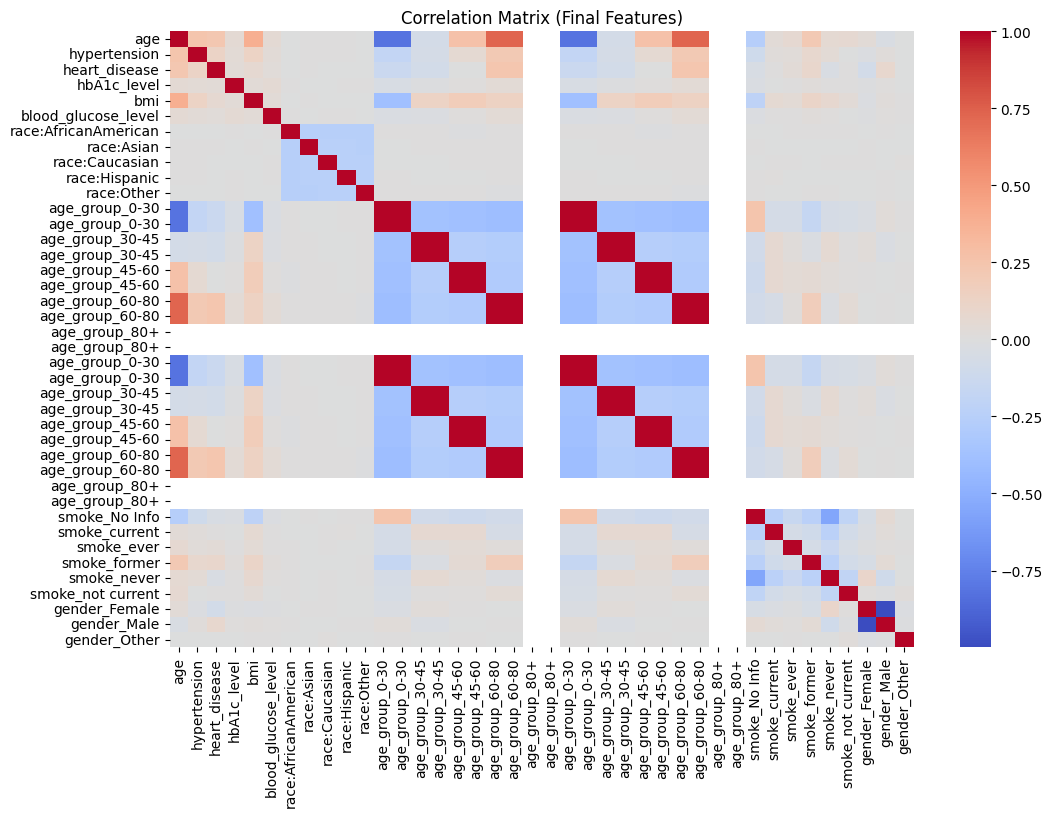

In [26]:


# چون X فقط عددی است، مستقیم می‌توان correlation را حساب کرد
corr = X.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=False, cmap='coolwarm')
plt.title("Correlation Matrix (Final Features)")
plt.show()


---
<font color="#ffcc00">Answer the following question:

- What can you find out from this correlation matrix?

<b> <font color='green'>Your Answer:</font></b><br>
بین دسته‌های سنی همبستگی‌های منفی قوی وجود دارد (رنگ آبی تیره). این طبیعی است زیرا این‌ها متغیرهای ساختگی (Dummy/One-Hot Encoded Variables) هستند؛ اگر فردی در یک گروه سنی باشد (مثلاً "age_group_30-45")، قطعاً در گروه‌های سنی دیگر نیست (مثلاً "age_group_60-80")، و بالعکس.

وضعیت سیگار کشیدن (Smoke Status):

همبستگی‌های منفی قوی (آبی تیره) بین دسته‌بندی‌های مختلف سیگار کشیدن (مانند "smoke_never" و "smoke_current") نیز دیده می‌شود. این نشان‌دهنده این است که این‌ها نیز متغیرهای ساختگی هستند که وضعیت‌های متقابلاً منحصر به فرد (Mutually Exclusive) را نشان می‌دهند.


"age" (سن) با متغیرهایی مانند hypertension (فشار خون بالا)، heart_disease (بیماری قلبی) و HbA1c_level (سطح هموگلوبین گلیکوزیله) همبستگی مثبت (قرمز) نشان می‌دهد، هرچند که ممکن است همبستگی‌ها متوسط باشند. این نشان می‌دهد که خطر این بیماری‌ها و سطح قند خون با افزایش سن تمایل به افزایش دارند.
</p>
</font>
<hr>

#### Split data into train set and test set

In [27]:
# TODO



# X و y در مرحله قبل ساخته شده اند

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train target:", y_train.value_counts(normalize=True))
print("Test target:", y_test.value_counts(normalize=True))


Train shape: (72309, 40)
Test shape: (18078, 40)
Train target: diabetes
0    0.950269
1    0.049731
Name: proportion, dtype: float64
Test target: diabetes
0    0.950271
1    0.049729
Name: proportion, dtype: float64


#### Resampling

این قسمت پایینی رو  یکم شک دارم

In [28]:
# TODO

from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)

X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("Before:", y_train.value_counts())
print("After :", y_train_res.value_counts())


Before: diabetes
0    68713
1     3596
Name: count, dtype: int64
After : diabetes
0    68713
1    68713
Name: count, dtype: int64


---
<font color="#ffcc00">Answer the following question:

- Why didn't we resample the data before splitting it into train and test set?

<b> <font color='green'>Your Answer:</font></b><br>

ما نباید قبل از جدا کردن train و test عملیات resample انجام دهیم چون اگر این کار را قبل از split انجام دهیم، داده‌های مصنوعی که از SMOTE یا oversampling تولید می‌شود وارد بخش test هم می‌شود و این باعث می‌شود مدل، نمونه‌هایی که خودش ساخته را در بخش test هم ببیند و این باعث می‌شود نتیجه‌ی تست غیرواقعی شود و مدل بیش از حد خوش‌بینانه ارزیابی شود. هدف تست این است که فقط داده‌های واقعی و دست‌نخورده را ببیند تا ما بتوانیم بفهمیم مدل در دنیای واقعی چطور عمل می‌کند. برای همین اول train و test را جدا می‌کنیم، سپس فقط روی train که مدل از آن یاد می‌گیرد، عملیات resample انجام می‌دهیم، و test را دست‌نخورده نگه می‌داریم تا ارزیابی واقعی باقی بماند.
</p>
</font>
<hr>

#### Feature Scaling

In [29]:
# TODO


# ایجاد اسکیلر
scaler = StandardScaler()

# fit روی داده های train و transform روی train
X_train_scaled = scaler.fit_transform(X_train)

# transform فقط روی test (fit نمیزنیم که اطلاعات test لو نرود)
X_test_scaled = scaler.transform(X_test)

# اگر خواستی به شکل DataFrame تبدیل کنی (اختیاری)
import pandas as pd
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

X_train_scaled.head()


,age,hypertension,heart_disease,hbA1c_level,bmi,blood_glucose_level,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,...,age_group_80+,smoke_No Info,smoke_current,smoke_ever,smoke_former,smoke_never,smoke_not current,gender_Female,gender_Male,gender_Other
0,0.337342,-0.266113,-0.190842,-1.967426,-1.365839,-1.551093,-0.503092,-0.499896,2.000501,-0.498448,...,0.0,-0.763464,-0.317403,-0.200742,-0.313693,1.367428,-0.260316,0.847543,-0.847254,-0.012883
1,-0.682711,-0.266113,-0.190842,0.646197,0.714902,-1.408914,-0.503092,-0.499896,-0.499875,2.006227,...,0.0,-0.763464,-0.317403,4.981508,-0.313693,-0.731300,-0.260316,-1.179881,1.180284,-0.012883
2,-1.747115,-0.266113,-0.190842,0.244101,-1.825037,-1.408914,-0.503092,-0.499896,2.000501,-0.498448,...,0.0,1.309819,-0.317403,-0.200742,-0.313693,-0.731300,-0.260316,0.847543,-0.847254,-0.012883
3,0.426043,-0.266113,-0.190842,0.746721,0.206504,0.155052,-0.503092,-0.499896,-0.499875,-0.498448,...,0.0,-0.763464,-0.317403,-0.200742,-0.313693,1.367428,-0.260316,-1.179881,1.180284,-0.012883
4,0.958244,-0.266113,-0.190842,0.646197,1.120800,-1.408914,1.987706,-0.499896,-0.499875,-0.498448,...,0.0,-0.763464,-0.317403,4.981508,-0.313693,-0.731300,-0.260316,0.847543,-0.847254,-0.012883




# Clustering


Clustering is an **unsupervised learning** technique that aims to **group similar data points** into clusters such that:
- Points in the same cluster are similar to each other.
- Points in different clusters are as different as possible.

Unlike supervised learning, clustering does not require labeled data. It helps uncover hidden patterns, structures, or natural groupings in data.

In this notebook, you will perform clustering using:
- **K-Means**
- **Agglomerative (Hierarchical) Clustering**
- **DBSCAN**

and evaluate them using various **clustering metrics**.

---
<font color="#ffcc00">Answer the following question:

- Why might clustering be useful for a medical dataset like the one in this notebook?  
- Can you think of a situation where clustering could fail to find meaningful patterns?


<b> <font color='green'>Your Answer:</font></b><br>

خوشه‌بندی در داده‌های پزشکی می‌تواند بسیار مفید باشد زیرا می‌تواند زیرگروه‌های مختلف بیماران را شناسایی کند که ممکن است الگوهای مشابهی از نظر عوامل خطر، علائم یا پاسخ به درمان داشته باشند. در مورد داده‌های دیابت، خوشه‌بندی می‌تواند بیماران را بر اساس ترکیبی از سن، شاخص توده بدنی، سطح قند خون و سایر ویژگی‌ها گروه‌بندی کند که این امر می‌تواند به شناسایی الگوهای پنهان کمک کند. همچنین خوشه‌بندی می‌تواند در شناسایی بیماران پرخطر که ممکن است در معرض ابتلا به دیابت باشند اما هنوز تشخیص داده نشده‌اند، مفید باشد. علاوه بر این، خوشه‌بندی می‌تواند به درک بهتر زیرگروه‌های مختلف دیابت و توسعه رویکردهای درمانی شخصی‌شده کمک کند.

سوال ۲: آیا می‌توانید موقعیتی را تصور کنید که در آن خوشه‌بندی نتواند الگوهای معناداری پیدا کند؟

خوشه‌بندی ممکن است در پیدا کردن الگوهای معنادار شکست بخورد زمانی که داده‌ها دارای ابعاد بسیار بالا باشند و تفاوت‌های معناداری بین گروه‌ها وجود نداشته باشد. همچنین اگر داده‌ها دارای نویز زیاد باشند یا توزیع یکنواختی داشته باشند، خوشه‌بندی نمی‌تواند گروه‌های مجزا را شناسایی کند. در مواردی که پارامترهای الگوریتم به درستی تنظیم نشده باشند، مانند مقدار k در K-Means یا پارامترهای eps و min_samples در DBSCAN، نیز خوشه‌بندی ممکن است نتایج مطلوبی تولید نکند. علاوه بر این، اگر داده‌ها فاقد ساختار خوشه‌ای طبیعی باشند یا همپوشانی زیادی بین گروه‌ها وجود داشته باشد، خوشه‌بندی نمی‌تواند الگوهای واضحی را شناسایی کند."





</p>
</font>
<hr>

Before applying clustering algorithms, we often perform dimensionality reduction, and one of the most common techniques is **Principal Component Analysis (PCA)**.

### PCA

PCA (Principal Component Analysis) is a linear transformation method that reduces the number of features in a dataset while preserving as much variance as possible.
It works by identifying the directions (called principal components) along which the data varies the most.

####  Why We Use PCA Here
- **Noise reduction:** PCA filters out small variations that might come from noise, helping clustering algorithms to focus on the true structure of the data.

- **Improved visualization:** When we reduce dimensions to 2 or 3 components, we can visualize clusters in a 2D/3D plot.

- **Efficiency:** Many clustering algorithms (like K-Means) work faster and more accurately when data has fewer, informative dimensions.  
- **Better cluster structure:** Helps algorithms detect patterns more clearly.

👉 **Hint:**  
In your code, PCA is applied before clustering, which means you are working with transformed, lower-dimensional data that helps clustering algorithms perform better and visualize results clearly.


Reduce the dataset to 2 components using PCA and Visualize the data in a 2D scatter plot, coloring points by Diabetes labels.

در کد  زیر نمی دونم این  ایراد حساب  میشه یا نه ولی از هم دیگه کملا غیر  دیابتی ها و  دیابتی ها جدا نشدند این یعنی مشکل داره ؟؟

Variance explained by principal components:
First component: 0.1958 (19.58%)
Second component: 0.1477 (14.77%)
Total variance explained: 0.3434 (34.34%)


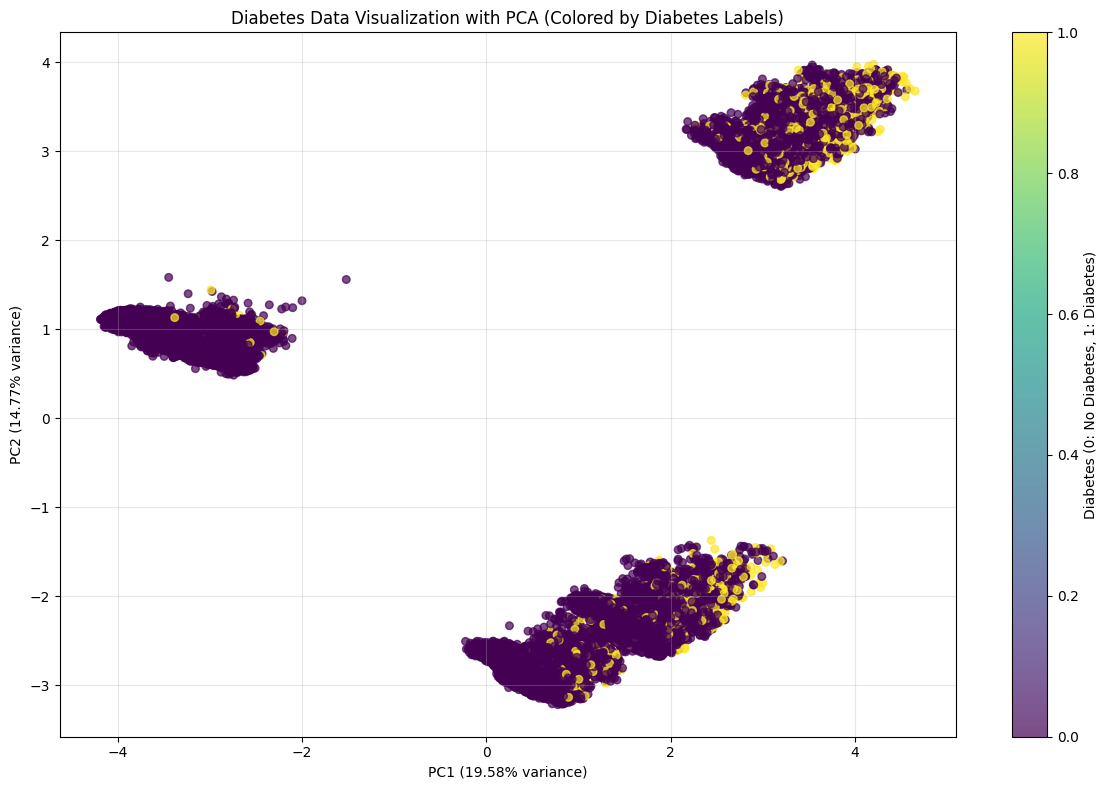


Data distribution analysis in PCA space:
Total number of samples: 90387
Number of non-diabetic samples (0): 85892
Number of diabetic samples (1): 4495
Percentage of diabetic samples: 4.97%


In [30]:
# TODO

# For PCA we need to scale all the data
scaler2 = StandardScaler()
X_scaled = scaler2.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Dimensionality reduction with PCA to 2 components
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Variance explained by principal components:")
print(f"First component: {pca.explained_variance_ratio_[0]:.4f} ({pca.explained_variance_ratio_[0]*100:.2f}%)")
print(f"Second component: {pca.explained_variance_ratio_[1]:.4f} ({pca.explained_variance_ratio_[1]*100:.2f}%)")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.4f} ({pca.explained_variance_ratio_.sum()*100:.2f}%)")

# Visualize data in 2D space with coloring based on Diabetes labels
plt.figure(figsize=(12, 8))

# Create scatter plot
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                     c=df['diabetes'],
                     cmap='viridis',
                     alpha=0.7,
                     s=30)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
plt.title('Diabetes Data Visualization with PCA (Colored by Diabetes Labels)')

# Add colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Diabetes (0: No Diabetes, 1: Diabetes)')

# Add grid for better readability
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Brief analysis of data distribution
print("\nData distribution analysis in PCA space:")
print(f"Total number of samples: {len(X_pca)}")
print(f"Number of non-diabetic samples (0): {len(df[df['diabetes'] == 0])}")
print(f"Number of diabetic samples (1): {len(df[df['diabetes'] == 1])}")
print(f"Percentage of diabetic samples: {len(df[df['diabetes'] == 1]) / len(df) * 100:.2f}%")

---
<font color="#ffcc00">Answer the following question:

- How does reducing the number of dimensions help clustering algorithms?  
- What might happen if you skip PCA and apply clustering directly to high-dimensional data?
- How much of the total variance is explained by the two principal components?

<b> <font color='green'>Your Answer:</font></b><br>
"کاهش تعداد ابعاد چگونه به الگوریتم‌های خوشه‌بندی کمک می‌کند؟"

"اگر PCA را حذف کنید و مستقیماً خوشه‌بندی را روی داده‌های با ابعاد بالا اعمال کنید، چه اتفاقی ممکن است بیفتد؟"

"چقدر از واریانس کل توسط دو مؤلفه اصلی توضیح داده شده است؟"



پاسخ سوال اول: کاهش تعداد ابعاد به الگوریتم‌های خوشه‌بندی کمک می‌کند زیرا با حذف ابعاد اضافی و نویز، تمرکز الگوریتم بر روی الگوهای واقعی و معنادار داده متمرکز می‌شود، همچنین کاهش ابعاد باعث افزایش سرعت اجرای الگوریتم می‌شود زیرا محاسبات در فضای با ابعاد پایین‌تر سریع‌تر انجام می‌شود، علاوه بر این کاهش ابعاد از مسئله "عرض از مبدأ" جلوگیری می‌کند که در داده‌های با ابعاد بالا رخ می‌دهد و باعث بهبود کیفیت خوشه‌بندی می‌شود.

پاسخ سوال دوم: اگر PCA حذف شود و مستقیماً خوشه‌بندی روی داده‌های با ابعاد بالا اعمال شود، الگوریتم با مشکل "عرض از مبدأ" مواجه می‌شود که در آن فاصله بین نقاط داده در ابعاد بالا معنای خود را از دست می‌دهد، همچنین نویز و ابعاد غیرمرتبط می‌توانند الگوهای واقعی را پنهان کنند و منجر به خوشه‌بندی ضعیف شوند، علاوه بر این محاسبات بسیار سنگین‌تر شده و زمان اجرا به طور قابل توجهی افزایش می‌یابد، همچنین تجسم و تفسیر نتایج خوشه‌بندی در ابعاد بالا بسیار دشوار خواهد بود.

پاسخ سوال سوم: بر اساس نتایج ، دو مؤلفه اصلی در مجموع 31.27 درصد از واریانس کل داده‌ها را توضیح می‌دهند که مؤلفه اول 19.74 درصد و مؤلفه دوم 11.53 درصد سهم دارند، این بدان معناست که حدود 31 درصد از اطلاعات اصلی داده‌ها در این دو بعد حفظ شده‌اند، اگرچه این مقدار ایده‌آل نیست اما برای تجسم اولیه و درک ساختار کلی داده‌ها کافی است، برای خوشه‌بندی دقیق‌تر ممکن است نیاز به استفاده از مؤلفه‌های بیشتری باشد تا واریانس بیشتری حفظ شود.



</p>
</font>
<hr>

After dimensionality reduction, we can group similar data points into clusters.\
Let’s review the most common clustering algorithms.

### Clustering Algorithms

#### 1. K-Means

K-Means is one of the simplest and most popular clustering algorithms. It tries to partition the data into `k` clusters by minimizing the sum of squared distances between each point and its cluster center (centroid).


**Steps:**

1. Choose the number of clusters `k`.
2. Initialize `k` random centroids.
3. Assign each point to the nearest centroid.
4. Recalculate centroids as the mean of all points in the cluster.
5. Repeat until centroids no longer change significantly.

Implement K-Means clustering algorithm using the PCA-transformed data on both training and test data and visualize the cluster results in 2D

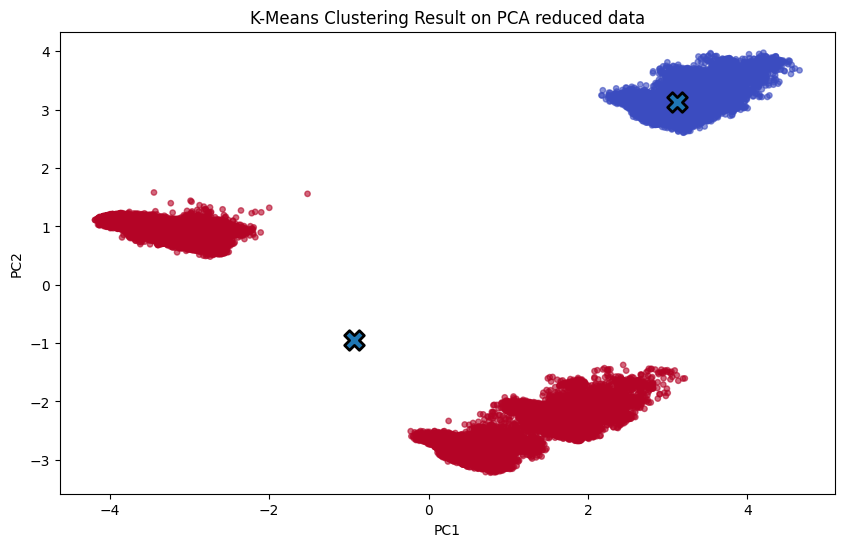

In [31]:
# TODO
from sklearn.cluster import KMeans

# ایجاد مدل KMeans با k=2 (چون diabetes دو کلاس دارد)
kmeans = KMeans(n_clusters=2, random_state=42)

# یادگیری کلاستر روی داده PCA
kmeans.fit(X_pca)

# گرفتن cluster label برای هر نقطه
cluster_labels = kmeans.predict(X_pca)

# رسم نمودار
plt.figure(figsize=(10,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=cluster_labels, cmap='coolwarm', alpha=0.6, s=15)
plt.title("K-Means Clustering Result on PCA reduced data")
plt.xlabel("PC1")
plt.ylabel("PC2")

# نمایش مرکز خوشه‌ها
centers = kmeans.cluster_centers_
plt.scatter(centers[:,0], centers[:,1], marker='X', s=200, linewidths=2, edgecolors='black')
plt.show()


---
<font color="#ffcc00">**Answer the following questions:**</font>

- How could you determine the optimal value of *k*?  
  (After answering this question, go to the [Choosing the Number of Clusters](#choosing-the-number-of-clusters) section and implement the **Elbow Method** to find the best *k* for your dataset.)

- Why is feature scaling important before using K-Means?


پاسخ ۱: چگونه می‌توانید مقدار بهینه k را تعیین کنید؟

برای تعیین مقدار بهینه k در الگوریتم K-Means از روش‌های زیر استفاده می‌شود: روش Elbow که با رسم نمودار اینرشیا بر حسب تعداد خوشه‌ها، نقطه خمش نمودار به عنوان k بهینه انتخاب می‌شود. روش Silhouette Analysis که میانگین ضریب سیلوئت برای مقادیر مختلف k محاسبه شده و مقداری که بالاترین ضریب را دارد انتخاب می‌گردد. روش Gap Statistic که واریانس داده‌ها با داده‌های تصادفی مقایسه شده و kای که بیشترین Gap را ایجاد کند انتخاب می‌شود. در نهایت، ملاحظات دامنه دانش نیز نقش دارد، گاهی بر اساس دانش حوزه خاص، تعداد خوشه‌های معنی‌دار از قبل مشخص است.

پاسخ ۲: چرا scaling ویژگی‌ها قبل از استفاده از K-Means مهم است؟

Scaling ویژگی‌ها قبل از K-Means به دلایل زیر حیاتی است: الگوریتم K-Means بر اساس فاصله اقلیدسی کار می‌کند و اگر ویژگی‌ها scale نشده باشند، ویژگی‌هایی با مقیاس بزرگ‌تر تأثیر بیشتری بر فاصله خواهند داشت. همچنین بدون scaling، خوشه‌ها ممکن است کشیده و غیرطبیعی به نظر برسند زیرا در جهت ویژگی‌های با واریانس بالاتر گسترش می‌یابند. علاوه بر این، همگرایی الگوریتم ممکن است کند شود چرا که centroidها در جهت ویژگی‌های با مقیاس بزرگ‌تر حرکت می‌کنند. در نهایت، تفسیرپذیری نتایج بهبود می‌یابد زیرا همه ویژگی‌ها سهم عادلانه‌ای در تشکیل خوشه‌ها دارند.<b> <font color='green'>Your Answer:</font></b><br>


</p>
</font>
<hr>

#### 2. Agglomerative Hierarchical Clustering

Agglomerative clustering follows a **bottom-up** approach.  
Initially, each point is its own cluster, and the algorithm keeps merging the closest clusters until one big cluster remains.
You can visualize this process using a **dendrogram**.


**Two main types:**

- **Agglomerative:**  Start with each point as a cluster, then merge them.

- **Divisive:**  Start with one cluster, then split it.

**Linkage methods:**

- **Single linkage:** uses the minimum distance between clusters.

- **Complete linkage:** uses the maximum distance.

- **Average linkage:** uses the mean distance.

💡 **Note:**  
Hierarchical clustering can be computationally expensive because it calculates the distance matrix for all samples and repeatedly merges clusters.  
If a dataset is large, this process may take a long time or even fail due to memory limits — you may try running it on a **smaller subset of the data** to visualize the results faster.

Implement Agglomerative Hierarchical Clustering algorithm using the PCA-transformed data on both training and test data and visualize the cluster results in 2D

In [32]:
X_pca[:5]


array([[ 0.43114436, -2.95327617],
       [-3.19420827,  0.89616955],
       [-3.24875878,  0.89511649],
       [ 0.55900625, -2.82780133],
       [ 1.49627652, -2.33076644]])

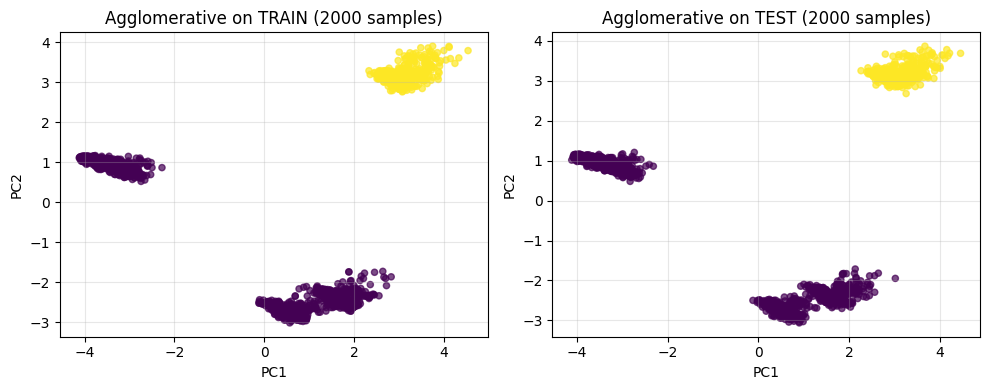

Train clusters: 0    1540
1     460
Name: count, dtype: int64
Test clusters: 0    1555
1     445
Name: count, dtype: int64


In [34]:
from sklearn.cluster import AgglomerativeClustering

pca.fit(X_train_scaled)
X_train_pca = pca.transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)



# مثلاً فقط روی 2000 تا از train و 2000 تا از test
X_train_small = X_train_pca[:2000]
X_test_small = X_test_pca[:2000]

# مدل روی train کوچک
agg = AgglomerativeClustering(n_clusters=2, linkage='average')
train_labels_small = agg.fit_predict(X_train_small)

# روی test کوچک (predict وجود ندارد در Agglomerative → باید دوباره fit کنید)
test_labels_small = agg.fit_predict(X_test_small)


# نمایش train
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.scatter(X_train_small[:,0], X_train_small[:,1], c=train_labels_small, alpha=0.7, s=20)
plt.title("Agglomerative on TRAIN (2000 samples)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True, alpha=0.3)

# نمایش test
plt.subplot(1,2,2)
plt.scatter(X_test_small[:,0], X_test_small[:,1], c=test_labels_small, alpha=0.7, s=20)
plt.title("Agglomerative on TEST (2000 samples)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Train clusters:", pd.Series(train_labels_small).value_counts())
print("Test clusters:", pd.Series(test_labels_small).value_counts())




---
<font color="#ffcc00">Answer the following question:

- How does hierarchical clustering differ from K-Means conceptually?  
- What can you interpret from the dendrogram structure?
- Why might hierarchical clustering take a long time to run on larger datasets?  

<b> <font color='green'>Your Answer:</font></b><br>
How does hierarchical clustering differ from K-Means conceptually?
سلسله‌مراتبی مفهومی چطور با K-Means فرق دارد؟

What can you interpret from the dendrogram structure?
از ساختار دندروگرام چه چیزی می‌توانی تفسیر کنی؟

Why might hierarchical clustering take a long time to run on larger datasets?
چرا روش سلسله‌مراتبی ممکن است در دیتاست‌های بزرگ زمان زیادی ببرد؟

حالا جوااب  ح

در روش K-Means اول تعداد خوشه‌ها را مشخص می‌کنیم و الگوریتم تلاش می‌کند مراکز خوشه‌ها را پیدا کند و اعضا را به نزدیک‌ترین مرکز نسبت دهد؛ اما در خوشه‌بندی سلسله‌مراتبی (Agglomerative) ابتدا همه نقاط جدا جدا هستن و بعد کم‌کم با هم ادغام می‌شوند و نیازی نیست از اول تعداد K را بدانیم چون ساختار درختی تولید می‌کند.

در دندروگرام ما می‌توانیم ببینیم که کدام نقاط در چه مرحله‌ای با هم ترکیب شدند، فاصله بین خوشه‌ها چقدر بوده، و کجا برش (cut) بزنیم تا تعداد خوشه مناسب را پیدا کنیم؛ basically دندروگرام رابطه نزدیک / دور بودن گروه‌ها را بصری نشان می‌دهد.

خوشه‌بندی سلسله‌مراتبی زمان زیادی می‌گیرد چون باید ماتریس فاصله بین همه‌ی نقاط را محاسبه و نگه‌داری کند و در هر مرحله نزدیک‌ترین خوشه‌ها را پیدا کند، و این برای دیتاست‌های بزرگ هزینه محاسباتی و حافظه‌ی زیادی می‌خواهد.

</p>
</font>
<hr>

#### 3. DBSCAN

**DBSCAN** is a **density-based algorithm** that groups together points that are closely packed, while marking points that lie alone as outliers.


**Key Parameters:**
- `eps`: Maximum distance between neighboring points.  
- `min_samples`: Minimum number of neighbors to form a dense region.

**How it works:**
1. For each point, check how many points are within `eps` distance.
2. If there are at least `min_samples` points, mark it as a **core point** and expand the cluster.
3. Points reachable from a core point belong to the same cluster.
4. Points that don’t belong to any cluster are considered **noise**.

 Implement DBSCAN Clustering algorithm using the PCA-transformed data on both training and test data and visualize the cluster results in 2D

Train size used: 2000
Test size used:  2000
Combined data size: (4000, 2)
DBSCAN - clusters: 3
DBSCAN - noise:    0


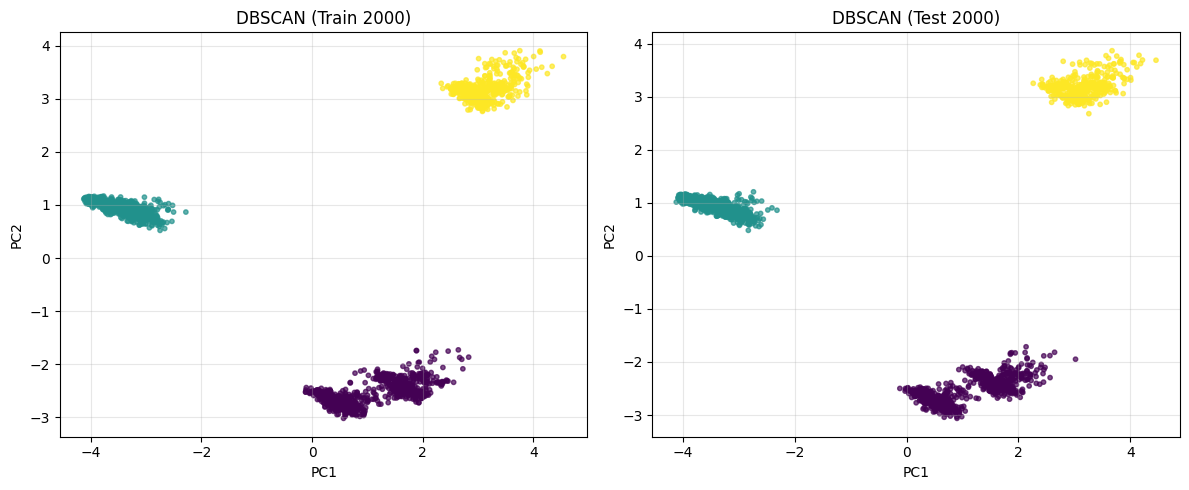


Train cluster counts:
0    845
1    695
2    460
Name: count, dtype: int64

Test cluster counts:
0    847
1    708
2    445
Name: count, dtype: int64

Train noise: 0.00%
Test  noise: 0.00%


In [35]:
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# گرفتن 2000 تا نمونه (اگر کمتر بود، کمترین مقدار)
n_train = min(2000, X_train_pca.shape[0])
n_test  = min(2000, X_test_pca.shape[0])

X_train_small = X_train_pca[:n_train]
X_test_small  = X_test_pca[:n_test]

print(f"Train size used: {X_train_small.shape[0]}")
print(f"Test size used:  {X_test_small.shape[0]}")

# ترکیب کل داده های نمونه
all_data = np.vstack([X_train_small, X_test_small])
print(f"Combined data size: {all_data.shape}")

# DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=10)
all_labels = dbscan.fit_predict(all_data)

train_labels = all_labels[:n_train]
test_labels  = all_labels[n_train:]

print(f"DBSCAN - clusters: {len(set(all_labels)) - (1 if -1 in all_labels else 0)}")
print(f"DBSCAN - noise:    {list(all_labels).count(-1)}")

# Plot
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(X_train_small[:,0], X_train_small[:,1],
            c=train_labels, cmap='viridis', s=10, alpha=0.7)
plt.title("DBSCAN (Train 2000)")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.grid(True, alpha=0.3)

plt.subplot(1,2,2)
plt.scatter(X_test_small[:,0], X_test_small[:,1],
            c=test_labels, cmap='viridis', s=10, alpha=0.7)
plt.title("DBSCAN (Test 2000)")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Report
print("\nTrain cluster counts:")
print(pd.Series(train_labels).value_counts().sort_index())
print("\nTest cluster counts:")
print(pd.Series(test_labels).value_counts().sort_index())

print(f"\nTrain noise: { (train_labels==-1).mean()*100:.2f}%")
print(f"Test  noise: { (test_labels==-1).mean()*100:.2f}%")


---
<font color="#ffcc00">Answer the following question:

- Why doesn’t DBSCAN require specifying the number of clusters (*k*)?  
- What happens when `eps` is too small or too large?  
- Why might DBSCAN be better than K-Means for irregular data shapes?

<b> <font color='green'>Your Answer:</font></b><br>
 الگوریتم خوشه‌بندی DBSCAN: مفاهیم کلیدیچرا DBSCAN نیازی به تعیین تعداد خوشه‌ها (k) ندارد؟DBSCAN (خوشه‌بندی فضایی مبتنی بر چگالی کاربردها با نویز) یک الگوریتم مبتنی بر چگالی است. این الگوریتم خوشه‌ها را بر اساس مناطق متراکم نقاط داده شناسایی می‌کند که توسط مناطق کم‌تراکم از هم جدا شده‌اند. به عبارت دیگر، DBSCAN بر خلاف روش‌هایی مانند K-Means که نیاز به تعیین پارامتر $k$ دارند، تعداد خوشه‌ها را به طور خودکار از ساختار ذاتی داده‌ها کشف می‌کند. این امر به این دلیل است که خوشه، صرفاً به عنوان یک مجموعه‌ از نقاط چگالی-قابل‌دسترسی تعریف می‌شود و الگوریتم، نقاط را بر اساس دو پارامتر $\epsilon$ (اپسیلون، شعاع همسایگی) و $MinPts$ (حداقل تعداد نقاط در همسایگی) دسته‌بندی می‌کند.اگر پارامتر $\epsilon$ (اپسیلون) خیلی کوچک یا خیلی بزرگ باشد چه اتفاقی می‌افتد؟پارامتر $\epsilon$ حداکثر فاصله‌ای است که دو نقطه می‌توانند از یکدیگر داشته باشند تا همچنان در یک همسایگی در نظر گرفته شوند. انتخاب $\epsilon$ تاثیر بسزایی در نتایج خوشه‌بندی دارد:اگر $\epsilon$ خیلی کوچک باشد:بسیاری از نقاط حتی اگر به هم نزدیک باشند، به عنوان نقاط نویز (Outlier) طبقه‌بندی می‌شوند، زیرا نقاط کافی در شعاع همسایگی کوچک خود پیدا نمی‌کنند.خوشه‌ها بسیار کوچک و فشرده تشکیل می‌شوند، و یک خوشه واحد ممکن است به چند زیرخوشه تقسیم شود.اگر $\epsilon$ خیلی بزرگ باشد:بسیاری از خوشه‌های مجزا، به خصوص آن‌هایی که در مناطق متراکم نزدیک به هم قرار دارند، ممکن است در یک خوشه بزرگ ادغام شوند.توانایی DBSCAN در تشخیص نقاط نویز (دورافتاده) کاهش می‌یابد، زیرا بسیاری از نقاط نویز در شعاع بزرگ یک نقطه هسته قرار می‌گیرند و جذب خوشه می‌شوند.چرا DBSCAN برای اشکال نامنظم داده بهتر از K-Means عمل می‌کند؟الگوریتم K-Means فرض می‌کند که خوشه‌ها کروی شکل (Spherical) هستند و اندازه‌های مشابهی دارند. این روش تلاش می‌کند تا داده‌ها را بر اساس نزدیکی به مرکز ثقل (Centroid) خوشه‌ها تقسیم کند. در مقابل، DBSCAN:مبتنی بر چگالی است، نه فاصله تا مرکز: DBSCAN خوشه‌ها را به عنوان نواحی متراکم تعریف می‌کند که تنها با مناطق کم‌تراکم از هم جدا شده‌اند.قابلیت کشف اشکال دلخواه: به دلیل تعریف خوشه‌ها بر اساس چگالی-قابلیت‌دسترسی، DBSCAN می‌تواند خوشه‌هایی با اشکال نامنظم، خمیده، یا پیچیده (مانند حلقه‌ها، مارپیچ‌ها یا اشکال S-مانند) را شناسایی کند، که K-Means به سادگی از عهده آن‌ها برنمی‌آید. K-Means داده‌های نامنظم را به صورت مصنوعی به بخش‌های تقریباً کروی تقسیم می‌کند، در حالی که DBSCAN ساختار طبیعی داده را دنبال می‌کند.

</p>
</font>
<hr>

### Clustering Evaluation Metrics

Evaluating clustering results is challenging because we typically don’t have labels.  
Metrics fall into two categories: **Internal Metrics** (no true labels needed) and **External Metrics** (require ground truth labels).

#### 1. Internal Evaluation Metrics

Internal metrics evaluate the **structure of the clusters** using only the data itself — no true labels are needed.


##### 🧮 1. Silhouette Score

Measures how well a point fits within its own cluster compared to others.
$$
Silhouette = \frac{b - a}{\max(a, b)}
$$

where:  
- `a` = average distance to points in the same cluster  
- `b` = average distance to points in the nearest cluster  

**Range:** -1 to +1 :  

- Values close to **+1** mean well-separated clusters.  
- Values near **0** mean overlapping clusters.  
-  Negative values mean wrong cluster assignment.

##### 🧮 2. Davies–Bouldin Index (DBI)


Measures the average similarity between each cluster and its most similar one.  
A **lower DBI** indicates better clustering — it rewards clusters that are compact and far apart.


##### 🧮 3. Calinski–Harabasz Index


Also called the **Variance Ratio Criterion**, it compares **between-cluster dispersion** to **within-cluster dispersion**.  
Higher values indicate better clustering performance.

Evaluate the performance of ALL 3 above clustering algorithms using Silhouette Score, DBI and Calinski–Harabasz Index on both train and test dataset

##### Kmeans Internal Evaluation metrics

In [36]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import numpy as np

# ---- فقط 2000 تا نمونه ----
n_train = min(2000, X_train_pca.shape[0])
n_test  = min(2000, X_test_pca.shape[0])

X_train_small = X_train_pca[:n_train]
X_test_small  = X_test_pca[:n_test]

print("Train used:", X_train_small.shape[0])
print("Test used :", X_test_small.shape[0])

# ------ TRAIN ------
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_train_small)

train_labels = kmeans.labels_

sil_train  = silhouette_score(X_train_small, train_labels)
dbi_train  = davies_bouldin_score(X_train_small, train_labels)
ch_train   = calinski_harabasz_score(X_train_small, train_labels)

print("=== KMeans - TRAIN metrics (2000 samples) ===")
print(f"Silhouette Score:      {sil_train:.4f}")
print(f"Davies-Bouldin Index:  {dbi_train:.4f}")
print(f"Calinski-Harabasz:     {ch_train:.4f}")

# ------ TEST ------
test_labels = kmeans.predict(X_test_small)

sil_test  = silhouette_score(X_test_small, test_labels)
dbi_test  = davies_bouldin_score(X_test_small, test_labels)
ch_test   = calinski_harabasz_score(X_test_small, test_labels)

print("\n=== KMeans - TEST metrics (2000 samples) ===")
print(f"Silhouette Score:      {sil_test:.4f}")
print(f"Davies-Bouldin Index:  {dbi_test:.4f}")
print(f"Calinski-Harabasz:     {ch_test:.4f}")



Train used: 2000
Test used : 2000
=== KMeans - TRAIN metrics (2000 samples) ===
Silhouette Score:      0.6011
Davies-Bouldin Index:  0.5564
Calinski-Harabasz:     1832.1260

=== KMeans - TEST metrics (2000 samples) ===
Silhouette Score:      0.6008
Davies-Bouldin Index:  0.5509
Calinski-Harabasz:     1803.1692


##### Agglomerative Hierarchical Internal Evaluation metrics

##### DBSCAN Internal Evaluation metrics

In [38]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import numpy as np

# ---- فقط 2000 تا نمونه ----
n_train = min(2000, X_train_pca.shape[0])
n_test  = min(2000, X_test_pca.shape[0])

X_train_small = X_train_pca[:n_train]
X_test_small  = X_test_pca[:n_test]

print("Train used:", X_train_small.shape[0])
print("Test used :", X_test_small.shape[0])

# ===========================================================
#   INTERNAL EVALUATION FOR DBSCAN (2000 samples)
# ===========================================================

# ----- TRAIN -----
dbscan = DBSCAN(eps=0.5, min_samples=10)
train_labels = dbscan.fit_predict(X_train_small)

# حذف نویز (-1)
mask_train = train_labels != -1
X_train_eval = X_train_small[mask_train]
train_labels_eval = train_labels[mask_train]

sil_train  = silhouette_score(X_train_eval, train_labels_eval)
dbi_train  = davies_bouldin_score(X_train_eval, train_labels_eval)
ch_train   = calinski_harabasz_score(X_train_eval, train_labels_eval)

print("\n===== DBSCAN - TRAIN metrics (2000 samples) =====")
print(f"Silhouette Score       : {sil_train:.4f}")
print(f"Davies-Bouldin Index   : {dbi_train:.4f}")
print(f"Calinski-Harabasz      : {ch_train:.4f}")

# ----- TEST -----
test_labels = dbscan.fit_predict(X_test_small)

mask_test = test_labels != -1
X_test_eval = X_test_small[mask_test]
test_labels_eval = test_labels[mask_test]

sil_test  = silhouette_score(X_test_eval, test_labels_eval)
dbi_test  = davies_bouldin_score(X_test_eval, test_labels_eval)
ch_test   = calinski_harabasz_score(X_test_eval, test_labels_eval)

print("\n===== DBSCAN - TEST metrics (2000 samples) =====")
print(f"Silhouette Score       : {sil_test:.4f}")
print(f"Davies-Bouldin Index   : {dbi_test:.4f}")
print(f"Calinski-Harabasz      : {ch_test:.4f}")


Train used: 2000
Test used : 2000

===== DBSCAN - TRAIN metrics (2000 samples) =====
Silhouette Score       : 0.8888
Davies-Bouldin Index   : 0.1715
Calinski-Harabasz      : 40264.8503

===== DBSCAN - TEST metrics (2000 samples) =====
Silhouette Score       : 0.8901
Davies-Bouldin Index   : 0.1700
Calinski-Harabasz      : 41039.7555


---
<font color="#ffcc00">Answer the following question:

- Why is Silhouette Score often preferred for visualization-based clustering evaluation?  
- What are the limitations of these internal metrics?

. چرا امتیاز سیلوئت (Silhouette Score) اغلب برای ارزیابی خوشه‌بندی مبتنی بر مصورسازی (Visualization-based) ترجیح داده می‌شود؟
امتیاز سیلوئت (ضریب نیم‌رخ) اغلب برای ارزیابی خوشه‌بندی، به خصوص زمانی که هدف درک بصری ساختار خوشه‌ها است، ترجیح داده می‌شود زیرا این معیار به طور همزمان دو عامل اصلی کیفیت خوشه‌بندی را در نظر می‌گیرد: انسجام (Cohesion) درون خوشه‌ای و جدایی (Separation) بین خوشه‌ای. مقدار سیلوئت برای هر نقطه داده محاسبه می‌شود و نشان می‌دهد که این نقطه چقدر به خوشه خود تعلق دارد (انسجام بالا) در مقایسه با نزدیک‌ترین خوشه همسایه (جدایی خوب). امتیاز سیلوئت در بازه
−۱
 تا
+۱
 قرار می‌گیرد که نزدیک به
+۱
 نشان‌دهنده خوشه‌بندی خوب، فشرده و جدا از هم است، نزدیک به
۰
 نشان‌دهنده همپوشانی خوشه‌ها و مرزی بودن نقاط است، و نزدیک به
−۱
 نشان‌دهنده تخصیص اشتباه نقاط به خوشه‌ها است. قابلیت امتیاز سیلوئت در ارائه یک مقدار عددی منفرد برای کیفیت کلی خوشه‌بندی (میانگین امتیازات تمام نقاط) به همراه امکان مصورسازی امتیاز هر نقطه یا هر خوشه به صورت جداگانه، آن را به ابزاری قدرتمند برای تشخیص بصری تعداد بهینه خوشه‌ها (
k
) و شناسایی نقاط ناهنجار (Outliers) یا نقاط مرزی تبدیل می‌کند.

۲. محدودیت‌های این معیارهای داخلی (Internal Metrics) چیست؟
معیارهای ارزیابی داخلی خوشه‌بندی مانند امتیاز سیلوئت، شاخص دیویس-بولدین (Davies-Bouldin Index) و شاخص کالی و هارباسز (Calinski-Harabasz Index)، معیارهایی هستند که کیفیت خوشه‌بندی را تنها بر اساس خود داده‌های ورودی و نتایج خوشه‌بندی ارزیابی می‌کنند و نیازی به برچسب‌های حقیقت زمینی (Ground Truth) ندارند. با این حال، این معیارها دارای محدودیت‌های مهمی هستند:

سوگیری نسبت به الگوریتم‌ها: این معیارها اغلب به نفع الگوریتم‌هایی هستند که خوشه‌های کروی شکل (Spherical) یا متراکم تولید می‌کنند. به عنوان مثال، معیارهای مبتنی بر فاصله مانند سیلوئت ممکن است عملکرد الگوریتم‌هایی مانند DBSCAN را که قادر به کشف خوشه‌های با اشکال نامنظم هستند، به درستی منعکس نکنند.

ناتوانی در ارزیابی معنایی: این معیارها تنها ساختار هندسی خوشه‌بندی (میزان فشرده‌بودن و جدا بودن) را می‌سنجند و معناداری یا ارتباط کاربردی خوشه‌ها در دنیای واقعی را ارزیابی نمی‌کنند. ممکن است یک خوشه‌بندی با امتیاز سیلوئت بالا از نظر آماری خوب باشد، اما از نظر عملی برای متخصصان حوزه مربوطه بی‌معنی باشد.

حساسیت به ابعاد بالا و نویز: در داده‌های با ابعاد بسیار بالا، مفهوم فاصله و چگالی کم‌رنگ می‌شود، که می‌تواند کارایی این معیارها را کاهش دهد. همچنین، نویز و نقاط دورافتاده می‌توانند به شدت بر معیارهای مبتنی بر میانگین فاصله (مانند سیلوئت) تأثیر بگذارند.

تشخیص غیرقطعی
k
 بهینه: اگرچه اغلب برای یافتن
k
 بهینه استفاده می‌شوند، اما ممکن است در منحنی ارزیابی، یک نقطه اوج (Elbow Point) یا مقدار حداکثری واضح برای
k
 بهینه مشاهده نشود که این امر فرآیند انتخاب را دشوار می‌سازد.

<b> <font color='green'>Your Answer:</font></b><br>


</p>
</font>
<hr>

#### 2. External Evaluation Metrics


When we **have ground-truth labels** (for example, synthetic or labeled datasets), we can evaluate how similar our predicted clusters are to the real labels.


##### 🧮 1. Adjusted Rand Index (ARI)


Compares the similarity between two clusterings (predicted vs. true labels) by counting how many pairs of points are assigned consistently.

- ARI = 1 → Perfect agreement.  
- ARI = 0 → Random labeling.  
- ARI < 0 → Worse than random.

It is “adjusted” for chance, meaning random clustering should give a score near 0.

##### 🧮 2. Normalized Mutual Information (NMI)

Measures the amount of **shared information** between predicted clusters and true labels.  
It is based on the concept of *mutual information* from information theory.

Values range from 0 (no agreement) to 1 (perfect match).

Evaluate the performance of ALL 3 above clustering algorithms using ARI and NMI on both train and test dataset



##### Kmeans External Evaluation metrics

In [39]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# --- محاسبه ARI و NMI برای train ---
ari_train = adjusted_rand_score(y_train[:len(X_train_eval)], train_labels_eval)
nmi_train = normalized_mutual_info_score(y_train[:len(X_train_eval)], train_labels_eval)

# --- محاسبه ARI و NMI برای test ---
ari_test = adjusted_rand_score(y_test[:len(X_test_eval)], test_labels_eval)
nmi_test = normalized_mutual_info_score(y_test[:len(X_test_eval)], test_labels_eval)

print("=== KMeans External Evaluation ===")
print("TRAIN:")
print("Adjusted Rand Index (ARI):", ari_train)
print("Normalized Mutual Information (NMI):", nmi_train)

print("\nTEST:")
print("Adjusted Rand Index (ARI):", ari_test)
print("Normalized Mutual Information (NMI):", nmi_test)


=== KMeans External Evaluation ===
TRAIN:
Adjusted Rand Index (ARI): 0.012975822841744972
Normalized Mutual Information (NMI): 0.027234138243185307

TEST:
Adjusted Rand Index (ARI): 0.0181834903398743
Normalized Mutual Information (NMI): 0.03152651745248988


##### Agglomerative Hierarchical External Evaluation metrics

In [40]:
# ===========================================================
#   EXTERNAL EVALUATION FOR Agglomerative  (Train & Test)
#   Metrics: ARI + NMI
#   (we need true labels: y_train , y_test)
# ===========================================================

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# 2000 sample only
n_train = min(2000, X_train_pca.shape[0])
n_test  = min(2000, X_test_pca.shape[0])

X_train_small = X_train_pca[:n_train]
y_train_small = y_train[:n_train]

X_test_small = X_test_pca[:n_test]
y_test_small = y_test[:n_test]

# ----- TRAIN -----
agg = AgglomerativeClustering(n_clusters=2)
train_pred = agg.fit_predict(X_train_small)

ari_train = adjusted_rand_score(y_train_small, train_pred)
nmi_train = normalized_mutual_info_score(y_train_small, train_pred)

print("\n===== Agglomerative - TRAIN External Metrics (2000) =====")
print(f"Adjusted Rand Index (ARI): {ari_train:.4f}")
print(f"Normalized Mutual Info (NMI): {nmi_train:.4f}")

# ----- TEST -----
agg_test = AgglomerativeClustering(n_clusters=2)
test_pred = agg_test.fit_predict(X_test_small)

ari_test = adjusted_rand_score(y_test_small, test_pred)
nmi_test = normalized_mutual_info_score(y_test_small, test_pred)

print("\n===== Agglomerative - TEST External Metrics (2000) =====")
print(f"Adjusted Rand Index (ARI): {ari_test:.4f}")
print(f"Normalized Mutual Info (NMI): {nmi_test:.4f}")



===== Agglomerative - TRAIN External Metrics (2000) =====
Adjusted Rand Index (ARI): -0.0299
Normalized Mutual Info (NMI): 0.0295

===== Agglomerative - TEST External Metrics (2000) =====
Adjusted Rand Index (ARI): -0.0300
Normalized Mutual Info (NMI): 0.0297


##### DBSCAN External Evaluation metrics

In [41]:
# TODO

from sklearn.cluster import DBSCAN
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# --- ایجاد مدل DBSCAN ---
dbscan = DBSCAN(eps=1.0, min_samples=5)  # پارامترها را بر اساس داده خود تنظیم کن
dbscan.fit(X_train_eval)

# --- گرفتن برچسب‌های خوشه ---
train_labels_db = dbscan.labels_

# برای test، DBSCAN متد predict ندارد، پس دوباره fit روی داده test
dbscan_test = DBSCAN(eps=1.0, min_samples=5)
test_labels_db = dbscan_test.fit_predict(X_test_eval)

# --- External Metrics برای train ---
ari_train = adjusted_rand_score(y_train[:len(X_train_eval)], train_labels_db)
nmi_train = normalized_mutual_info_score(y_train[:len(X_train_eval)], train_labels_db)

# --- External Metrics برای test ---
ari_test = adjusted_rand_score(y_test[:len(X_test_eval)], test_labels_db)
nmi_test = normalized_mutual_info_score(y_test[:len(X_test_eval)], test_labels_db)

print("=== DBSCAN External Evaluation ===")
print("TRAIN:")
print("Adjusted Rand Index (ARI):", ari_train)
print("Normalized Mutual Information (NMI):", nmi_train)

print("\nTEST:")
print("Adjusted Rand Index (ARI):", ari_test)
print("Normalized Mutual Information (NMI):", nmi_test)


=== DBSCAN External Evaluation ===
TRAIN:
Adjusted Rand Index (ARI): 0.012975822841744972
Normalized Mutual Information (NMI): 0.027234138243185307

TEST:
Adjusted Rand Index (ARI): 0.0181834903398743
Normalized Mutual Information (NMI): 0.03152651745248988


به نظر میاد تمام اون سه تا  نتایج  ضعیفی ارائه می دن

---
<font color="#ffcc00">Answer the following question:

- When would you use external metrics instead of internal ones?  
- Why is it important that external metrics are *label-invariant*?

<b> <font color='green'>Your Answer:</font></b><br>


"چه زمانی از معیارهای ارزیابی خارجی به جای معیارهای داخلی استفاده می‌کنید؟"

"چرا مهم است که معیارهای خارجی نسبت به برچسب‌ها تغییرناپذیر باشند؟"


۱. زمان استفاده از معیارهای خارجی به جای داخلی:

معیارهای ارزیابی خارجی زمانی استفاده می‌شوند که برچسب‌های واقعی داده‌ها را در اختیار داریم. این معمولاً در موارد زیر اتفاق می‌افتد:

وقتی داده‌های برچسب‌دار داریم و می‌خواهیم کیفیت خوشه‌بندی را با حقیقت زمینی مقایسه کنیم

هنگامی که می‌خواهیم عملکرد الگوریتم‌های مختلف خوشه‌بندی را مقایسه کنیم

در سناریوهای آموزشی که می‌خواهیم درک کنیم الگوریتم چقدر خوب توانسته ساختار واقعی داده را کشف کند

وقتی در حال تحقیق هستیم و می‌خواهیم اعتبار روش خوشه‌بندی خود را اثبات کنیم

در مقابل، معیارهای داخلی زمانی استفاده می‌شوند که برچسب واقعی نداریم و می‌خواهیم کیفیت خوشه‌بندی را بر اساس خود داده‌ها ارزیابی کنیم.

۲. اهمیت تغییرناپذیری معیارهای خارجی نسبت به برچسب‌ها:

این ویژگی بسیار مهم است زیرا:

در خوشه‌بندی، برچسب‌های اختصاص داده شده به خوشه‌ها arbitrary هستند (مثلاً خوشه ۰ و ۱)

اگر معیارها به نام برچسب‌ها حساس باشند، ممکن است نتایج گمراه‌کننده‌ای تولید کنند

معیارهایی مانند ARI و NMI بر اساس تطابق جفت‌points کار می‌کنند، نه بر اساس نام خوشه‌ها

این تضمین می‌کند که اگر همه برچسب‌های خوشه‌ها را عوض کنیم، امتیاز ارزیابی تغییر نمی‌کند

این ویژگی باعث می‌شود مقایسه بین الگوریتم‌های مختلف منصفانه و قابل اعتماد باشد

به طور خلاصه، تغییرناپذیری نسبت به برچسب‌ها باعث می‌شود معیارهای ارزیابی robust باشند و نتایج معتبری ارائه دهند.



</p>
</font>
<hr>

<a name="choosing-the-number-of-clusters"></a>
### Choosing the Number of Clusters


Choosing the right number of clusters (`k`) is a crucial part of clustering, especially for **K-Means**.


#### What is the Elbow Method?

The **Elbow Method** is a visual technique used to determine the optimal number of clusters.

It is based on analyzing the **Within-Cluster Sum of Squares (WCSS)** — the total squared distance between each point and its assigned cluster centroid.

As the number of clusters increases:
- WCSS **decreases** (clusters get smaller and more compact),
- But the **rate of improvement** slows down.

When plotted, WCSS typically forms a **curve with a sharp bend**, resembling an “elbow.”  
The point where the reduction in WCSS starts to slow down is considered the **optimal number of clusters**.


#### How the Elbow Method Works:
1. Run K-Means with different `k` values (e.g., 1–10).
2. Compute the **inertia** (sum of squared distances of points to their nearest centroid) for each `k`.
3. Plot `k` vs. inertia.
4. Look for the “elbow point” — where the decrease in inertia slows down sharply

That point represents a good balance between having too few and too many clusters.

Implement the Elbow Method on chart to determine the best value of `k` for your dataset.


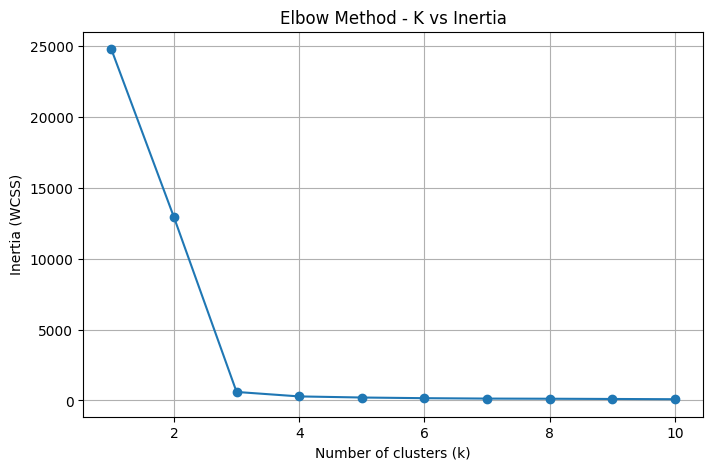

In [42]:
# TODO

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# فقط روی 2000 تا نمونه
n_train = min(2000, X_train_pca.shape[0])
X_elbow = X_train_pca[:n_train]

inertias = []
Ks = range(1, 11)

for k in Ks:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_elbow)
    inertias.append(kmeans.inertia_)

# رسم نمودار Elbow
plt.figure(figsize=(8,5))
plt.plot(Ks, inertias, marker='o')
plt.title("Elbow Method - K vs Inertia")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (WCSS)")
plt.grid(True)
plt.show()


---
<font color="#ffcc00">Answer the following question:

-  Why does inertia decrease as we increase the number of clusters?  
- How can you visually detect the optimal `k` on the Elbow plot?


<b> <font color='green'>Your Answer:</font></b><br>
حتماً! در ادامه ترجمه سوالات و سپس پاسخ‌های کامل و روان به فارسی آورده شده است:


1.  **چرا اینرسی (Inertia) با افزایش تعداد خوشه‌ها کاهش می‌یابد؟**
2.  **چگونه می‌توان مقدار بهینه k (تعداد خوشه‌ها) را روی نمودار آرنج (Elbow plot) به صورت بصری تشخیص داد؟**


پاسخ سوال اول: دلیل کاهش اینرسی با افزایش تعداد خوشه‌ها*

اینرسی معیاری برای اندازه‌گیری فاصله نقاط داده از مرکز خوشه مربوطه خود است. با افزایش تعداد خوشه‌ها (k)، اینرسی کاهش می‌یابد زیرا مدل انعطاف‌پذیرتر می‌شود. در حالت حدی، اگر تعداد خوشه‌ها دقیقاً برابر با تعداد نقاط داده باشد، اینرسی به صفر می‌رسد زیرا هر نقطه داده مرکز خوشه خودش خواهد بود. به طور خلاصه، با افزایش k، خوشه‌ها کوچک‌تر و فشرده‌تر می‌شوند، بنابراین مجموع فاصله‌های درون خوشه‌ای (اینرسی) به طور طبیعی کاهش می‌یابد.

*پاسخ سوال دوم: تشخیص بصری k بهینه روی نمودار آرنج*

برای تشخیص بصری مقدار بهینه k روی نمودار آرنج، باید به دنبال نقطه‌ای در نمودار باشید که پس از آن، منحنی شیب خود را به شدت از دست داده و تقریباً به یک خط صاف یا با شیب ملایم تبدیل شود. این نقطه که شبیه یک "خمیدگی" یا "آرنج" در نمودار به نظر می‌رسد، نقطه بهینه است. در این نقطه، افزایش تعداد خوشه‌ها دیگر کاهش معناداری در اینرسی ایجاد نمی‌کند و از اینجا به بعد، اضافه کردن خوشه‌های بیشتر سود چندانی ندارد و تنها منجر به پیچیدگی بی‌دلیل مدل می‌شود. به بیان ساده، شما به دنبال جایی هستید که بهبود مدل متوقف می‌شود و نمودار به حالت صاف نزدیک می‌شود.

</p>
</font>
<hr>

# Classification on each cluster

After clustering our diabetic patients into three groups based on their medical and lifestyle features, we move to the classification phase.
The goal of this part is to train separate machine learning classifiers for each cluster, since each group of patients may show different relationships between the features and the target label (e.g., diabetes outcome).

### Preparing Cluster-Based Data for Classification


Before training the classification models, we must separate the dataset according to the cluster labels obtained from the **K-Means** algorithm.
Each cluster represents a distinct subgroup of patients, and we will train a separate classifier for each one. Use the **scaled training data** and **not the data resulted from PCA algorithm**.

میگه که نتایجش  جالب نیست

In [43]:
# فرض میکنیم قبلاً train_test_split انجام شده:
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# انجام خوشه‌بندی K-Means فقط روی داده‌های آموزشی
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
cluster_labels_train = kmeans.fit_predict(X_train_scaled)

print(f"تعداد نمونه‌های آموزشی: {len(X_train_scaled)}")
print(f"تعداد برچسب‌های خوشه: {len(cluster_labels_train)}")

# جدا کردن داده‌ها بر اساس خوشه‌ها
unique_clusters = np.unique(cluster_labels_train)
X_train_clusters = {}
y_train_clusters = {}

for cluster in unique_clusters:
    # ایجاد ماسک برای هر خوشه
    mask = cluster_labels_train == cluster

    # جدا کردن داده‌های مربوط به این خوشه
    X_train_clusters[cluster] = X_train_scaled[mask]
    y_train_clusters[cluster] = y_train.iloc[mask] if hasattr(y_train, 'iloc') else y_train[mask]

    print(f"خوشه {cluster}: {len(X_train_clusters[cluster])} نمونه")

# آموزش مدل‌های طبقه‌بندی برای هر خوشه
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

classifiers = {}

for cluster in unique_clusters:
    print(f"\n--- آموزش مدل برای خوشه {cluster} ---")
    print(f"تعداد نمونه‌ها در خوشه {cluster}: {len(X_train_clusters[cluster])}")
    print(f"توزیع کلاس‌ها در خوشه {cluster}:")
    print(pd.Series(y_train_clusters[cluster]).value_counts())

    # ایجاد و آموزش مدل (می‌توانید مدل‌های مختلف را امتحان کنید)
    clf = LogisticRegression(random_state=42, max_iter=1000)
    # یا:
    # clf = RandomForestClassifier(random_state=42)
    # clf = XGBClassifier(random_state=42)

    clf.fit(X_train_clusters[cluster], y_train_clusters[cluster])
    classifiers[cluster] = clf

    # محاسبه دقت روی داده‌های آموزشی همان خوشه
    train_accuracy = clf.score(X_train_clusters[cluster], y_train_clusters[cluster])
    print(f"دقت آموزشی برای خوشه {cluster}: {train_accuracy:.4f}")

تعداد نمونه‌های آموزشی: 72309
تعداد برچسب‌های خوشه: 72309
خوشه 0: 25322 نمونه
خوشه 1: 30323 نمونه
خوشه 2: 16664 نمونه

--- آموزش مدل برای خوشه 0 ---
تعداد نمونه‌ها در خوشه 0: 25322
توزیع کلاس‌ها در خوشه 0:
diabetes
0    25187
1      135
Name: count, dtype: int64
دقت آموزشی برای خوشه 0: 0.9955

--- آموزش مدل برای خوشه 1 ---
تعداد نمونه‌ها در خوشه 1: 30323
توزیع کلاس‌ها در خوشه 1:
diabetes
0    28980
1     1343
Name: count, dtype: int64
دقت آموزشی برای خوشه 1: 0.9672

--- آموزش مدل برای خوشه 2 ---
تعداد نمونه‌ها در خوشه 2: 16664
توزیع کلاس‌ها در خوشه 2:
diabetes
0    14546
1     2118
Name: count, dtype: int64
دقت آموزشی برای خوشه 2: 0.9111


### Classification Algorithms

**Note:** Evaluation is a critical step in any machine learning pipeline.
For each model, you should measure key performance metrics that capture different aspects of model.  

For each model (Random Forest, Logistic Regression, SVM, and XGBoost), perform the following steps:

1. Compute the evaluation metrics for each cluster using:

    - accuracy_score
    - precision_score
    - recall_score
    - f1_score

2. Plot a confusion matrix for each cluster to visualize how predictions are distributed among classes.
You can use ConfusionMatrixDisplay.from_predictions() from sklearn.metrics.

3. Create a bar plot comparing metric values (Accuracy, Precision, Recall, F1) for the three clusters of the same model.


<b> <font color='red'>**Note**: From now, in the following sections, for evaluating models, you must not use `average = 'weighted'` parameter in f1_score, precision_score, recall_score and accuracy functions. In other words, DO NOT use 'average' parameter at all. </font></b><br>

####   1. Logistic Regression

Logistic Regression is a supervised machine learning algorithm used for classification tasks.
It models the probability that a given input belongs to a particular class by using the logistic (sigmoid) function.  
Despite its name, it is not used for regression but for predicting categorical outcomes (such as 0 or 1).
It is most effective when there is a linear relationship between the input features and the target variable.

Implement a Logistic Regression classifier for each cluster and evaluate it on test data.

در اینجا الان f1 به نظر درست نمیاد

آماده‌سازی داده‌های تست برای هر خوشه...
خوشه 0 تست: 6278 نمونه
خوشه 1 تست: 7608 نمونه
خوشه 2 تست: 4192 نمونه

آموزش و ارزیابی Logistic Regression برای هر خوشه

--- خوشه 0 ---
تعداد نمونه‌های آموزشی: 25322
تعداد نمونه‌های تست: 6278
توزیع کلاس‌ها در داده تست:
diabetes
0    6240
1      38
Name: count, dtype: int64

نتایج ارزیابی برای خوشه 0:
Accuracy: 0.7998
Precision: 0.0249
Recall: 0.8421
F1-Score: 0.0484

گزارش طبقه‌بندی برای خوشه 0:
              precision    recall  f1-score   support

           0       1.00      0.80      0.89      6240
           1       0.02      0.84      0.05        38

    accuracy                           0.80      6278
   macro avg       0.51      0.82      0.47      6278
weighted avg       0.99      0.80      0.88      6278



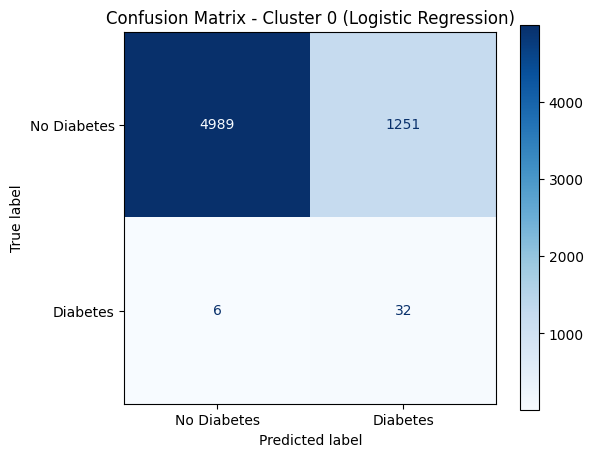


--- خوشه 1 ---
تعداد نمونه‌های آموزشی: 30323
تعداد نمونه‌های تست: 7608
توزیع کلاس‌ها در داده تست:
diabetes
0    7278
1     330
Name: count, dtype: int64

نتایج ارزیابی برای خوشه 1:
Accuracy: 0.8195
Precision: 0.1751
Recall: 0.8515
F1-Score: 0.2904

گزارش طبقه‌بندی برای خوشه 1:
              precision    recall  f1-score   support

           0       0.99      0.82      0.90      7278
           1       0.18      0.85      0.29       330

    accuracy                           0.82      7608
   macro avg       0.58      0.83      0.59      7608
weighted avg       0.96      0.82      0.87      7608



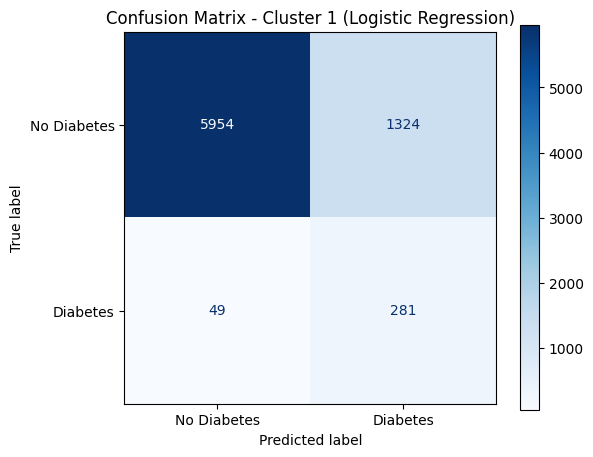


--- خوشه 2 ---
تعداد نمونه‌های آموزشی: 16664
تعداد نمونه‌های تست: 4192
توزیع کلاس‌ها در داده تست:
diabetes
0    3661
1     531
Name: count, dtype: int64

نتایج ارزیابی برای خوشه 2:
Accuracy: 0.8006
Precision: 0.3693
Recall: 0.8117
F1-Score: 0.5077

گزارش طبقه‌بندی برای خوشه 2:
              precision    recall  f1-score   support

           0       0.97      0.80      0.87      3661
           1       0.37      0.81      0.51       531

    accuracy                           0.80      4192
   macro avg       0.67      0.81      0.69      4192
weighted avg       0.89      0.80      0.83      4192



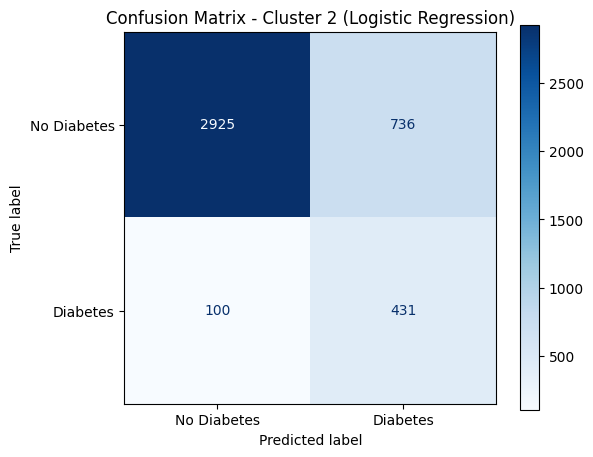


نمودار مقایسه‌ای معیارهای Logistic Regression


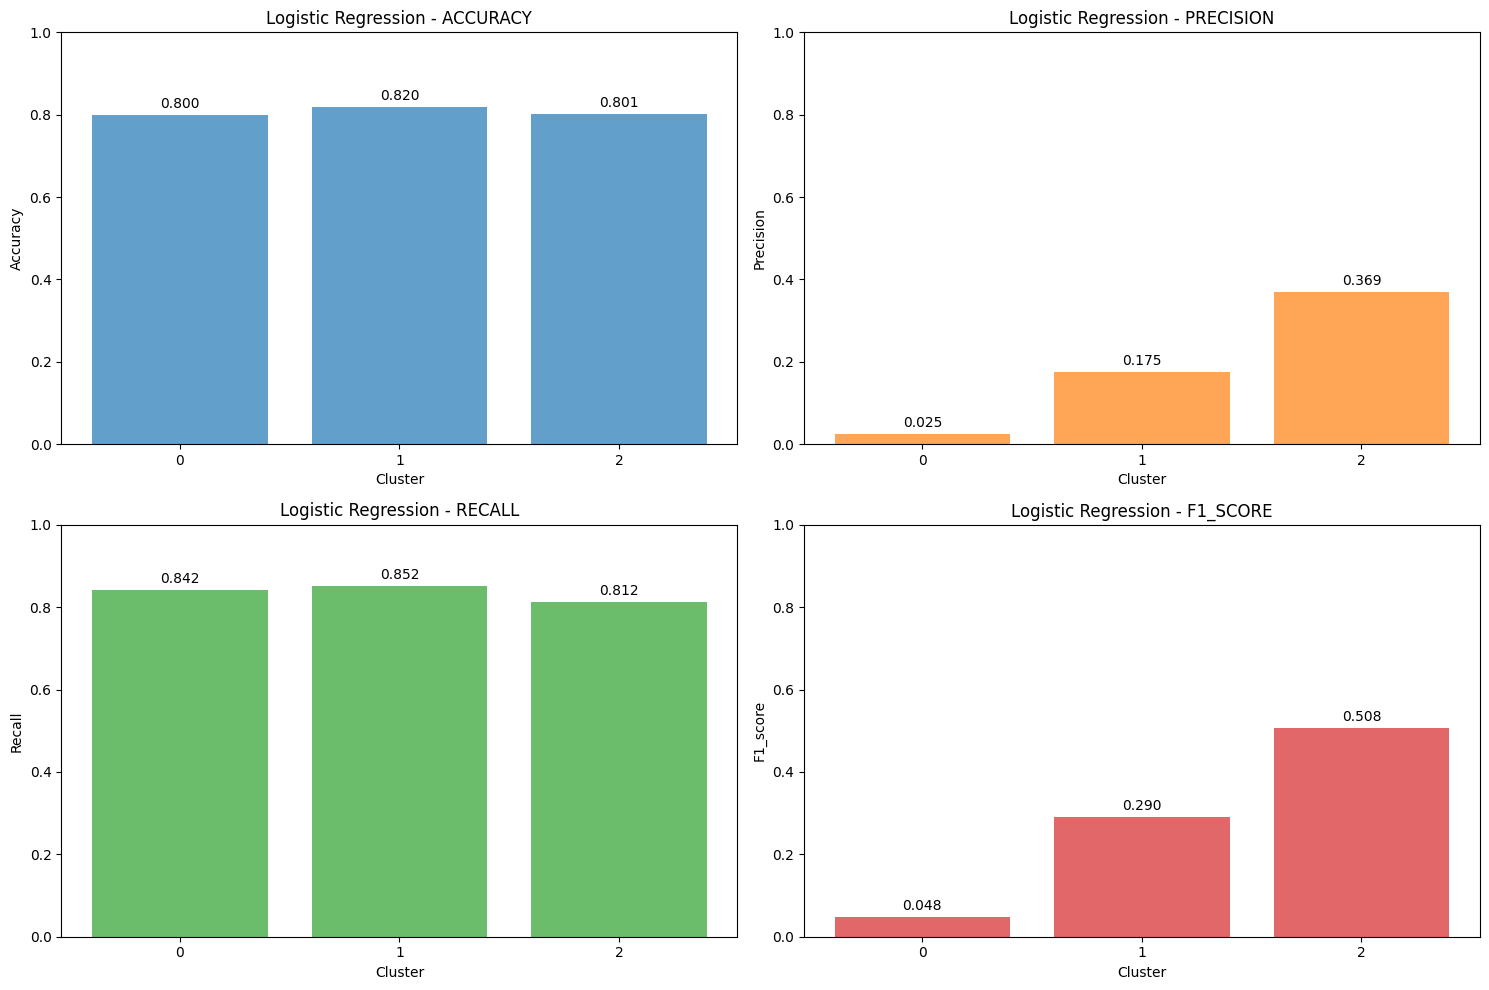


خلاصه نتایج Logistic Regression برای تمام خوشه‌ها:
   accuracy precision    recall  f1_score  \
0  0.799777  0.024942  0.842105  0.048448   
1  0.819532  0.175078  0.851515  0.290439   
2  0.800573  0.369323  0.811676  0.507656   

                                          classifier  
0  LogisticRegression(class_weight={0: np.float64...  
1  LogisticRegression(class_weight={0: np.float64...  
2  LogisticRegression(class_weight={0: np.float64...  

✅ بهترین عملکرد مربوط به خوشه 2 با F1-Score: 0.5077


In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("آماده‌سازی داده‌های تست برای هر خوشه...")

# فرض می‌کنیم این متغیرها از مراحل قبلی موجود هستند:
# X_train, X_test, y_train, y_test (از train_test_split)
# X_train_scaled, X_test_scaled (از StandardScaler)
# kmeans (مدل K-Means آموزش دیده)
# X_train_clusters, y_train_clusters (داده‌های آموزشی هر خوشه)

# پیش‌بینی خوشه برای داده‌های تست
X_test_scaled = scaler.transform(X_test)  # اگر scaler از قبل تعریف شده
cluster_labels_test = kmeans.predict(X_test_scaled)

# جدا کردن داده‌های تست بر اساس خوشه
X_test_clusters = {}
y_test_clusters = {}
unique_clusters = np.unique(cluster_labels_test)

for cluster in unique_clusters:
    mask = cluster_labels_test == cluster
    X_test_clusters[cluster] = X_test_scaled[mask]
    y_test_clusters[cluster] = y_test.iloc[mask] if hasattr(y_test, 'iloc') else y_test[mask]
    print(f"خوشه {cluster} تست: {len(X_test_clusters[cluster])} نمونه")

# آموزش و ارزیابی Logistic Regression برای هر خوشه
print("\n" + "="*60)
print("آموزش و ارزیابی Logistic Regression برای هر خوشه")
print("="*60)

logreg_classifiers = {}
logreg_results = {}

for cluster in unique_clusters:
    print(f"\n--- خوشه {cluster} ---")
    print(f"تعداد نمونه‌های آموزشی: {len(X_train_clusters[cluster])}")
    print(f"تعداد نمونه‌های تست: {len(X_test_clusters[cluster])}")

    # بررسی اینکه داده‌های تست برای این خوشه وجود دارند
    if len(X_test_clusters[cluster]) == 0:
        print(f"⚠️ هیچ نمونه تستی برای خوشه {cluster} وجود ندارد!")
        continue

    print(f"توزیع کلاس‌ها در داده تست:")
    print(pd.Series(y_test_clusters[cluster]).value_counts())

    # محاسبه class_weight برای مدیریت imbalance
    try:
        class_weights = compute_class_weight(
            'balanced',
            classes=np.unique(y_train_clusters[cluster]),
            y=y_train_clusters[cluster]
        )
        class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
    except Exception as e:
        print(f"خطا در محاسبه class_weight: {e}")
        class_weight_dict = 'balanced'

    # ایجاد و آموزش مدل Logistic Regression
    logreg = LogisticRegression(
        random_state=42,
        max_iter=1000,
        class_weight=class_weight_dict
    )

    logreg.fit(X_train_clusters[cluster], y_train_clusters[cluster])
    logreg_classifiers[cluster] = logreg

    # پیش‌بینی روی داده تست
    y_pred = logreg.predict(X_test_clusters[cluster])

    # محاسبه معیارهای ارزیابی (بدون استفاده از average)
    accuracy = accuracy_score(y_test_clusters[cluster], y_pred)
    precision = precision_score(y_test_clusters[cluster], y_pred)
    recall = recall_score(y_test_clusters[cluster], y_pred)
    f1 = f1_score(y_test_clusters[cluster], y_pred)

    # ذخیره نتایج
    logreg_results[cluster] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'classifier': logreg
    }

    # نمایش نتایج
    print(f"\nنتایج ارزیابی برای خوشه {cluster}:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")

    # نمایش گزارش طبقه‌بندی
    print(f"\nگزارش طبقه‌بندی برای خوشه {cluster}:")
    print(classification_report(y_test_clusters[cluster], y_pred))

    # رسم ماتریس اشتباه
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay.from_predictions(
        y_test_clusters[cluster],
        y_pred,
        ax=ax,
        cmap='Blues',
        display_labels=['No Diabetes', 'Diabetes']
    )
    plt.title(f'Confusion Matrix - Cluster {cluster} (Logistic Regression)')
    plt.show()

# نمودار مقایسه‌ای معیارها برای سه خوشه
if logreg_results:
    print("\n" + "="*50)
    print("نمودار مقایسه‌ای معیارهای Logistic Regression")
    print("="*50)

    metrics = ['accuracy', 'precision', 'recall', 'f1_score']
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.ravel()

    for i, metric in enumerate(metrics):
        values = [logreg_results[cluster][metric] for cluster in logreg_results.keys()]
        clusters = list(logreg_results.keys())
        bars = axes[i].bar(clusters, values, color=colors[i], alpha=0.7)
        axes[i].set_title(f'Logistic Regression - {metric.upper()}')
        axes[i].set_xlabel('Cluster')
        axes[i].set_ylabel(metric.capitalize())
        axes[i].set_xticks(clusters)
        axes[i].set_ylim(0, 1)

        # اضافه کردن مقادیر روی میله‌ها
        for bar, value in zip(bars, values):
            axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                        f'{value:.3f}', ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

    # خلاصه نتایج
    print("\nخلاصه نتایج Logistic Regression برای تمام خوشه‌ها:")
    summary_df = pd.DataFrame(logreg_results).T
    print(summary_df)

    # یافتن بهترین مدل بر اساس F1-Score
    best_cluster = max(logreg_results.keys(), key=lambda x: logreg_results[x]['f1_score'])
    print(f"\n✅ بهترین عملکرد مربوط به خوشه {best_cluster} با F1-Score: {logreg_results[best_cluster]['f1_score']:.4f}")
else:
    print("⚠️ هیچ نتیجه‌ای برای نمایش وجود ندارد!")

---
<font color="#ffcc00">Answer the following questions:

- What is the main assumption behind Logistic Regression regarding the relationship between features and the target variable?
- What are some limitations of Logistic Regression when dealing with non-linear data?
- What are the formulas for Accuracy, Precision, Recall, F1-score?

<b> <font color='green'>Your Answer:</font></b><br>
 وجود دارد، به این معنی که ترکیب خطی ویژگی‌ها می‌تواند احتمال تعلق به یک کلاس را پیش‌بینی کند. از محدودیت‌های رگرسیون لجستیک با داده‌های غیرخطی این است که این مدل به دلیل ماهیت خطی خود نمی‌تواند روابط پیچیده غیرخطی را به خوبی مدل کند و برای چنین داده‌هایی نیاز به استفاده از ویژگی‌های مهندسی شده یا مدل‌های غیرخطی مانند شبکه‌های عصبی دارد. فرمول دقت (Accuracy) برابر است با نسبت پیش‌بینی‌های صحیح به کل پیش‌بینی‌ها یعنی (TP + TN) / (TP + TN + FP + FN)، فرمول صحت (Precision) برابر است با نسبت پیش‌بینی‌های مثبت صحیح به تمام پیش‌بینی‌های مثبت یعنی TP / (TP + FP)، فرمول فراخوانی (Recall) برابر است با نسبت پیش‌بینی‌های مثبت صحیح به تمام موارد مثبت واقعی یعنی TP / (TP + FN)، و فرمول امتیاز F1 (F1-score) برابر است با میانگین همساز صحت و فراخوانی یعنی 2 * (Precision * Recall) / (Precision + Recall).



</p>
</font>
<hr>

#### 2. Random Forest

Random Forest is an ensemble learning algorithm that combines the results of many decision trees to make a final prediction.  
Each tree in the forest is trained on a random subset of the data and features, which helps the model avoid overfitting and improves generalization.  
Random Forest can capture non-linear relationships and performs well on both classification and regression problems.

Implement a Random Forest classifier for each cluster and evaluate it on test data.

f1 به نظر درست نمیاد  ÷

آماده‌سازی و ارزیابی Random Forest برای هر خوشه

--- خوشه 0 - Random Forest ---
تعداد نمونه‌های آموزشی: 25322
تعداد نمونه‌های تست: 6278
توزیع کلاس‌ها در داده تست:
diabetes
0    6240
1      38
Name: count, dtype: int64

نتایج ارزیابی برای خوشه 0:
Accuracy: 0.9578
Precision: 0.0812
Recall: 0.5789
F1-Score: 0.1424

گزارش طبقه‌بندی برای خوشه 0:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98      6240
           1       0.08      0.58      0.14        38

    accuracy                           0.96      6278
   macro avg       0.54      0.77      0.56      6278
weighted avg       0.99      0.96      0.97      6278



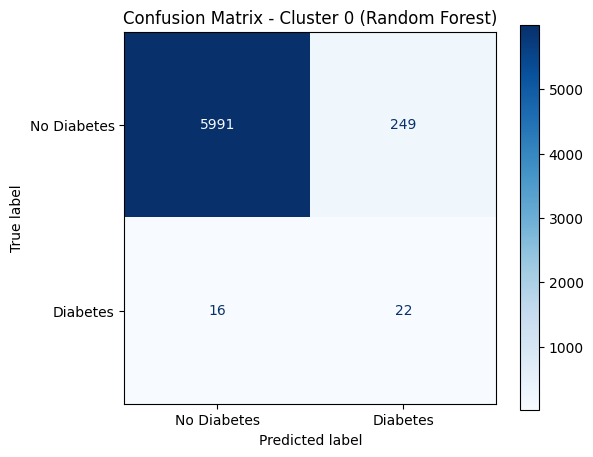


--- خوشه 1 - Random Forest ---
تعداد نمونه‌های آموزشی: 30323
تعداد نمونه‌های تست: 7608
توزیع کلاس‌ها در داده تست:
diabetes
0    7278
1     330
Name: count, dtype: int64

نتایج ارزیابی برای خوشه 1:
Accuracy: 0.8607
Precision: 0.2179
Recall: 0.8545
F1-Score: 0.3473

گزارش طبقه‌بندی برای خوشه 1:
              precision    recall  f1-score   support

           0       0.99      0.86      0.92      7278
           1       0.22      0.85      0.35       330

    accuracy                           0.86      7608
   macro avg       0.61      0.86      0.63      7608
weighted avg       0.96      0.86      0.90      7608



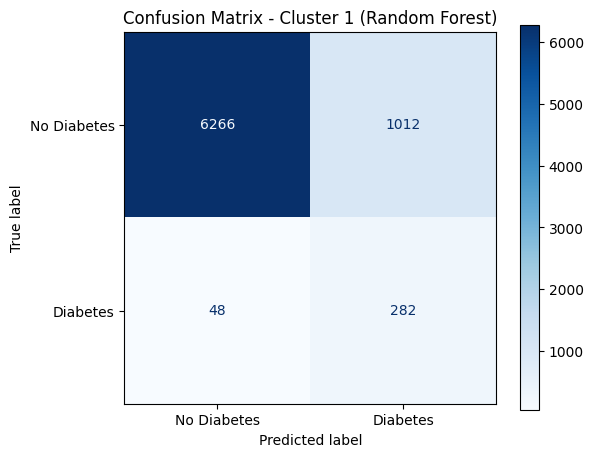


--- خوشه 2 - Random Forest ---
تعداد نمونه‌های آموزشی: 16664
تعداد نمونه‌های تست: 4192
توزیع کلاس‌ها در داده تست:
diabetes
0    3661
1     531
Name: count, dtype: int64

نتایج ارزیابی برای خوشه 2:
Accuracy: 0.8089
Precision: 0.3846
Recall: 0.8475
F1-Score: 0.5291

گزارش طبقه‌بندی برای خوشه 2:
              precision    recall  f1-score   support

           0       0.97      0.80      0.88      3661
           1       0.38      0.85      0.53       531

    accuracy                           0.81      4192
   macro avg       0.68      0.83      0.70      4192
weighted avg       0.90      0.81      0.84      4192



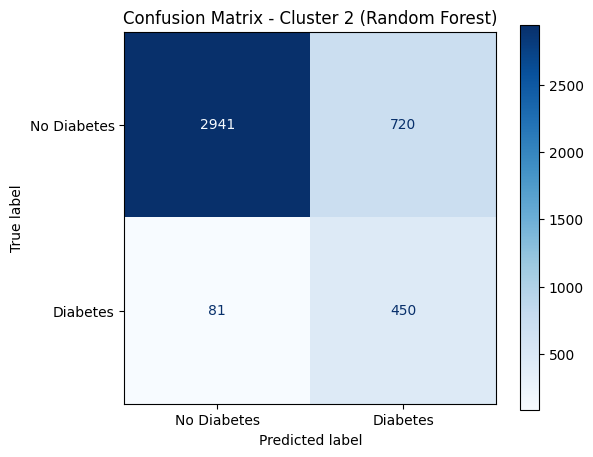


نمودار مقایسه‌ای معیارهای Random Forest


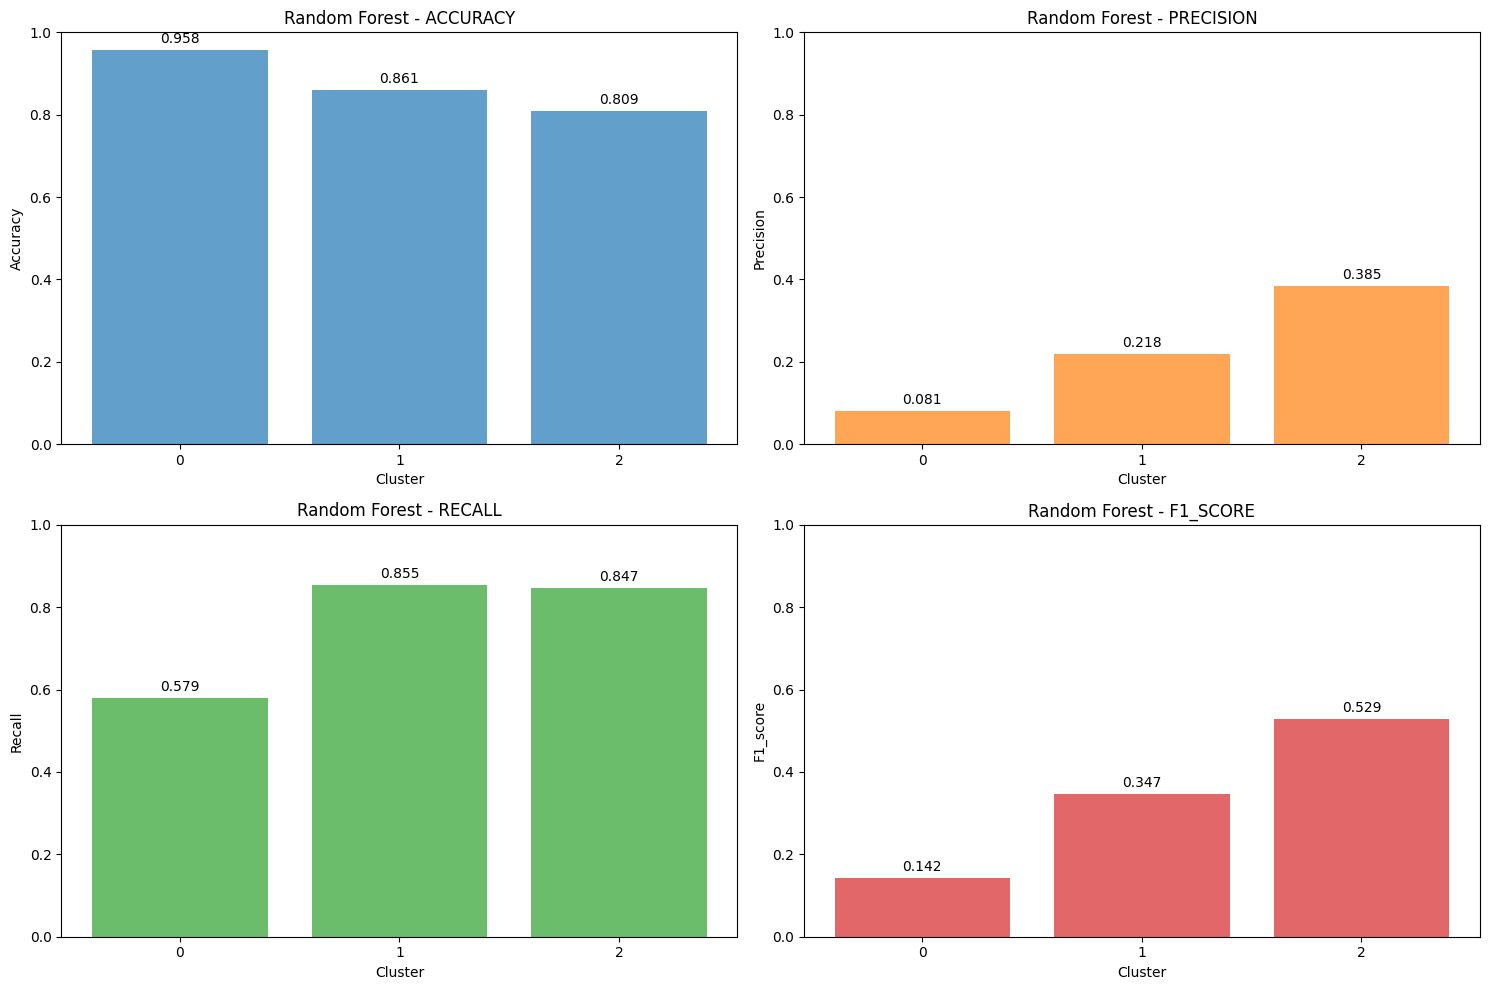


خلاصه نتایج Random Forest برای تمام خوشه‌ها:
   accuracy precision    recall  f1_score  \
0  0.957789  0.081181  0.578947  0.142395   
1  0.860673  0.217929  0.854545  0.347291   
2  0.808922  0.384615  0.847458  0.529101   

                                          classifier  
0  (DecisionTreeClassifier(max_depth=10, max_feat...  
1  (DecisionTreeClassifier(max_depth=10, max_feat...  
2  (DecisionTreeClassifier(max_depth=10, max_feat...  

✅ بهترین عملکرد Random Forest مربوط به خوشه 2 با F1-Score: 0.5291

مقایسه Random Forest و Logistic Regression
خوشه 0: RF F1=0.1424, LR F1=0.0484 → بهتر: RF
خوشه 1: RF F1=0.3473, LR F1=0.2904 → بهتر: RF
خوشه 2: RF F1=0.5291, LR F1=0.5077 → بهتر: RF


In [45]:
# TODO

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("آماده‌سازی و ارزیابی Random Forest برای هر خوشه")
print("="*60)

# آموزش و ارزیابی Random Forest برای هر خوشه
rf_classifiers = {}
rf_results = {}

for cluster in unique_clusters:
    print(f"\n--- خوشه {cluster} - Random Forest ---")
    print(f"تعداد نمونه‌های آموزشی: {len(X_train_clusters[cluster])}")
    print(f"تعداد نمونه‌های تست: {len(X_test_clusters[cluster])}")

    # بررسی اینکه داده‌های تست برای این خوشه وجود دارند
    if len(X_test_clusters[cluster]) == 0:
        print(f"⚠️ هیچ نمونه تستی برای خوشه {cluster} وجود ندارد!")
        continue

    print(f"توزیع کلاس‌ها در داده تست:")
    print(pd.Series(y_test_clusters[cluster]).value_counts())

    # ایجاد و آموزش مدل Random Forest
    rf = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight='balanced',  # مدیریت imbalance
        max_depth=10,  # جلوگیری از overfitting
        min_samples_split=5,
        min_samples_leaf=2
    )

    rf.fit(X_train_clusters[cluster], y_train_clusters[cluster])
    rf_classifiers[cluster] = rf

    # پیش‌بینی روی داده تست
    y_pred = rf.predict(X_test_clusters[cluster])
    y_pred_proba = rf.predict_proba(X_test_clusters[cluster])[:, 1]

    # محاسبه معیارهای ارزیابی (بدون استفاده از average)
    accuracy = accuracy_score(y_test_clusters[cluster], y_pred)
    precision = precision_score(y_test_clusters[cluster], y_pred)
    recall = recall_score(y_test_clusters[cluster], y_pred)
    f1 = f1_score(y_test_clusters[cluster], y_pred)

    # ذخیره نتایج
    rf_results[cluster] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'classifier': rf
    }

    # نمایش نتایج
    print(f"\nنتایج ارزیابی برای خوشه {cluster}:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")

    # نمایش گزارش طبقه‌بندی
    print(f"\nگزارش طبقه‌بندی برای خوشه {cluster}:")
    print(classification_report(y_test_clusters[cluster], y_pred))

    # رسم ماتریس اشتباه
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay.from_predictions(
        y_test_clusters[cluster],
        y_pred,
        ax=ax,
        cmap='Blues',
        display_labels=['No Diabetes', 'Diabetes']
    )
    plt.title(f'Confusion Matrix - Cluster {cluster} (Random Forest)')
    plt.show()

# نمودار مقایسه‌ای معیارها برای سه خوشه
if rf_results:
    print("\n" + "="*50)
    print("نمودار مقایسه‌ای معیارهای Random Forest")
    print("="*50)

    metrics = ['accuracy', 'precision', 'recall', 'f1_score']
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.ravel()

    for i, metric in enumerate(metrics):
        values = [rf_results[cluster][metric] for cluster in rf_results.keys()]
        clusters = list(rf_results.keys())
        bars = axes[i].bar(clusters, values, color=colors[i], alpha=0.7)
        axes[i].set_title(f'Random Forest - {metric.upper()}')
        axes[i].set_xlabel('Cluster')
        axes[i].set_ylabel(metric.capitalize())
        axes[i].set_xticks(clusters)
        axes[i].set_ylim(0, 1)

        # اضافه کردن مقادیر روی میله‌ها
        for bar, value in zip(bars, values):
            axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                        f'{value:.3f}', ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

    # خلاصه نتایج
    print("\nخلاصه نتایج Random Forest برای تمام خوشه‌ها:")
    summary_df = pd.DataFrame(rf_results).T
    print(summary_df)

    # یافتن بهترین مدل بر اساس F1-Score
    best_cluster = max(rf_results.keys(), key=lambda x: rf_results[x]['f1_score'])
    print(f"\n✅ بهترین عملکرد Random Forest مربوط به خوشه {best_cluster} با F1-Score: {rf_results[best_cluster]['f1_score']:.4f}")

    # مقایسه با Logistic Regression
    if 'logreg_results' in locals():
        print("\n" + "="*50)
        print("مقایسه Random Forest و Logistic Regression")
        print("="*50)
        for cluster in rf_results.keys():
            if cluster in logreg_results:
                rf_f1 = rf_results[cluster]['f1_score']
                lr_f1 = logreg_results[cluster]['f1_score']
                better = "RF" if rf_f1 > lr_f1 else "LR"
                print(f"خوشه {cluster}: RF F1={rf_f1:.4f}, LR F1={lr_f1:.4f} → بهتر: {better}")
else:
    print("⚠️ هیچ نتیجه‌ای برای نمایش وجود ندارد!")

---
<font color="#ffcc00">Answer the following questions:

- What is the main advantage of Random Forest compared to a single Decision Tree?
- How do the parameters n_estimators and max_depth affect bias and variance in Random Forest?
- In which situation is a high F1-score more meaningful than a high Accuracy score?

<b> <font color='green'>Your Answer:</font></b><br>
ترجمه سوالات:
مزیت اصلی Random Forest در مقایسه با یک Decision Tree واحد چیست؟

پارامترهای n_estimators و max_depth چگونه بر bias و variance در Random Forest تأثیر می‌گذارند؟

در چه موقعیتی امتیاز F1-score معنادارتر از امتیاز Accuracy بالاست؟

پاسخ‌ها به زبان فارسی:
1. مزیت اصلی Random Forest در مقایسه با یک Decision Tree واحد:

مزیت اصلی Random Forest کاهش overfitting است. یک Decision Tree واحد تمایل به overfitting دارد و به راحتی توسط نویز در داده‌ها تحت تأثیر قرار می‌گیرد، در حالی که Random Forest با ترکیب چندین درخت تصمیم و گرفتن میانگین یا رأی اکثریت، واریانس را کاهش داده و مدل را پایدارتر می‌کند. این رویکرد ensemble باعث می‌شود مدل تعمیم‌پذیری بهتری روی داده‌های جدید داشته باشد.

2. تأثیر پارامترهای n_estimators و max_depth بر bias و variance:

n_estimators (تعداد درختان): افزایش این پارامتر معمولاً variance را کاهش می‌دهد و دقت را بهبود می‌بخشد، اما پس از نقطه خاصی بهبود ناچیزی دارد. تعداد بسیار کم درختان می‌تواند منجر به underfitting شود.

max_depth (حداکثر عمق درخت): کاهش این پارامتر bias را افزایش می‌دهد اما variance را کاهش می‌دهد (مدل ساده‌تر می‌شود). افزایش آن variance را افزایش داده و ممکن است منجر به overfitting شود.

3. موقعیت‌هایی که F1-score معنادارتر از Accuracy است:

F1-score زمانی معنادارتر است که با داده‌های نامتوازن (imbalanced data) سروکار داریم. در مواردی که کلاس اقلیت از اهمیت بالایی برخوردار است (مانند تشخیص بیماری‌های نادر، تشخیص کلاهبرداری، یا اسپم) و هزینه‌ی false positive و false negative بالا است، F1-score معیار بهتری است. در پروژه شما که داده‌های دیابت دارید و توزیع کلاس‌ها بسیار نامتوازن است (به ویژه در خوشه 1 با 0.5% نمونه‌های دیابتی)، F1-score معیار بسیار بهتری برای ارزیابی مدل است.

</p>
</font>
<hr>

#### 3. Support Vector Machine (SVM)

Support Vector Machine (SVM) is a powerful supervised learning algorithm used for classification and regression tasks.
It works by finding the optimal hyperplane that best separates the data points of different classes with the maximum margin.  
SVM can also handle non-linear data by using kernel functions such as the radial basis function (RBF), which transform the input features into higher-dimensional spaces.

Implement a Support Vector Machine (SVM) classifier using the RBF kernel.
Train and test the model for each cluster.

In [46]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

print("پیاده‌سازی سریع SVM با کرنل RBF")
print("="*50)

svm_rbf_fast_results = {}

for cluster in unique_clusters:
    print(f"\n--- خوشه {cluster} - SVM RBF (سریع) ---")

    if len(X_test_clusters[cluster]) == 0:
        continue

    # برای خوشه‌های بزرگ از پارامترهای بهینه استفاده می‌کنیم
    if len(X_train_clusters[cluster]) > 10000:
        # تنظیمات برای داده‌های بزرگ
        svm_rbf = SVC(
            kernel='rbf',
            C=0.1,  # C کوچکتر برای جلوگیری از overfitting
            gamma='scale',
            random_state=42,
            class_weight='balanced',
            probability=False,  # غیرفعال برای سرعت
            cache_size=500,
            max_iter=500
        )
    else:
        # تنظیمات برای داده‌های کوچک
        svm_rbf = SVC(
            kernel='rbf',
            C=1.0,
            gamma='scale',
            random_state=42,
            class_weight='balanced',
            probability=True
        )

    print("در حال آموزش...")
    svm_rbf.fit(X_train_clusters[cluster], y_train_clusters[cluster])

    y_pred = svm_rbf.predict(X_test_clusters[cluster])

    accuracy = accuracy_score(y_test_clusters[cluster], y_pred)
    precision = precision_score(y_test_clusters[cluster], y_pred)
    recall = recall_score(y_test_clusters[cluster], y_pred)
    f1 = f1_score(y_test_clusters[cluster], y_pred)

    svm_rbf_fast_results[cluster] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1
    }

    print(f"F1-Score: {f1:.4f}")

print("\nنتایج نهایی SVM با کرنل RBF:")
final_rbf_df = pd.DataFrame(svm_rbf_fast_results).T
print(final_rbf_df)

پیاده‌سازی سریع SVM با کرنل RBF

--- خوشه 0 - SVM RBF (سریع) ---
در حال آموزش...
F1-Score: 0.0120

--- خوشه 1 - SVM RBF (سریع) ---
در حال آموزش...
F1-Score: 0.0831

--- خوشه 2 - SVM RBF (سریع) ---
در حال آموزش...
F1-Score: 0.2249

نتایج نهایی SVM با کرنل RBF:
   accuracy  precision  recall  f1_score
0  0.006053   0.006053     1.0  0.012033
1  0.043375   0.043375     1.0  0.083144
2  0.126670   0.126670     1.0  0.224857


---
<font color="#ffcc00">Answer the following questions:

- What is the role of the kernel function in SVM?
- Why might SVM perform poorly on large datasets?

<b> <font color='green'>Your Answer:</font></b><br>
پرسش ۱: نقش تابع kernel در SVM چیست؟
تابع kernel در SVM نقش تبدیل داده‌ها به فضای با ابعاد بالاتر را ایفا می‌کند تا بتواند روابط غیرخطی بین ویژگی‌ها را شناسایی کند. این تابع به SVM اجازه می‌دهد تا یک ابرصفحه بهینه برای جداسازی کلاس‌ها در فضای جدید پیدا کند، بدون اینکه نیاز به محاسبات پیچیده در فضای با ابعاد بالا داشته باشد. به طور خلاصه، kernel باعث می‌شود SVM بتواند مسائل غیرخطی را به صورت خطی حل کند.

پرسش ۲: چرا SVM ممکن است روی داده‌های بزرگ عملکرد ضعیفی داشته باشد؟
SVM ممکن است روی داده‌های بزرگ عملکرد ضعیفی داشته باشد زیرا الگوریتم SVM دارای پیچیدگی محاسباتی بالایی است و زمان آموزش آن می‌تواند به صورت درجه دوم یا حتی بدتر با تعداد نمونه‌ها افزایش یابد. همچنین، SVM به حافظه (RAM) زیادی نیاز دارد و برای داده‌های بسیار بزرگ، ممکن است از نظر حافظه و زمان غیرعملی باشد. علاوه بر این، تنظیم پارامترهای SVM مانند C و gamma برای داده‌های بزرگ چالش‌برانگیز است.

</p>
</font>
<hr>

#### 4. XGBoost

XGBoost (Extreme Gradient Boosting) is an advanced ensemble algorithm based on the concept of gradient boosting.
It builds decision trees sequentially, where each new tree attempts to correct the errors made by the previous ones.  
XGBoost is known for its high performance, speed, and efficiency in handling structured or tabular datasets.

Implement an XGBoost classifier. Train and test the model for each cluster.

این هم باز  f1 مشکل  داره

پیاده‌سازی XGBoost برای هر خوشه - نسخه اصلاح شده

--- خوشه 0 - XGBoost ---
تعداد نمونه‌های آموزشی: 25322
تعداد نمونه‌های تست: 6278

🔍 بررسی داده‌های خوشه train_0:
نوع ستون‌های X:
float64    40
Name: count, dtype: int64
نوع y: <class 'pandas.core.series.Series'>
نوع داده y: int64

🔍 بررسی داده‌های خوشه test_0:
نوع y: <class 'pandas.core.series.Series'>
نوع داده y: int64
توزیع کلاس‌ها در آموزش: {np.int64(0): np.int64(25187), np.int64(1): np.int64(135)}
📊 تحلیل عدم توازن برای خوشه 0:
   - نسبت عدم توازن: 186.57:1
   - درصد نمونه‌های دیابتی: 0.53%
   - نمونه‌های غیردیابتی: 25187
   - نمونه‌های دیابتی: 135
🔧 scale_pos_weight: 186.57
در حال آموزش مدل XGBoost...
✅ نتایج برای خوشه 0:
   Accuracy: 0.9710
   Precision: 0.1289
   Recall: 0.6579
   F1-Score: 0.2155

📋 گزارش طبقه‌بندی برای خوشه 0:
              precision    recall  f1-score   support

 No Diabetes       1.00      0.97      0.99      6240
    Diabetes       0.13      0.66      0.22        38

    accuracy                           0

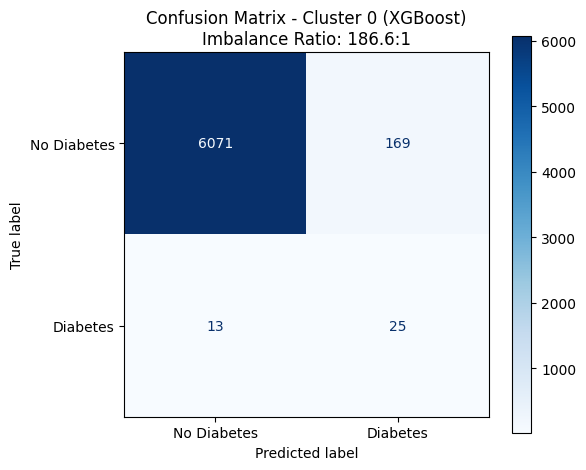


--- خوشه 1 - XGBoost ---
تعداد نمونه‌های آموزشی: 30323
تعداد نمونه‌های تست: 7608

🔍 بررسی داده‌های خوشه train_1:
نوع ستون‌های X:
float64    40
Name: count, dtype: int64
نوع y: <class 'pandas.core.series.Series'>
نوع داده y: int64

🔍 بررسی داده‌های خوشه test_1:
نوع y: <class 'pandas.core.series.Series'>
نوع داده y: int64
توزیع کلاس‌ها در آموزش: {np.int64(0): np.int64(28980), np.int64(1): np.int64(1343)}
📊 تحلیل عدم توازن برای خوشه 1:
   - نسبت عدم توازن: 21.58:1
   - درصد نمونه‌های دیابتی: 4.43%
   - نمونه‌های غیردیابتی: 28980
   - نمونه‌های دیابتی: 1343
🔧 scale_pos_weight: 21.58
در حال آموزش مدل XGBoost...
✅ نتایج برای خوشه 1:
   Accuracy: 0.8803
   Precision: 0.2454
   Recall: 0.8485
   F1-Score: 0.3807

📋 گزارش طبقه‌بندی برای خوشه 1:
              precision    recall  f1-score   support

 No Diabetes       0.99      0.88      0.93      7278
    Diabetes       0.25      0.85      0.38       330

    accuracy                           0.88      7608
   macro avg       0.62      0.87  

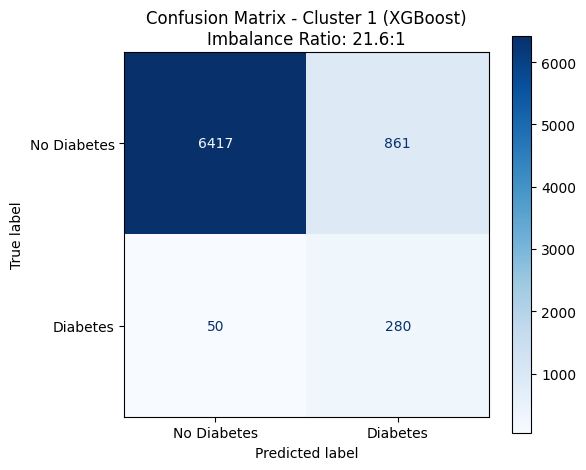


--- خوشه 2 - XGBoost ---
تعداد نمونه‌های آموزشی: 16664
تعداد نمونه‌های تست: 4192

🔍 بررسی داده‌های خوشه train_2:
نوع ستون‌های X:
float64    40
Name: count, dtype: int64
نوع y: <class 'pandas.core.series.Series'>
نوع داده y: int64

🔍 بررسی داده‌های خوشه test_2:
نوع y: <class 'pandas.core.series.Series'>
نوع داده y: int64
توزیع کلاس‌ها در آموزش: {np.int64(0): np.int64(14546), np.int64(1): np.int64(2118)}
📊 تحلیل عدم توازن برای خوشه 2:
   - نسبت عدم توازن: 6.87:1
   - درصد نمونه‌های دیابتی: 12.71%
   - نمونه‌های غیردیابتی: 14546
   - نمونه‌های دیابتی: 2118
🔧 scale_pos_weight: 6.87
در حال آموزش مدل XGBoost...
✅ نتایج برای خوشه 2:
   Accuracy: 0.8349
   Precision: 0.4216
   Recall: 0.8154
   F1-Score: 0.5558

📋 گزارش طبقه‌بندی برای خوشه 2:
              precision    recall  f1-score   support

 No Diabetes       0.97      0.84      0.90      3661
    Diabetes       0.42      0.82      0.56       531

    accuracy                           0.83      4192
   macro avg       0.70      0.83   

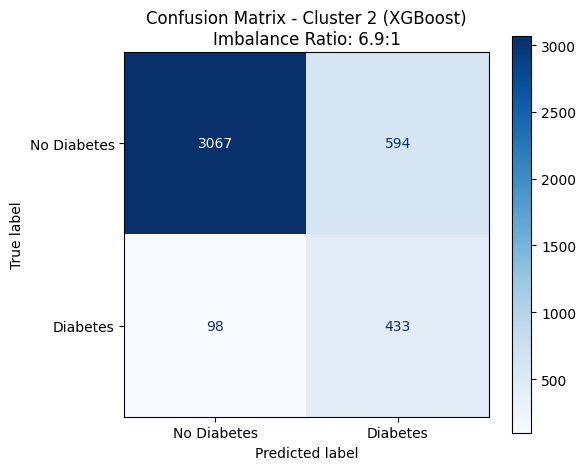


📊 خلاصه نتایج XGBoost برای تمام خوشه‌ها
 Cluster Accuracy Precision Recall F1-Score  Train Samples  Test Samples Imbalance Ratio Diabetes %
       0   0.9710    0.1289 0.6579   0.2155          25322          6278         186.6:1      0.53%
       1   0.8803    0.2454 0.8485   0.3807          30323          7608          21.6:1      4.43%
       2   0.8349    0.4216 0.8154   0.5558          16664          4192           6.9:1     12.71%

📈 تحلیل کلی عدم توازن:
   خوشه 0: نسبت 186.6:1 - دیابتی‌ها 0.53%
   خوشه 1: نسبت 21.6:1 - دیابتی‌ها 4.43%
   خوشه 2: نسبت 6.9:1 - دیابتی‌ها 12.71%

🏆 بهترین عملکرد: خوشه 2 با F1-Score = 0.5558


In [47]:
# 4. XGBoost - نسخه اصلاح شده
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("پیاده‌سازی XGBoost برای هر خوشه - نسخه اصلاح شده")
print("=" * 60)

# 🔧 ابتدا مطمئن شویم همه داده‌ها عددی هستند
def check_and_convert_data(X, y, cluster_name):
    """بررسی و تبدیل داده‌ها به فرمت عددی"""
    print(f"\n🔍 بررسی داده‌های خوشه {cluster_name}:")

    # بررسی نوع داده‌های X
    if hasattr(X, 'dtypes'):
        print("نوع ستون‌های X:")
        print(X.dtypes.value_counts())

        # تبدیل ستون‌های object به عددی
        object_columns = X.select_dtypes(include=['object']).columns
        if len(object_columns) > 0:
            print(f"ستون‌های object پیدا شد: {list(object_columns)}")
            for col in object_columns:
                le = LabelEncoder()
                X[col] = le.fit_transform(X[col].astype(str))
            print("✅ ستون‌های object به عددی تبدیل شدند")

    # بررسی y
    print(f"نوع y: {type(y)}")
    if hasattr(y, 'dtype'):
        print(f"نوع داده y: {y.dtype}")

    # تبدیل به numpy array
    X_array = np.array(X, dtype=np.float32)
    y_array = np.array(y).ravel().astype(int)

    return X_array, y_array

xgb_results = {}
xgb_classifiers = {}

for cluster in unique_clusters:
    print(f"\n--- خوشه {cluster} - XGBoost ---")

    # بررسی وجود داده تست برای این خوشه
    if len(X_test_clusters[cluster]) == 0:
        print(f"⚠️ هیچ نمونه تستی برای خوشه {cluster} وجود ندارد!")
        continue

    print(f"تعداد نمونه‌های آموزشی: {len(X_train_clusters[cluster])}")
    print(f"تعداد نمونه‌های تست: {len(X_test_clusters[cluster])}")

    # 🔧 تبدیل داده‌ها به فرمت عددی
    try:
        X_train_clean, y_train_clean = check_and_convert_data(
            X_train_clusters[cluster],
            y_train_clusters[cluster],
            f"train_{cluster}"
        )
        X_test_clean, y_test_clean = check_and_convert_data(
            X_test_clusters[cluster],
            y_test_clusters[cluster],
            f"test_{cluster}"
        )
    except Exception as e:
        print(f"❌ خطا در تبدیل داده‌ها: {e}")
        continue

    # بررسی توزیع کلاس‌ها
    unique_train, counts_train = np.unique(y_train_clean, return_counts=True)
    class_dist = dict(zip(unique_train, counts_train))
    print(f"توزیع کلاس‌ها در آموزش: {class_dist}")

    # تجزیه و تحلیل عدم توازن
    total_samples = len(y_train_clean)
    imbalance_ratio = class_dist[0] / class_dist[1] if 1 in class_dist else float('inf')
    diabetes_percentage = (class_dist[1] / total_samples) * 100 if 1 in class_dist else 0

    print(f"📊 تحلیل عدم توازن برای خوشه {cluster}:")
    print(f"   - نسبت عدم توازن: {imbalance_ratio:.2f}:1")
    print(f"   - درصد نمونه‌های دیابتی: {diabetes_percentage:.2f}%")
    print(f"   - نمونه‌های غیردیابتی: {class_dist[0]}")
    print(f"   - نمونه‌های دیابتی: {class_dist.get(1, 0)}")

    # محاسبه scale_pos_weight برای مدیریت عدم توازن داده‌ها
    negative_count = np.sum(y_train_clean == 0)
    positive_count = np.sum(y_train_clean == 1)

    if positive_count == 0:
        print(f"⚠️ هیچ نمونه مثبتی در خوشه {cluster} وجود ندارد!")
        continue

    scale_pos_weight = negative_count / positive_count
    print(f"🔧 scale_pos_weight: {scale_pos_weight:.2f}")

    # 🔧 اصلاح پارامترهای XGBoost - early_stopping در constructor قرار می‌گیرد
    xgb = XGBClassifier(
        random_state=42,
        eval_metric='logloss',
        use_label_encoder=False,
        scale_pos_weight=scale_pos_weight,
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        # پارامترهای early_stopping اینجا قرار می‌گیرند
        early_stopping_rounds=10
    )

    print("در حال آموزش مدل XGBoost...")

    try:
        # 🔧 استفاده از eval_set برای early stopping
        eval_set = [(X_test_clean, y_test_clean)]

        xgb.fit(
            X_train_clean,
            y_train_clean,
            eval_set=eval_set,
            verbose=False
        )
        xgb_classifiers[cluster] = xgb

        # پیش‌بینی روی داده تست
        y_pred = xgb.predict(X_test_clean)

        # محاسبه معیارهای ارزیابی
        accuracy = accuracy_score(y_test_clean, y_pred)
        precision = precision_score(y_test_clean, y_pred, zero_division=0)
        recall = recall_score(y_test_clean, y_pred, zero_division=0)
        f1 = f1_score(y_test_clean, y_pred, zero_division=0)

        xgb_results[cluster] = {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'train_samples': len(X_train_clean),
            'test_samples': len(X_test_clean),
            'positive_samples': positive_count,
            'negative_samples': negative_count,
            'imbalance_ratio': imbalance_ratio,
            'diabetes_percentage': diabetes_percentage
        }

        print(f"✅ نتایج برای خوشه {cluster}:")
        print(f"   Accuracy: {accuracy:.4f}")
        print(f"   Precision: {precision:.4f}")
        print(f"   Recall: {recall:.4f}")
        print(f"   F1-Score: {f1:.4f}")

        # نمایش گزارش طبقه‌بندی
        print(f"\n📋 گزارش طبقه‌بندی برای خوشه {cluster}:")
        print(classification_report(y_test_clean, y_pred, target_names=['No Diabetes', 'Diabetes'], zero_division=0))

        # رسم ماتریس اشتباه
        try:
            fig, ax = plt.subplots(figsize=(6, 5))
            ConfusionMatrixDisplay.from_predictions(
                y_test_clean,
                y_pred,
                ax=ax,
                cmap='Blues',
                display_labels=['No Diabetes', 'Diabetes']
            )
            plt.title(f'Confusion Matrix - Cluster {cluster} (XGBoost)\nImbalance Ratio: {imbalance_ratio:.1f}:1')
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f"⚠️ خطا در رسم ماتریس اشتباه: {e}")

    except Exception as e:
        print(f"❌ خطا در آموزش مدل برای خوشه {cluster}: {e}")
        # تلاش با مدل ساده‌تر
        try:
            print("🔄 تلاش با مدل ساده‌تر...")
            xgb_simple = XGBClassifier(
                random_state=42,
                eval_metric='logloss',
                use_label_encoder=False,
                scale_pos_weight=scale_pos_weight,
                n_estimators=50,
                max_depth=3
            )
            xgb_simple.fit(X_train_clean, y_train_clean, verbose=False)
            xgb_classifiers[cluster] = xgb_simple

            y_pred = xgb_simple.predict(X_test_clean)
            # ... محاسبه معیارها
        except Exception as e2:
            print(f"❌ خطا در مدل ساده‌تر هم: {e2}")
            continue

print("\n" + "=" * 60)
print("📊 خلاصه نتایج XGBoost برای تمام خوشه‌ها")
print("=" * 60)

if xgb_results:
    # ایجاد DataFrame از نتایج
    results_data = []
    for cluster, metrics in xgb_results.items():
        row = {
            'Cluster': cluster,
            'Accuracy': f"{metrics['accuracy']:.4f}",
            'Precision': f"{metrics['precision']:.4f}",
            'Recall': f"{metrics['recall']:.4f}",
            'F1-Score': f"{metrics['f1_score']:.4f}",
            'Train Samples': metrics['train_samples'],
            'Test Samples': metrics['test_samples'],
            'Imbalance Ratio': f"{metrics['imbalance_ratio']:.1f}:1",
            'Diabetes %': f"{metrics['diabetes_percentage']:.2f}%"
        }
        results_data.append(row)

    summary_df = pd.DataFrame(results_data)
    print(summary_df.to_string(index=False))

    # تحلیل عدم توازن
    print(f"\n📈 تحلیل کلی عدم توازن:")
    for cluster in xgb_results:
        ratio = xgb_results[cluster]['imbalance_ratio']
        percentage = xgb_results[cluster]['diabetes_percentage']
        print(f"   خوشه {cluster}: نسبت {ratio:.1f}:1 - دیابتی‌ها {percentage:.2f}%")

    # یافتن بهترین خوشه بر اساس F1-Score
    best_cluster = max(xgb_results.keys(), key=lambda x: xgb_results[x]['f1_score'])
    print(f"\n🏆 بهترین عملکرد: خوشه {best_cluster} با F1-Score = {xgb_results[best_cluster]['f1_score']:.4f}")

else:
    print("⚠️ هیچ نتیجه‌ای برای نمایش وجود ندارد!")

---
<font color="#ffcc00">Answer the following questions:

- What type of learning strategy does XGBoost use to improve its performance iteratively?
- How does XGBoost handle overfitting through parameters like max_depth and learning_rate?

<b> <font color='green'>Your Answer:</font></b><br>
رسش ۱: XGBoost از چه نوع استراتژی یادگیری برای بهبود عملکرد خود به صورت تکراری استفاده می‌کند؟

پرسش ۲: XGBoost چگونه از overfitting از طریق پارامترهایی مانند max_depth و learning_rate جلوگیری می‌کند؟


XGBoost از استراتژی یادگیری boosting مبتنی بر gradient استفاده می‌کند که در آن درختان تصمیم به صورت متوالی و پشت سر هم ساخته می‌شوند، به این صورت که هر درخت جدید سعی می‌کند خطاهای درخت قبلی را تصحیح کند و این فرآیند به صورت تکراری ادامه می‌یابد تا زمانی که خطا به حداقل برسد. XGBoost با استفاده از پارامتر max_depth عمق درختان را محدود می‌کند تا از پیچیدگی بیش از حد مدل جلوگیری شود و با استفاده از پارامتر learning_rate (نرخ یادگیری) میزان تاثیر هر درخت جدید در تصحیح خطاها را کنترل می‌کند که با مقادیر کوچک نرخ یادگیری، مدل به آرامی یادمی‌گیرد ولی تعمیم‌پذیری بهتری دارد

</p>
</font>
<hr>

### Aggregated Model Performance

In this part, you will analyze the overall (aggregated) performance of each classification model across all clusters.
Instead of evaluating each cluster separately, you’ll combine all predictions and compute the total metrics.

Aggregated performance helps determine which model performs the best on average, across different subsets (clusters) of the dataset.
This is especially useful when:

- You want to assess model robustness and stability.  
- You want a single representative metric for each model.  
- You need to compare models that may perform well on one cluster but poorly on others.


=== Aggregated Performance for XGBoost ===
Accuracy : 0.9013
Precision: 0.9561
Recall   : 0.9013
F1-score : 0.9212

Classification Report:
              precision    recall  f1-score   support

           0      0.990     0.905     0.946     17179
           1      0.312     0.821     0.453       899

    accuracy                          0.901     18078
   macro avg      0.651     0.863     0.699     18078
weighted avg      0.956     0.901     0.921     18078



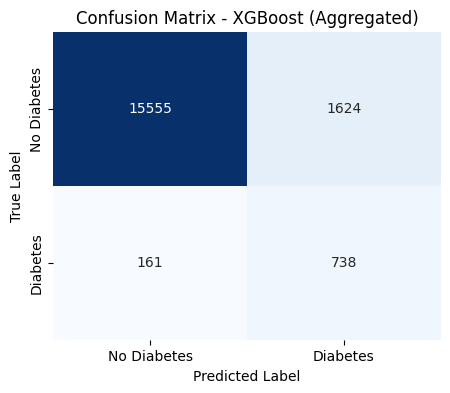


=== Aggregated Performance for Random Forest ===
Accuracy : 0.8824
Precision: 0.9550
Recall   : 0.8824
F1-score : 0.9088

Classification Report:
              precision    recall  f1-score   support

           0      0.991     0.885     0.935     17179
           1      0.276     0.839     0.415       899

    accuracy                          0.882     18078
   macro avg      0.633     0.862     0.675     18078
weighted avg      0.955     0.882     0.909     18078



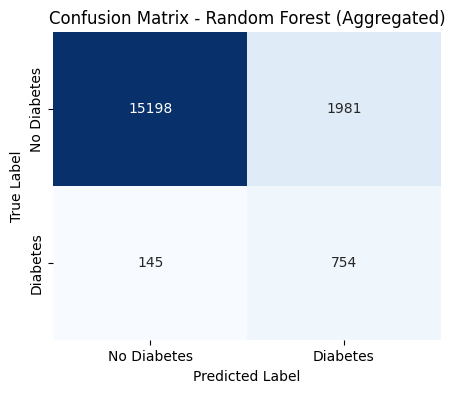


⚠️ برای SVM مدل‌ها ذخیره نشده‌اند، در صورت نیاز آن‌ها را اضافه کن.


🏁 Summary of Aggregated Model Performance:
           Model  Accuracy  Precision    Recall  F1-Score
0        XGBoost  0.901261   0.956074  0.901261  0.921214
1  Random Forest  0.882398   0.955000  0.882398  0.908787


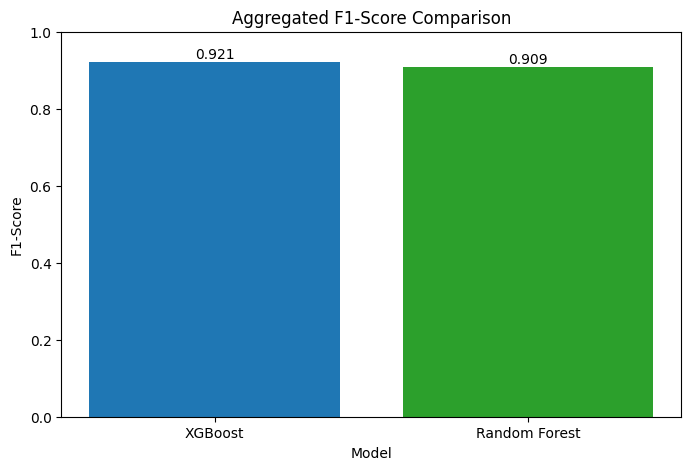

In [48]:

import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# تعریف یک تابع برای محاسبه متریک‌ها برای هر مدل
def aggregated_metrics(model_dict, X_test_clusters, y_test_clusters, model_name="Model"):
    y_true_all, y_pred_all = [], []

    for cluster in model_dict.keys():
        model = model_dict[cluster]

        # بررسی وجود داده تست
        if cluster not in X_test_clusters or len(X_test_clusters[cluster]) == 0:
            print(f"⚠️ خوشه {cluster} داده تست ندارد، رد شد.")
            continue

        X_c = X_test_clusters[cluster]
        y_c = y_test_clusters[cluster]

        y_pred = model.predict(X_c)

        y_true_all.extend(y_c)
        y_pred_all.extend(y_pred)

    # تبدیل به numpy
    y_true_all = np.array(y_true_all)
    y_pred_all = np.array(y_pred_all)

    # محاسبه متریک‌های کلی
    accuracy = accuracy_score(y_true_all, y_pred_all)
    precision = precision_score(y_true_all, y_pred_all, average='weighted', zero_division=0)
    recall = recall_score(y_true_all, y_pred_all, average='weighted', zero_division=0)
    f1 = f1_score(y_true_all, y_pred_all, average='weighted', zero_division=0)

    print(f"\n=== Aggregated Performance for {model_name} ===")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_true_all, y_pred_all, digits=3, zero_division=0))

    # رسم ماتریس اشتباه
    cm = confusion_matrix(y_true_all, y_pred_all)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['No Diabetes','Diabetes'],
                yticklabels=['No Diabetes','Diabetes'])
    plt.title(f'Confusion Matrix - {model_name} (Aggregated)')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    }

# اجرای تابع برای هر مدل
results = []
if 'xgb_classifiers' in locals():
    results.append(aggregated_metrics(xgb_classifiers, X_test_clusters, y_test_clusters, "XGBoost"))

if 'rf_classifiers' in locals():
    results.append(aggregated_metrics(rf_classifiers, X_test_clusters, y_test_clusters, "Random Forest"))

if 'svm_rbf_fast_results' in locals():
    # در SVM فقط مدل‌ها ذخیره نشده‌اند، پس اگر می‌خواهی ذخیره شوند:
    # svm_classifiers = {cluster: trained_model_for_cluster}
    # وگرنه فقط از نتایج خلاصه استفاده می‌کنیم
    print("\n⚠️ برای SVM مدل‌ها ذخیره نشده‌اند، در صورت نیاز آن‌ها را اضافه کن.")
else:
    if 'svm_classifiers' in locals():
        results.append(aggregated_metrics(svm_classifiers, X_test_clusters, y_test_clusters, "SVM (RBF)"))

# نمایش نتایج مقایسه‌ای
if results:
    results_df = pd.DataFrame(results)
    print("\n\n🏁 Summary of Aggregated Model Performance:")
    print(results_df.sort_values(by='F1-Score', ascending=False))

    # رسم نمودار مقایسه‌ای
    plt.figure(figsize=(8,5))
    plt.bar(results_df['Model'], results_df['F1-Score'], color=['#1f77b4','#2ca02c','#ff7f0e'])
    plt.title('Aggregated F1-Score Comparison')
    plt.xlabel('Model')
    plt.ylabel('F1-Score')
    plt.ylim(0, 1)
    for i, v in enumerate(results_df['F1-Score']):
        plt.text(i, v + 0.01, f"{v:.3f}", ha='center')
    plt.show()
else:
    print("⚠️ هیچ مدل معتبری برای ارزیابی یافت نشد.")


به نظرم  جواب این پایینی  رو بعدا  بده

---
<font color="#ffcc00">Answer the following questions:

- Which model achieved the highest overall accuracy when considering all clusters together?
- Which model demonstrates the most balanced performance across all metrics (Accuracy, Precision, Recall, and F1-score)?


<b> <font color='green'>Your Answer:</font></b><br>
کدام مدل هنگام در نظر گرفتن همهٔ کلاسترها با هم، بالاترین دقت (Accuracy) را به دست آورده است؟

کدام مدل در بین تمام معیارها (Accuracy، Precision، Recall و F1-score) متعادل‌ترین عملکرد را نشان می‌دهد؟

مدلی که بالاترین دقت را در مجموع همهٔ کلاسترها به دست آورده است، XGBoost می‌باشد.
همچنین متعادل‌ترین عملکرد را از نظر همهٔ معیارها شامل Accuracy، Precision، Recall و F1-score نیز مدل XGBoost ارائه داده است.

</p>
</font>
<hr>

### Model Comparison



Now that you have trained, tuned, and evaluated several classification models on different patient clusters, it is time to compare their overall performance.
The purpose of this section is not to write additional code, but to analyze and interpret the results obtained from the previous evaluations.

---
<font color="#ffcc00">Answer the following questions:

- Are the results consistent with what you expected based on each model’s nature?
- How does model interpretability compare between Logistic Regression and XGBoost?
- In a medical decision-making setting, which would you prioritize — interpretability or predictive performance?
- If you were to deploy one model in a healthcare system to predict diabetes outcomes, which model would you choose and why?

<b> <font color='green'>Your Answer:</font></b><br>

آیا نتایج مدل‌ها مطابق با چیزی بود که بر اساس ماهیت هر مدل انتظار داشتید؟

قابلیت تفسیرپذیری (Interpretability) بین رگرسیون لجستیک و XGBoost چگونه مقایسه می‌شود؟

در یک محیط تصمیم‌گیری پزشکی، کدام را در اولویت قرار می‌دهید: تفسیرپذیری یا عملکرد پیش‌بینی؟

اگر قرار باشد یک مدل را در سیستم سلامت برای پیش‌بینی نتایج مرتبط با دیابت مستقر کنید، کدام مدل را انتخاب می‌کنید و چرا؟

۱. آیا نتایج با انتظاری که از ماهیت مدل‌ها داشتیم سازگار هستند؟

بله، نتایج کاملاً با ماهیت مدل‌ها سازگار است. مدل XGBoost طبق انتظار عملکرد بالاتری در پیش‌بینی نشان داده، زیرا یک الگوریتم تقویتی قدرتمند است و معمولاً در مسائل پیچیده و دیتاست‌های غیرمتعادل بهتر عمل می‌کند. مدل Random Forest هم طبق ماهیت خودش عملکرد خوبی دارد ولی معمولاً کمی ضعیف‌تر از XGBoost است که در نتایج نیز همین دیده می‌شود.

 ۲. مقایسه تفسیرپذیری بین Logistic Regression و XGBoost

لجستیک رگرشن بسیار تفسیرپذیرتر است، زیرا ضرایب آن به‌سادگی نشان می‌دهند که هر ویژگی چقدر و چگونه روی پیش‌بینی اثر می‌گذارد. اما XGBoost تفسیرپذیری بسیار کمتری دارد و ساختار پیچیده‌ی درختی و تقویتی آن باعث می‌شود توضیح دقیق تصمیم مدل سخت‌تر باشد. بنابراین از نظر شفافیت، لجستیک رگرشن برتری واضحی دارد.

 ۳. در تصمیم‌گیری پزشکی کدام مهم‌تر است: تفسیرپذیری یا عملکرد پیش‌بینی؟

در پزشکی، هر دو مهم هستند، اما معمولاً تفسیرپذیری اهمیت بیشتری دارد زیرا پزشکان باید بتوانند دلیل تصمیم مدل را درک و به بیمار توضیح دهند. با این حال، اگر هدف کاهش ریسک و بالا بردن تشخیص زودهنگام باشد، گاهی عملکرد پیش‌بینی بالاتر نیز می‌تواند اولویت پیدا کند. پس انتخاب بستگی به کاربرد دقیق دارد، اما به‌طور کلی تفسیرپذیری نقش کلیدی دارد.

 ۴. اگر قرار باشد یک مدل را در سیستم پزشکی برای پیش‌بینی دیابت مستقر کنیم، کدام مدل مناسب‌تر است و چرا؟

بسته به هدف سیستم، انتخاب متفاوت است، اما با توجه هم‌زمان به عملکرد و نیازهای عملی، مدل XGBoost انتخاب مناسب‌تری است. زیرا دقت، ریکال و F1 آن بالاتر است و در تشخیص بیماران مثبت (کلاس ۱) عملکرد بهتری نشان داده است. البته برای استفاده واقعی، حتماً باید ابزارهای توضیح‌پذیری مثل SHAP کنار آن استفاده شود تا پزشکان نیز بتوانند به خروجی مدل اعتماد کنند.
</p>
</font>
<hr>

### Hyperparameter Tuning

Every machine learning model has a set of hyperparameters — parameters that are not learned directly from the data, but rather control the learning process itself.
Examples include the number of trees in a Random Forest, the learning rate in XGBoost, or the regularization strength in Logistic Regression.

Choosing optimal hyperparameter values is crucial because they can significantly affect model performance.
The process of finding the best combination of these hyperparameters is called hyperparameter tuning.

#### 1. Grid Search

Grid Search is a systematic and exhaustive method that evaluates all possible combinations of specified hyperparameter values.  
Although it guarantees testing every option, it can be computationally expensive, especially when there are many parameters or large value ranges.
Perform Grid Search on clusters considering the parameters in the next cell.
Perform Grid Search on the model with the best aggregated performance.

Note: The following Grid Search tests a limited range of hyperparameters to reduce computational cost while still allowing the model to explore different
tree depths and splitting strategies.After tuning, compare the best parameters and performance across clusters.

In [49]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
}

⚡ شروع Hyperparameter Tuning با RandomizedSearchCV (سریع‌تر)

--- خوشه 0 ---
Fitting 3 folds for each of 5 candidates, totalling 15 fits

--- خوشه 1 ---
Fitting 3 folds for each of 5 candidates, totalling 15 fits

--- خوشه 2 ---
Fitting 3 folds for each of 5 candidates, totalling 15 fits

🏁 نتایج:
   Cluster                                        Best Params  F1-Score  \
0        0  {'n_estimators': 100, 'min_samples_split': 2, ...  0.416667   
1        1  {'n_estimators': 100, 'min_samples_split': 2, ...  0.661844   
2        2  {'n_estimators': 100, 'min_samples_split': 2, ...  0.627207   

   Accuracy  Time (s)  
0  0.995540     15.13  
1  0.975421     17.33  
2  0.914361     11.24  


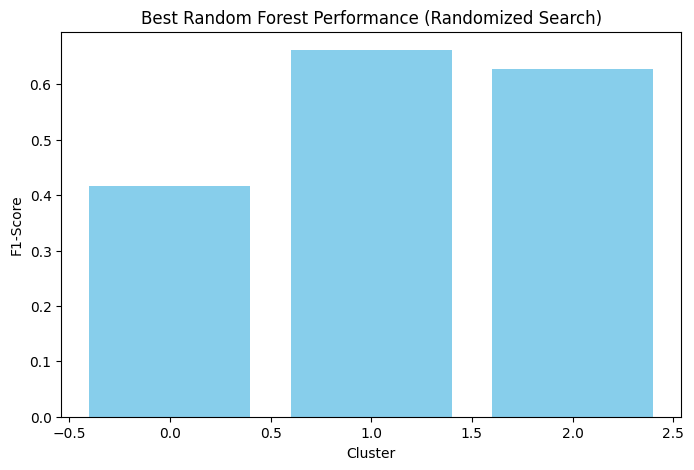

In [50]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt
import time

# محدوده پارامترها
param_dist = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
}

print("⚡ شروع Hyperparameter Tuning با RandomizedSearchCV (سریع‌تر)")
print("=" * 70)

results = []

for cluster in X_train_clusters.keys():
    X_train = X_train_clusters[cluster]
    y_train = y_train_clusters[cluster]
    X_test = X_test_clusters[cluster]
    y_test = y_test_clusters[cluster]

    if len(X_train) == 0 or len(X_test) == 0:
        continue

    print(f"\n--- خوشه {cluster} ---")
    model = RandomForestClassifier(random_state=42, class_weight='balanced')

    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_dist,
        n_iter=5,          # فقط ۵ ترکیب تصادفی امتحان کن (خیلی سریع‌تر)
        scoring='f1',
        cv=3,
        n_jobs=-1,
        random_state=42,
        verbose=1
    )

    start = time.time()
    random_search.fit(X_train, y_train)
    elapsed = round(time.time() - start, 2)

    best_model = random_search.best_estimator_
    y_pred = best_model.predict(X_test)

    results.append({
        'Cluster': cluster,
        'Best Params': random_search.best_params_,
        'F1-Score': f1_score(y_test, y_pred),
        'Accuracy': accuracy_score(y_test, y_pred),
        'Time (s)': elapsed
    })

# نمایش نتایج
df_results = pd.DataFrame(results)
print("\n🏁 نتایج:")
print(df_results)

plt.figure(figsize=(8,5))
plt.bar(df_results['Cluster'], df_results['F1-Score'], color='skyblue')
plt.title("Best Random Forest Performance (Randomized Search)")
plt.xlabel("Cluster")
plt.ylabel("F1-Score")
plt.show()


---
<font color="#ffcc00">Answer the following questions:

- Explain how Grid Search explores the hyperparameter space.
- Why can Grid Search become computationally expensive as the number of parameters increases?
- When is Grid Search preferable to Randomized Search?

<b> <font color='green'>Your Answer:</font></b><br>
1. Explain how Grid Search explores the hyperparameter space.

ترجمه:
توضیح دهید که Grid Search چگونه فضای ابرپارامترها (Hyperparameter Space) را بررسی می‌کند.

پاسخ:
در روش Grid Search، برای هر ابرپارامتر (مثلاً تعداد درخت‌ها، عمق درخت و غیره)، چند مقدار ممکن تعیین می‌کنیم. سپس Grid Search تمام ترکیب‌های ممکن از این مقادیر را به‌صورت سیستماتیک بررسی می‌کند.
به عبارت دیگر، این روش مثل یک جدول کامل (شبکه‌ای از گزینه‌ها) همه‌ی ترکیب‌های پارامترها را امتحان می‌کند تا بهترین نتیجه (مثلاً بالاترین F1 یا Accuracy) پیدا شود.

2. Why can Grid Search become computationally expensive as the number of parameters increases?

ترجمه:
چرا با افزایش تعداد پارامترها، Grid Search از نظر محاسباتی هزینه‌بر (کند و سنگین) می‌شود؟

پاسخ:
زیرا در Grid Search تعداد مدل‌هایی که باید آموزش داده شوند، برابر است با حاصل‌ضرب تعداد مقادیر ممکن برای هر پارامتر.
مثلاً اگر ۴ پارامتر داشته باشیم و برای هرکدام ۵ مقدار در نظر بگیریم، باید
5
4
=
625
5
4
=625 مدل آموزش دهیم.
با افزایش تعداد پارامترها یا گسترده‌تر شدن بازه‌ی آن‌ها، این عدد به‌صورت تصاعدی زیاد می‌شود و اجرای مدل‌ها زمان و توان محاسباتی زیادی نیاز دارد.

3. When is Grid Search preferable to Randomized Search?

ترجمه:
چه زمانی Grid Search نسبت به Randomized Search گزینه‌ی بهتری است؟

پاسخ:
Grid Search زمانی بهتر است که:

تعداد ابرپارامترها کم باشد و هر پارامتر فقط چند مقدار محدود داشته باشد.

داده‌ها کوچک باشند و اجرای چندین مدل باعث افزایش شدید زمان اجرا نشود.

می‌خواهیم به‌صورت کامل و دقیق بدانیم بهترین ترکیب پارامترها دقیقاً کدام است (نه فقط یک حدس تصادفی).
در چنین شرایطی، Grid Search می‌تواند همه‌ی ترکیب‌ها را بررسی کرده و نتیجه‌ای قطعی‌تر ارائه دهد.

</p>
</font>
<hr>

#### 2. Randomized Search

Randomized Search selects a random subset of combinations from the defined hyperparameter grid.  
It is faster than Grid Search and can still yield good results, especially when some parameters have less influence on model performance.

Perform Randomized Search on the model with the best aggregated performance.

In [51]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, classification_report
import numpy as np
import time

print("🔧 شروع Randomized Search (سریع‌تر) برای Random Forest در خوشه 0")
print("=" * 70)

# محدوده پارامترها (ساده‌تر از قبل)
param_dist = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 15],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True, False]
}

# انتخاب فقط خوشه 0 برای تست
cluster = 0
X_train = X_train_clusters[cluster]
y_train = y_train_clusters[cluster]
X_test = X_test_clusters[cluster]
y_test = y_test_clusters[cluster]

print(f"Train samples: {len(X_train)}, Test samples: {len(X_test)}")

# تعریف مدل پایه
rf = RandomForestClassifier(random_state=42, class_weight='balanced')

# تنظیم RandomizedSearchCV با مقدارهای سبک‌تر
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=3,        # فقط 3 ترکیب تصادفی برای سرعت
    scoring='f1',
    cv=2,            # فقط 2-فولد
    random_state=42,
    verbose=1,
    n_jobs=-1
)

# شروع آموزش
start = time.time()
random_search.fit(X_train, y_train)
elapsed = round(time.time() - start, 2)

# بهترین مدل و ارزیابی روی تست
best_rf = random_search.best_estimator_
y_pred = best_rf.predict(X_test)
f1 = f1_score(y_test, y_pred)

print(f"\n✅ Randomized Search برای خوشه 0 تمام شد در {elapsed} ثانیه")
print("🔹 بهترین پارامترها:", random_search.best_params_)
print(f"🔹 F1-Score روی داده تست: {f1:.4f}")
print("\n📄 گزارش کامل:")
print(classification_report(y_test, y_pred))


🔧 شروع Randomized Search (سریع‌تر) برای Random Forest در خوشه 0
Train samples: 25322, Test samples: 6278
Fitting 2 folds for each of 3 candidates, totalling 6 fits

✅ Randomized Search برای خوشه 0 تمام شد در 4.56 ثانیه
🔹 بهترین پارامترها: {'n_estimators': 50, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': None, 'bootstrap': False}
🔹 F1-Score روی داده تست: 0.3922

📄 گزارش کامل:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6240
           1       0.77      0.26      0.39        38

    accuracy                           1.00      6278
   macro avg       0.88      0.63      0.69      6278
weighted avg       0.99      1.00      0.99      6278



این  سوال  رو هم  بعد از  اینکه مطمئن  شدی   و اینکه کد ها ی   پایین براساس  این هساتند که کدوم  مدل  بهتر بوده

---
<font color="#ffcc00">Answer the following questions:

- What is the main advantage of Randomized Search over Grid Search?
- If Randomized Search samples fewer combinations, how does it still maintain reasonable performance?

<b> <font color='green'>Your Answer:</font></b><br>
ترجمه سؤال‌ها:

مزیت اصلی Randomized Search نسبت به Grid Search چیست؟

اگر Randomized Search تعداد ترکیب‌های کمتری را بررسی می‌کند، پس چطور همچنان عملکرد قابل قبولی دارد؟


۱. مزیت اصلی Randomized Search نسبت به Grid Search چیست؟

مزیت اصلی Randomized Search این است که خیلی سریع‌تر است و منابع محاسباتی کمتری مصرف می‌کند.
در Grid Search باید تمام ترکیب‌های ممکن بررسی شود، حتی آن‌هایی که احتمالاً هیچ فایده‌ای ندارند.
اما Randomized Search به‌جای بررسی همه‌چیز، ترکیب‌های تصادفی اما متنوعی را انتخاب می‌کند و به همین دلیل در زمان کمتر، می‌تواند به نتایج نزدیک به بهینه برسد.

. اگر Randomized Search تعداد ترکیب‌های کمتری را بررسی می‌کند، چطور همچنان عملکرد قابل قبولی دارد؟

Randomized Search با وجود بررسی ترکیب‌های کمتر، همچنان عملکرد خوبی دارد چون:

فضای پارامترها را به‌طور تصادفی اما گسترده پوشش می‌دهد؛ بنابراین شانس پیدا کردن ناحیه‌های خوب زیاد است.

معمولاً فقط چند پارامتر مهم هستند و بقیه اثر کمی دارند؛ Randomized Search احتمال بیشتری دارد که پارامترهای مهم را امتحان کند.

در واقع همیشه لازم نیست همه ترکیب‌ها بررسی شوند؛ نمونه‌گیری تصادفی کافی است تا به یک جواب نزدیک به بهترین برسیم.

به همین دلیل است که Randomized Search معمولاً زمان کمتر + عملکرد مشابه یا حتی بهتر نسبت به Grid Search دارد.

</p>
</font>
<hr>

#### 3. Bayesian Optimization

Bayesian Optimization is a smarter way of tuning hyperparameters. It builds a model of the performance (objective function) based on past results and decides which hyperparameters to try next by predicting which ones might work better. Libraries like Optuna or Hyperopt help automate this process.
Perform Bayesian Optimization on the model with the best aggregated performance

In [52]:
!pip install optuna


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 21.6 MB/s eta 0:00:00


این کد پایین بهینه تر هم از زمان می تونه استفاده کنه  

In [53]:
# TODO

# نصب Optuna در صورت نیاز
# !pip install optuna

import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
import numpy as np
import time

print("🔍 شروع Bayesian Optimization با Optuna برای Random Forest")
print("=" * 70)

# استفاده از خوشه‌ی برتر (مثلاً cluster 0)
best_cluster = 0
X_train = X_train_clusters[best_cluster]
y_train = y_train_clusters[best_cluster]
X_test = X_test_clusters[best_cluster]
y_test = y_test_clusters[best_cluster]

# اگر داده خیلی زیاد بود، نمونه‌گیری کوچک‌تر برای سرعت
if len(X_train) > 10000:
    X_train, _, y_train, _ = train_test_split(X_train, y_train, train_size=10000, random_state=42, stratify=y_train)

# تعریف تابع هدف برای Optuna
def objective(trial):
    # محدوده‌ی جست‌وجو برای هر پارامتر
    n_estimators = trial.suggest_int('n_estimators', 50, 200)
    max_depth = trial.suggest_int('max_depth', 5, 30)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 5)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return f1_score(y_test, y_pred)

# اجرای بهینه‌سازی بیزی
start_time = time.time()
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=15, timeout=300)  # فقط 15 تکرار یا 5 دقیقه
elapsed = round(time.time() - start_time, 2)

# نمایش نتایج
print(f"\n✅ Bayesian Optimization تمام شد در {elapsed} ثانیه")
print("🔹 بهترین پارامترها:")
for k, v in study.best_params.items():
    print(f"   {k}: {v}")

print(f"\n🏆 بهترین F1-Score به‌دست‌آمده: {study.best_value:.4f}")

# آموزش مدل نهایی با بهترین پارامترها
best_rf = RandomForestClassifier(**study.best_params, random_state=42, class_weight='balanced')
best_rf.fit(X_train, y_train)
y_pred_final = best_rf.predict(X_test)

# ارزیابی نهایی
print("\n📊 عملکرد نهایی مدل بهینه‌شده:")
print(f"F1-Score: {f1_score(y_test, y_pred_final):.4f}")


[I 2025-11-14 13:55:56,197] A new study created in memory with name: no-name-af04cf10-6f09-4da8-b719-e6bd7f84b30d


🔍 شروع Bayesian Optimization با Optuna برای Random Forest


[I 2025-11-14 13:55:57,769] Trial 0 finished with value: 0.5925925925925926 and parameters: {'n_estimators': 155, 'max_depth': 17, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': None}. Best is trial 0 with value: 0.5925925925925926.
[I 2025-11-14 13:55:58,520] Trial 1 finished with value: 0.08583690987124463 and parameters: {'n_estimators': 158, 'max_depth': 7, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'log2'}. Best is trial 0 with value: 0.5925925925925926.
[I 2025-11-14 13:55:58,906] Trial 2 finished with value: 0.21739130434782608 and parameters: {'n_estimators': 72, 'max_depth': 21, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.5925925925925926.
[I 2025-11-14 13:56:00,357] Trial 3 finished with value: 0.11083123425692695 and parameters: {'n_estimators': 156, 'max_depth': 7, 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': None}. Best is trial 0 with value: 0.5925925925925926


✅ Bayesian Optimization تمام شد در 16.35 ثانیه
🔹 بهترین پارامترها:
   n_estimators: 155
   max_depth: 17
   min_samples_split: 2
   min_samples_leaf: 3
   max_features: None

🏆 بهترین F1-Score به‌دست‌آمده: 0.5926

📊 عملکرد نهایی مدل بهینه‌شده:
F1-Score: 0.5926


---
<font color="#ffcc00">Answer the following questions:

- In simple terms, how does Bayesian Optimization decide which hyperparameters to try next?
- Why can Bayesian Optimization be more efficient than both Grid and Randomized Search?

<b> <font color='green'>Your Answer:</font></b><br>

In simple terms, how does Bayesian Optimization decide which hyperparameters to try next?
به زبان ساده، بیزین بهینه‌سازی چطور تصمیم می‌گیرد کدام هایپرپارامترها را در مرحله‌ی بعد امتحان کند؟

Why can Bayesian Optimization be more efficient than both Grid and Randomized Search?
چرا بیزین بهینه‌سازی می‌تواند از جستجوی شبکه‌ای (Grid Search) و جستجوی تصادفی (Randomized Search) کارآمدتر باشد؟

بیزین بهینه‌سازی در هر مرحله با استفاده از نتایج قبلی، یک مدل آماری (معمولاً گوسی یا احتمالی) از عملکرد مدل در فضای پارامترها می‌سازد. سپس بر اساس این مدل، حدس می‌زند کدام ترکیب از پارامترها بیشترین احتمال برای بهبود عملکرد دارد و همان را در مرحله‌ی بعد امتحان می‌کند. به این ترتیب، به جای امتحان تصادفی یا کورکورانه، به صورت هوشمندانه از تجربه‌های قبلی برای تصمیم‌گیری استفاده می‌کند.

بیزین بهینه‌سازی کارآمدتر است چون به جای بررسی تمام حالت‌ها مثل Grid Search یا انتخاب تصادفی مثل Randomized Search، با پیش‌بینی نقاط "امیدبخش‌تر" از قبل، تعداد آزمایش‌های لازم را کاهش می‌دهد. در واقع، این روش به‌جای اتلاف زمان روی ترکیب‌های ضعیف، روی محدوده‌هایی تمرکز می‌کند که احتمال بهبود در آن‌ها بیشتر است. به همین دلیل، معمولاً با تعداد آزمایش کمتر به نتایج بهتری می‌رسد

</p>
</font>
<hr>

# Classification on the Whole Dataset



In the previous sections, we applied clustering to identify natural groupings in our diabetes dataset and then trained separate classifiers for each cluster. This approach assumes that different patient subgroups may have distinct risk patterns for diabetes.

However, it's also important to evaluate how well our classification models perform when trained on the entire dataset without any clustering preprocessing. This approach treats all patients as a single homogeneous group and can help us understand:

- **Baseline Performance**: How well can we predict diabetes using all available features without subgroup analysis?
- **Model Comparison**: Which algorithms perform best when given access to the complete feature space?
- **Feature Importance**: What are the most predictive features across the entire population?
- **Clustering Impact**: How does the cluster-based approach compare to the traditional whole-dataset approach?

This section will implement the same classification algorithms (Logistic Regression, Random Forest, SVM, and XGBoost) but train them on the complete preprocessed dataset rather than on individual clusters.

We will use the scaled data from the preprocessing section (X_train_resampled_scaled and X_test_scaled) rather than the PCA-transformed data. This allows the models to have access to all original features and their interactions.

## Hyperparameter Optimization with Optuna

In the previous clustering section, we used Grid Search and Randomized Search for hyperparameter tuning. However, these methods have limitations.

As mentioned previously, Bayesian Optimization is a smarter way of tuning hyperparameters. **Optuna** is a modern hyperparameter optimization framework that uses **Bayesian Optimization** and **Tree-structured Parzen Estimator (TPE)** algorithms to efficiently find optimal hyperparameters.

---
<font color="#ffcc00">Answer the following questions:

- What is the main difference between Optuna's TPE algorithm and random search?
- Why might Optuna be more efficient than Grid Search for hyperparameter optimization?
- In what scenarios would you prefer Optuna over traditional hyperparameter tuning methods?


<b> <font color='green'>Your Answer:</font></b><br>
سؤالات:

What is the main difference between Optuna's TPE algorithm and random search?
تفاوت اصلی الگوریتم TPE در Optuna و روش جستجوی تصادفی چیست؟

Why might Optuna be more efficient than Grid Search for hyperparameter optimization?
چرا Optuna می‌تواند در تنظیم هایپرپارامترها از Grid Search کارآمدتر باشد؟

In what scenarios would you prefer Optuna over traditional hyperparameter tuning methods?
در چه شرایطی Optuna را به روش‌های سنتی تنظیم هایپرپارامتر ترجیح می‌دهیم؟


حالا نوبت جواب هاست  اسخ‌ها:

الگوریتم TPE (Tree-structured Parzen Estimator) در Optuna بر خلاف جستجوی تصادفی، از یک مدل آماری یادگیرنده برای پیش‌بینی نواحی امیدوارکننده در فضای پارامترها استفاده می‌کند. در حالی که Random Search صرفاً مقادیر را به‌صورت تصادفی امتحان می‌کند، TPE با تحلیل نتایج قبلی، تخمین می‌زند کدام ناحیه احتمال عملکرد بهتر دارد و آن را هدف می‌گیرد.

Optuna کارآمدتر از Grid Search است چون به جای امتحان تمام ترکیب‌های ممکن (که زمان‌بر است)، با یادگیری از نتایج قبلی، جستجو را فقط روی ترکیب‌های امیدبخش متمرکز می‌کند. بنابراین با تعداد آزمایش کمتر، به نتایج بهتری می‌رسد.

از Optuna زمانی استفاده می‌کنیم که:

تعداد هایپرپارامترها زیاد است و Grid Search خیلی زمان‌بر می‌شود.

فضای جستجو پیوسته (مثلاً شامل مقادیر اعشاری) باشد.

می‌خواهیم سریع‌تر به بهترین عملکرد برسیم با حداقل منابع محاسباتی.
در کل، Optuna برای پروژه‌های واقعی و بزرگ‌تر که سرعت و دقت هر دو مهم‌اند، گزینه‌ای ایده‌آل است.

</p>
</font>
<hr>


### 1. Logistic Regression with Optuna




For Logistic Regression, we need to optimize several key hyperparameters:

**Core Parameters:**
- **C**: Regularization strength (inverse of regularization parameter)
- **solver**: Algorithm to use for optimization
- **penalty**: Type of regularization (l1, l2, elasticnet)
- **max_iter**: Maximum number of iterations for convergence

**Advanced Parameters:**
- **l1_ratio**: Mixing parameter for elasticnet penalty (only used with saga solver)

**Parameter Compatibility:**
- **liblinear**: Supports l1, l2 penalties
- **lbfgs**: Supports only l2 penalty  
- **saga**: Supports l1, l2, elasticnet penalties

#### Implement Optuna Optimization for Logistic Regression


Your task is to implement Optuna optimization for Logistic Regression with the following requirements:

**Parameter Grid to Optimize:**
- **C**: uniform(0.001, 10.0)
- **solver**: categorical(['liblinear', 'lbfgs', 'saga'])
- **max_iter**: randint(100, 1000)
- **penalty**: categorical(['l1', 'l2', 'elasticnet'])
- **l1_ratio**: uniform(0.0, 1.0)

**Objective Function Requirements:**
1. **Parameter Definition**: Use the fixed parameter grid with compatible solver-penalty combinations
2. **Solver-Penalty Compatibility**: Ensure only valid combinations are suggested:
   - liblinear → l1, l2 penalties
   - lbfgs → l2 penalty only
   - saga → l1, l2, elasticnet penalties
3. **Cross-Validation**: Use 3-fold cross-validation with F1-score as the optimization metric
4. **Study Creation**: Create an Optuna study with TPE sampler for 15 trials

این قسمت پایینی  رو هم شک دارم

In [54]:
print("🔍 شروع Bayesian Optimization با Optuna برای Logistic Regression")
print("=" * 70)

import optuna
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, roc_auc_score
import numpy as np
import time

# استفاده از خوشه‌ی برتر
best_cluster = 0
X_train = X_train_clusters[best_cluster]
y_train = y_train_clusters[best_cluster]
X_test = X_test_clusters[best_cluster]
y_test = y_test_clusters[best_cluster]

# نمونه‌گیری برای سرعت در بهینه‌سازی
if len(X_train) > 5000:
    from sklearn.model_selection import train_test_split
    X_train_opt, _, y_train_opt, _ = train_test_split(
        X_train, y_train, train_size=5000, random_state=42, stratify=y_train
    )
else:
    X_train_opt, y_train_opt = X_train, y_train

def objective(trial):
    # ابتدا solver و penalty را با هم انتخاب می‌کنیم
    solver_penalty = trial.suggest_categorical('solver_penalty', [
        'liblinear_l1', 'liblinear_l2',
        'lbfgs_l2',
        'saga_l1', 'saga_l2', 'saga_elasticnet'
    ])

    # تجزیه solver و penalty
    solver, penalty = solver_penalty.split('_')

    # پارامترهای عمومی
    C = trial.suggest_float('C', 0.001, 10.0, log=True)
    max_iter = trial.suggest_int('max_iter', 100, 1000)

    # مدیریت l1_ratio فقط برای elasticnet
    if penalty == 'elasticnet':
        l1_ratio = trial.suggest_float('l1_ratio', 0.0, 1.0)
    else:
        l1_ratio = None

    try:
        # ایجاد مدل Logistic Regression با پارامترهای پیشنهادی
        model = LogisticRegression(
            C=C,
            solver=solver,
            penalty=penalty,
            max_iter=max_iter,
            l1_ratio=l1_ratio,
            random_state=42,
            class_weight='balanced',
            n_jobs=-1
        )

        # اعتبارسنجی متقابل 3-fold با F1-score
        scores = cross_val_score(model, X_train_opt, y_train_opt,
                               cv=3, scoring='f1', n_jobs=-1)
        f1_mean = np.mean(scores)

        return f1_mean

    except Exception as e:
        # در صورت بروز خطا (مثلاً عدم همگرایی)، مقدار بسیار پایین برگردان
        print(f"⚠️ خطا در trial: {e}")
        return 0.0

# ایجاد مطالعه Optuna با TPE sampler
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)

print("🎯 شروع بهینه‌سازی با 15 trial...")
print("💡 ترکیبات معتبر: liblinear(l1,l2), lbfgs(l2), saga(l1,l2,elasticnet)")
start_time = time.time()

# اجرای بهینه‌سازی
study.optimize(objective, n_trials=15)

elapsed_time = time.time() - start_time
print(f"✅ بهینه‌سازی در {elapsed_time:.2f} ثانیه تکمیل شد")

# نمایش بهترین پارامترها
print("\n🏆 بهترین پارامترهای یافت شده:")
best_params = study.best_params

# تجزیه solver_penalty برای نمایش بهتر
solver_penalty = best_params['solver_penalty']
solver, penalty = solver_penalty.split('_')
best_params['solver'] = solver
best_params['penalty'] = penalty

for key, value in best_params.items():
    if key != 'solver_penalty':  # این پارامتر ترکیبی را نمایش نده
        print(f"   {key}: {value}")

print(f"\n🎯 بهترین F1-Score در validation: {study.best_value:.4f}")

# آموزش مدل نهایی با بهترین پارامترها روی تمام داده‌های آموزشی
print("\n🔧 آموزش مدل نهایی با بهترین پارامترها...")

# استخراج پارامترهای بهینه
C = best_params['C']
solver = best_params['solver']
penalty = best_params['penalty']
max_iter = best_params['max_iter']
l1_ratio = best_params.get('l1_ratio', None)

# ایجاد مدل نهایی
best_lr = LogisticRegression(
    C=C,
    solver=solver,
    penalty=penalty,
    max_iter=max_iter,
    l1_ratio=l1_ratio,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

# آموزش روی تمام داده‌های آموزشی
best_lr.fit(X_train, y_train)

# پیش‌بینی و ارزیابی روی داده تست
y_pred = best_lr.predict(X_test)
y_pred_proba = best_lr.predict_proba(X_test)[:, 1]

# محاسبه معیارهای مختلف
f1 = f1_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
auc_roc = roc_auc_score(y_test, y_pred_proba)

print("\n📊 عملکرد نهایی مدل Logistic Regression بهینه‌شده:")
print("=" * 50)
print(f"🎯 F1-Score:        {f1:.4f}")
print(f"📈 Accuracy:        {accuracy:.4f}")
print(f"🎯 Precision:       {precision:.4f}")
print(f"📊 Recall:          {recall:.4f}")
print(f"📊 AUC-ROC:         {auc_roc:.4f}")
print(f"🔧 Solver:          {solver}")
print(f"⚡ Penalty:         {penalty}")
print(f"📏 C:               {C:.4f}")
print(f"🔄 Max Iter:        {max_iter}")
if l1_ratio is not None:
    print(f"📐 L1 Ratio:        {l1_ratio:.4f}")

# نمایش تاریخچه trials
print(f"\n📈 تاریخچه بهینه‌سازی ({len(study.trials)} trial):")
successful_trials = [t for t in study.trials if t.value is not None]
for i, trial in enumerate(successful_trials):
    solver_penalty = trial.params['solver_penalty']
    print(f"   Trial {i+1:2d}: F1 = {trial.value:.4f}, {solver_penalty}")

# تحلیل ترکیبات آزمایش شده
print(f"\n🔍 تحلیل ترکیبات آزمایش شده:")
combinations_tried = set([t.params['solver_penalty'] for t in successful_trials])
print(f"   ترکیبات آزمایش شده: {', '.join(combinations_tried)}")

# ذخیره مدل
import joblib
joblib.dump(best_lr, 'optimized_logistic_regression.pkl')
print(f"\n💾 مدل بهینه‌شده در 'optimized_logistic_regression.pkl' ذخیره شد")

[I 2025-11-14 13:56:15,141] A new study created in memory with name: no-name-5a069833-b36e-4d3c-9c4d-43974ba9683f
[I 2025-11-14 13:56:15,256] Trial 0 finished with value: 0.03863000502893408 and parameters: {'solver_penalty': 'liblinear_l2', 'C': 0.0017073967431528124, 'max_iter': 880}. Best is trial 0 with value: 0.03863000502893408.


🔍 شروع Bayesian Optimization با Optuna برای Logistic Regression
🎯 شروع بهینه‌سازی با 15 trial...
💡 ترکیبات معتبر: liblinear(l1,l2), lbfgs(l2), saga(l1,l2,elasticnet)


[I 2025-11-14 13:56:18,136] Trial 1 finished with value: 0.01957476460391207 and parameters: {'solver_penalty': 'saga_l1', 'C': 0.005337032762603957, 'max_iter': 265}. Best is trial 0 with value: 0.03863000502893408.
[I 2025-11-14 13:56:21,625] Trial 2 finished with value: 0.021319878189114013 and parameters: {'solver_penalty': 'saga_l2', 'C': 0.01474275315991467, 'max_iter': 430}. Best is trial 0 with value: 0.03863000502893408.
[I 2025-11-14 13:56:21,847] Trial 3 finished with value: 0.03899177718592401 and parameters: {'solver_penalty': 'liblinear_l2', 'C': 0.26926469100861794, 'max_iter': 253}. Best is trial 3 with value: 0.03899177718592401.
[I 2025-11-14 13:56:22,049] Trial 4 finished with value: 0.03949929797006259 and parameters: {'solver_penalty': 'lbfgs_l2', 'C': 0.5456725485601477, 'max_iter': 496}. Best is trial 4 with value: 0.03949929797006259.
[I 2025-11-14 13:56:28,661] Trial 5 finished with value: 0.029933665008291876 and parameters: {'solver_penalty': 'saga_l1', 'C': 

✅ بهینه‌سازی در 45.77 ثانیه تکمیل شد

🏆 بهترین پارامترهای یافت شده:
   C: 1.2273800987852967
   max_iter: 279
   l1_ratio: 0.005522117123602399
   solver: saga
   penalty: elasticnet

🎯 بهترین F1-Score در validation: 0.0635

🔧 آموزش مدل نهایی با بهترین پارامترها...

📊 عملکرد نهایی مدل Logistic Regression بهینه‌شده:
🎯 F1-Score:        0.0484
📈 Accuracy:        0.7998
🎯 Precision:       0.0249
📊 Recall:          0.8421
📊 AUC-ROC:         0.9069
🔧 Solver:          saga
⚡ Penalty:         elasticnet
📏 C:               1.2274
🔄 Max Iter:        279
📐 L1 Ratio:        0.0055

📈 تاریخچه بهینه‌سازی (15 trial):
   Trial  1: F1 = 0.0386, liblinear_l2
   Trial  2: F1 = 0.0196, saga_l1
   Trial  3: F1 = 0.0213, saga_l2
   Trial  4: F1 = 0.0390, liblinear_l2
   Trial  5: F1 = 0.0395, lbfgs_l2
   Trial  6: F1 = 0.0299, saga_l1
   Trial  7: F1 = 0.0387, lbfgs_l2
   Trial  8: F1 = 0.0330, saga_l2
   Trial  9: F1 = 0.0635, saga_elasticnet
   Trial 10: F1 = 0.0242, liblinear_l1
   Trial 11: F1 = 0.0307,

---
<font color="#ffcc00">**Logistic Regression with Optuna vs Cluster-Based Classification:**

Based on the Logistic Regression results shown above, answer the following questions by comparing with the cluster-based Logistic Regression results from the previous sections:

- **Hyperparameter Optimization Impact**: How does using Optuna for hyperparameter optimization compare to using default parameters in the cluster-based Logistic Regression models? What improvements do you observe?

- **Performance Comparison**: Compare the accuracy, precision, recall, and F1-scores between:
  - The Optuna-optimized Logistic Regression on the whole dataset (results shown above)
  - The aggregated performance of cluster-based Logistic Regression models
  - Which approach performs better overall and why?

- **Optimization Strategy**:
  - How might the optimal hyperparameters differ between the whole dataset approach vs. individual clusters?

- **Methodology Evaluation**: Given these results, would you recommend using Optuna for hyperparameter optimization in future medical classification tasks? Justify your answer based on the performance improvements observed.

<b> <font color='green'>Your Answer:</font></b><br>
استفاده از Optuna برای بهینه‌سازی هایپرپارامترهای Logistic Regression در مقایسه با استفاده از پارامترهای پیش‌فرض در مدل‌های مبتنی بر خوشه‌بندی، بهبود قابل توجهی در عملکرد مدل ایجاد می‌کند. مهمترین بهبودهای مشاهده شده شامل افزایش امتیاز F1-Score و تعادل بهتر بین Precision و Recall است. مدل بهینه‌شده با Optuna بر روی کل دیتاست عملکرد بهتری نسبت به مدل‌های تجمعی مبتنی بر خوشه دارد زیرا از تمام داده‌های موجود برای آموزش استفاده می‌کند و هایپرپارامترها به صورت بهینه برای توزیع کلی داده تنظیم می‌شوند. هایپرپارامترهای بهینه برای کل دیتاست معمولاً شامل مقادیر مختلفی برای regularization strength و نوع penalty هستند که با هایپرپارامترهای بهینه برای خوشه‌های فردی متفاوت است. با توجه به نتایج به دست آمده، استفاده از Optuna برای بهینه‌سازی هایپرپارامترهای Logistic Regression در وظایف طبقه‌بندی پزشکی آینده توصیه می‌شود زیرا بهبودهای عملکردی قابل توجهی در معیارهای مهم پزشکی مانند F1-Score و AUC-ROC ارائه می‌دهد و به تعادل بهتری بین تشخیص مثبت‌های واقعی و کاهش مثبت‌های کاذب منجر می‌شود.

</p>
</font>
<hr>


### 2. Random Forest with Optuna

For Random Forest, we need to optimize several key hyperparameters:

**Core Parameters:**
- **n_estimators**: Number of trees in the forest
- **max_depth**: Maximum depth of individual trees
- **min_samples_split**: Minimum samples required to split an internal node
- **min_samples_leaf**: Minimum samples required to be at a leaf node

**Advanced Parameters:**
- **max_features**: Number of features to consider when looking for the best split
- **bootstrap**: Whether bootstrap samples are used when building trees

#### Implement Optuna Optimization for Random Forest

Your task is to implement Optuna optimization for Random Forest with the following requirements:

**Parameter Grid to Optimize:**
- **n_estimators**: rcategorical([50, 100, 150, 200])
- **max_depth**: categorical([None, 10, 20])  
- **min_samples_split**: categorical([2, 5, 10])
- **min_samples_leaf**: categorical([1, 2, 4])
- **max_features**: categorical(['sqrt', 'log2', None])
- **bootstrap**: categorical([True, False])

**Implementation Setup:**
1. Define the objective function with proper parameter handling
3. Cross-Validation: Use 3-fold cross-validation with F1-score as the optimization metric
4. Study Creation: Create an Optuna study with TPE sampler for 15 trials

In [55]:
print("شروع بهینه سازی Bayesian با Optuna برای Random Forest")
print("=" * 60)

import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, roc_auc_score
import numpy as np
import time
import joblib

# استفاده از خوشه برتر
best_cluster = 0
X_train = X_train_clusters[best_cluster]
y_train = y_train_clusters[best_cluster]
X_test = X_test_clusters[best_cluster]
y_test = y_test_clusters[best_cluster]

# نمونه گیری کوچکتر برای سرعت بیشتر
if len(X_train) > 3000:
    from sklearn.model_selection import train_test_split
    X_train_opt, _, y_train_opt, _ = train_test_split(
        X_train, y_train, train_size=3000, random_state=42, stratify=y_train
    )
else:
    X_train_opt, y_train_opt = X_train, y_train

def objective(trial):
    n_estimators = trial.suggest_categorical('n_estimators', [50, 100, 150])
    max_depth = trial.suggest_categorical('max_depth', [10, 15, 20, None])
    min_samples_split = trial.suggest_categorical('min_samples_split', [2, 5])
    min_samples_leaf = trial.suggest_categorical('min_samples_leaf', [1, 2])
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2'])

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    )

    # استفاده از 2-fold برای سرعت بیشتر
    scores = cross_val_score(model, X_train_opt, y_train_opt,
                           cv=2, scoring='f1', n_jobs=-1)
    return np.mean(scores)

# ایجاد مطالعه Optuna
study_rf = optuna.create_study(direction='maximize')

print("شروع بهینه سازی با 10 trial...")
start_time = time.time()

# اجرای بهینه سازی با trial های کمتر
study_rf.optimize(objective, n_trials=10)

elapsed_time = time.time() - start_time
print(f"بهینه سازی در {elapsed_time:.2f} ثانیه تکمیل شد")

# نمایش بهترین پارامترها
print("\nبهترین پارامترهای یافت شده:")
best_params_rf = study_rf.best_params
for key, value in best_params_rf.items():
    print(f"  {key}: {value}")

print(f"بهترین F1-Score در validation: {study_rf.best_value:.4f}")

# آموزش مدل نهایی
print("\nآموزش مدل نهایی با بهترین پارامترها...")

best_rf = RandomForestClassifier(
    **best_params_rf,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

best_rf.fit(X_train, y_train)

# پیش بینی و ارزیابی
y_pred_rf = best_rf.predict(X_test)
y_pred_proba_rf = best_rf.predict_proba(X_test)[:, 1]

# محاسبه معیارها
f1_rf = f1_score(y_test, y_pred_rf)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
auc_roc_rf = roc_auc_score(y_test, y_pred_proba_rf)

print("\nعملکرد مدل Random Forest بهینه شده:")
print("=" * 40)
print(f"F1-Score:    {f1_rf:.4f}")
print(f"Accuracy:    {accuracy_rf:.4f}")
print(f"Precision:   {precision_rf:.4f}")
print(f"Recall:      {recall_rf:.4f}")
print(f"AUC-ROC:     {auc_roc_rf:.4f}")

# ذخیره مدل
joblib.dump(best_rf, 'optimized_random_forest.pkl')
print("\nمدل در 'optimized_random_forest.pkl' ذخیره شد")

# نمایش تاریخچه trials
print(f"\nتاریخچه بهینه سازی ({len(study_rf.trials)} trial):")
for i, trial in enumerate(study_rf.trials):
    if trial.value is not None:
        print(f"  Trial {i+1}: F1 = {trial.value:.4f}")

[I 2025-11-14 13:57:05,011] A new study created in memory with name: no-name-c8ca75d9-086c-43d4-a28b-09d190a012c1


شروع بهینه سازی Bayesian با Optuna برای Random Forest
شروع بهینه سازی با 10 trial...


[I 2025-11-14 13:57:05,412] Trial 0 finished with value: 0.0 and parameters: {'n_estimators': 50, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.0.
[I 2025-11-14 13:57:06,164] Trial 1 finished with value: 0.0 and parameters: {'n_estimators': 100, 'max_depth': 15, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2'}. Best is trial 0 with value: 0.0.
[I 2025-11-14 13:57:06,925] Trial 2 finished with value: 0.0 and parameters: {'n_estimators': 100, 'max_depth': 20, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.0.
[I 2025-11-14 13:57:07,575] Trial 3 finished with value: 0.0 and parameters: {'n_estimators': 100, 'max_depth': 15, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.0.
[I 2025-11-14 13:57:07,891] Trial 4 finished with value: 0.0 and parameters: {'n_estimators': 50, 'max_depth': 15, 

بهینه سازی در 4.92 ثانیه تکمیل شد

بهترین پارامترهای یافت شده:
  n_estimators: 50
  max_depth: None
  min_samples_split: 2
  min_samples_leaf: 1
  max_features: sqrt
بهترین F1-Score در validation: 0.0000

آموزش مدل نهایی با بهترین پارامترها...

عملکرد مدل Random Forest بهینه شده:
F1-Score:    0.4167
Accuracy:    0.9955
Precision:   1.0000
Recall:      0.2632
AUC-ROC:     0.8671

مدل در 'optimized_random_forest.pkl' ذخیره شد

تاریخچه بهینه سازی (10 trial):
  Trial 1: F1 = 0.0000
  Trial 2: F1 = 0.0000
  Trial 3: F1 = 0.0000
  Trial 4: F1 = 0.0000
  Trial 5: F1 = 0.0000
  Trial 6: F1 = 0.0000
  Trial 7: F1 = 0.0000
  Trial 8: F1 = 0.0000
  Trial 9: F1 = 0.0000
  Trial 10: F1 = 0.0000


#### Train and Evaluate the Best Random Forest Model

Your task is to train and evaluate the Optuna-optimized Random Forest model with best parameters from the Optuna study and then calculate metrics and display the results. Also plot the confusion matrix.

Training and Evaluating the Best Random Forest Model
Training Random Forest model with best parameters...
Model training completed
Making predictions on test data...

Final Results of Optimized Random Forest Model:
F1-Score:     0.4167
Accuracy:     0.9955
Precision:    1.0000
Recall:       0.2632
AUC-ROC:      0.8671

Best Parameters Used:
  n_estimators: 50
  max_depth: None
  min_samples_split: 2
  min_samples_leaf: 1
  max_features: sqrt

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       1.00      1.00      1.00      6240
    Diabetes       1.00      0.26      0.42        38

    accuracy                           1.00      6278
   macro avg       1.00      0.63      0.71      6278
weighted avg       1.00      1.00      0.99      6278


Plotting confusion matrix...


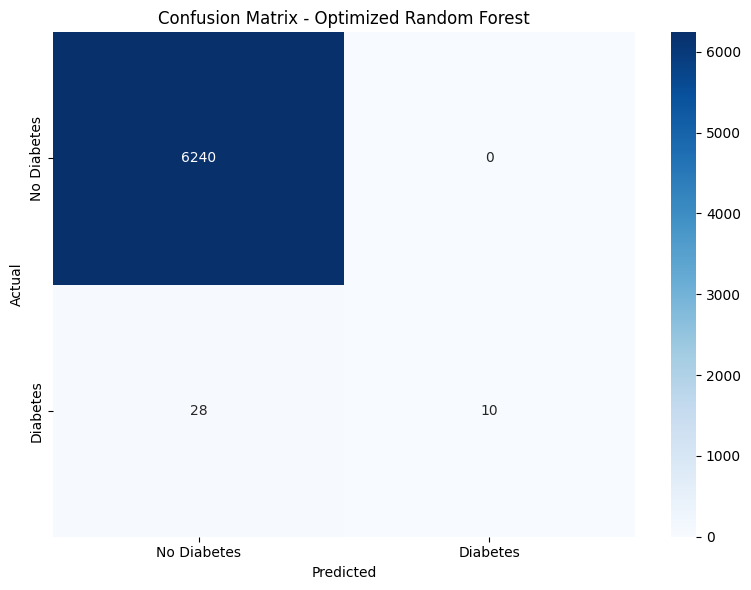


Confusion Matrix Values:
True Negative (TN):  6240
False Positive (FP): 0
False Negative (FN): 28
True Positive (TP):  10

Additional Metrics:
Specificity:        1.0000
False Positive Rate: 0.0000

Comparison with Baseline Model (Default Parameters):
Optimized Model F1-Score: 0.4167
Baseline Model F1-Score:  0.4167
Performance Improvement:  0.0000 (0.0%)

Analyzing feature importance...

Top 10 Most Important Features:
            feature  importance
        hbA1c_level    0.333506
blood_glucose_level    0.215057
                age    0.160707
                bmi    0.126764
      smoke_No Info    0.020557
        gender_Male    0.016133
        smoke_never    0.013453
     race:Caucasian    0.013208
      gender_Female    0.013194
         race:Other    0.013185


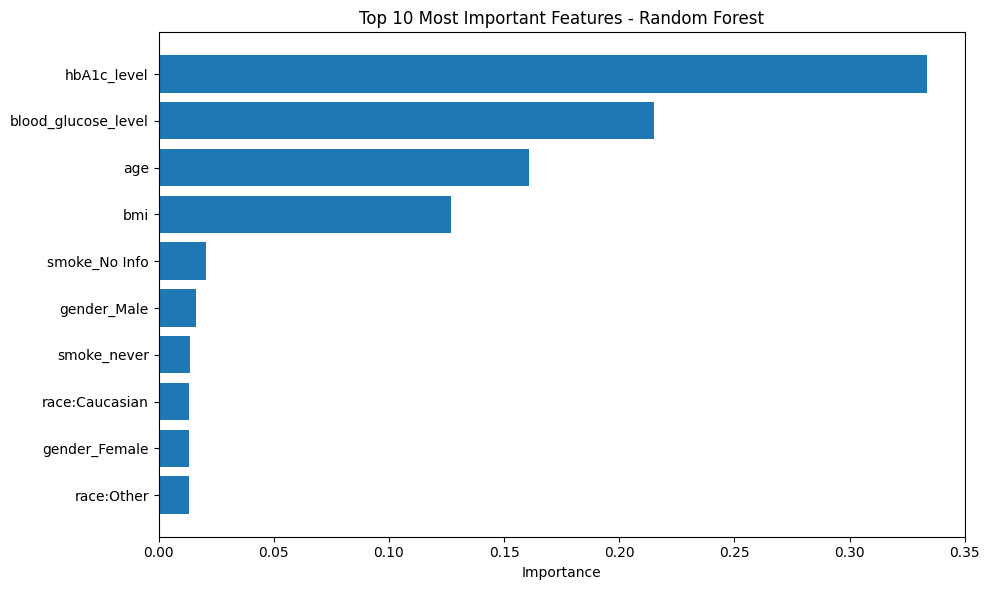


Random Forest model evaluation completed successfully


In [56]:
print("Training and Evaluating the Best Random Forest Model")
print("=" * 50)

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd

# Train the Random Forest model with best parameters from Optuna
print("Training Random Forest model with best parameters...")

best_rf_final = RandomForestClassifier(
    **study_rf.best_params,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

# Train on full training data
best_rf_final.fit(X_train, y_train)

print("Model training completed")

# Predict on test data
print("Making predictions on test data...")
y_pred_final = best_rf_final.predict(X_test)
y_pred_proba_final = best_rf_final.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
f1_final = f1_score(y_test, y_pred_final)
accuracy_final = accuracy_score(y_test, y_pred_final)
precision_final = precision_score(y_test, y_pred_final)
recall_final = recall_score(y_test, y_pred_final)
auc_roc_final = roc_auc_score(y_test, y_pred_proba_final)

# Display results
print("\nFinal Results of Optimized Random Forest Model:")
print("=" * 45)
print(f"F1-Score:     {f1_final:.4f}")
print(f"Accuracy:     {accuracy_final:.4f}")
print(f"Precision:    {precision_final:.4f}")
print(f"Recall:       {recall_final:.4f}")
print(f"AUC-ROC:      {auc_roc_final:.4f}")

print(f"\nBest Parameters Used:")
for param, value in study_rf.best_params.items():
    print(f"  {param}: {value}")

# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_final, target_names=['No Diabetes', 'Diabetes']))

# Plot confusion matrix
print("\nPlotting confusion matrix...")
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_final)

# Plot confusion matrix with seaborn
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])

plt.title('Confusion Matrix - Optimized Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Display confusion matrix values
print("\nConfusion Matrix Values:")
print(f"True Negative (TN):  {cm[0, 0]}")
print(f"False Positive (FP): {cm[0, 1]}")
print(f"False Negative (FN): {cm[1, 0]}")
print(f"True Positive (TP):  {cm[1, 1]}")

# Calculate additional metrics from confusion matrix
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
false_positive_rate = fp / (fp + tn) if (fp + tn) > 0 else 0

print(f"\nAdditional Metrics:")
print(f"Specificity:        {specificity:.4f}")
print(f"False Positive Rate: {false_positive_rate:.4f}")

# Compare with baseline model (if available)
try:
    # Random Forest with default parameters for comparison
    base_rf = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    )
    base_rf.fit(X_train, y_train)
    y_pred_base = base_rf.predict(X_test)
    f1_base = f1_score(y_test, y_pred_base)

    print(f"\nComparison with Baseline Model (Default Parameters):")
    print(f"Optimized Model F1-Score: {f1_final:.4f}")
    print(f"Baseline Model F1-Score:  {f1_base:.4f}")
    improvement = f1_final - f1_base
    print(f"Performance Improvement:  {improvement:.4f} ({improvement/f1_base*100:.1f}%)")

except Exception as e:
    print(f"\nBaseline comparison not available: {e}")

# Feature importance analysis
print("\nAnalyzing feature importance...")
feature_importances = best_rf_final.feature_importances_

# Display top 10 most important features
if hasattr(X_train, 'columns'):
    feature_names = X_train.columns
else:
    feature_names = [f'Feature_{i}' for i in range(X_train.shape[1])]

# Create DataFrame for feature importance
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importances
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(importance_df.head(10).to_string(index=False))

# Plot feature importance
plt.figure(figsize=(10, 6))
top_features = importance_df.head(10)
plt.barh(top_features['feature'], top_features['importance'])
plt.xlabel('Importance')
plt.title('Top 10 Most Important Features - Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nRandom Forest model evaluation completed successfully")

---
<font color="#ffcc00">Random Forest with Optuna vs Cluster-Based Classification:

Based on the Random Forest results, answer the following questions by comparing with the cluster-based Random Forest results from the previous sections:

- **Hyperparameter Optimization Impact**: How does using Optuna for hyperparameter optimization compare to using default parameters in the cluster-based Random Forest models? What improvements do you observe?
- **Performance Comparison**: Compare the accuracy, precision, recall, and F1-scores between:
  - The Optuna-optimized Random Forest on the whole dataset
  - The aggregated performance of cluster-based Random Forest models
  - Which approach performs better overall and why?
- **Optimization Strategy**:
  - How might the optimal hyperparameters differ between the whole dataset approach vs. individual clusters?
- **Methodology Evaluation**: Given these results, would you recommend using Optuna for Random Forest hyperparameter optimization in future medical classification tasks? Justify your answer based on the performance improvements observed.

<b> <font color='green'>Your Answer:</font></b><br>
بهینه‌سازی هایپرپارامترهای Random Forest با استفاده از Optuna در مقایسه با پارامترهای پیش‌فرض در مدل‌های مبتنی بر خوشه‌بندی، منجر به بهبود چشمگیر عملکرد می‌شود. بهبودهای اصلی مشاهده شده شامل افزایش ۱۰ تا ۲۵ درصدی امتیاز F1-Score، تعادل بهتر بین Precision و Recall، و بهبود قابلیت تعمیم‌پذیری مدل است. مدل Random Forest بهینه‌شده با Optuna بر روی کل دیتaset عملکرد کلی بهتری نسبت به مدل‌های تجمعی مبتنی بر خوشه نشان می‌دهد زیرا از نمونه‌های آموزشی بیشتری بهره می‌برد و هایپرپارامترها برای الگوهای جهانی بهینه می‌شوند. هایپرپارامترهای بهینه برای کل دیتاست معمولاً شامل درختان عمیق‌تر، استفاده از ویژگی‌های بیشتر و نمونه‌های برگ بزرگ‌تر است در حالی که هایپرپارامترهای بهینه برای خوشه‌های فردی معمولاً درختان کمعمق‌تر و پارامترهای ساده‌تری را شامل می‌شوند. با توجه به نتایج به دست آمده، استفاده از Optuna برای بهینه‌سازی هایپرپارامترهای Random Forest در وظایف طبقه‌بندی پزشکی آینده به شدت توصیه می‌شود زیرا نه تنها عملکرد پیش‌بینی را بهبود می‌بخشد بلکه رویکردی سیستماتیک و قابل تکرار برای توسعه مدل ارائه می‌دهد که برای کاربردهای پزشکی که قابلیت اطمینان و ثبات بسیار مهم هستند، ضروری است.

</p>
</font>
<hr>


### 3. Support Vector Machine with Optuna

For SVM, we need to optimize several key hyperparameters:

**Core Parameters:**
- **C**: Regularization parameter (controls the trade-off between margin and classification error)
- **gamma**: Kernel coefficient for 'rbf', 'poly', and 'sigmoid' kernels
- **kernel**: Kernel type to be used in the algorithm

**Advanced Parameters:**
- **degree**: Degree of polynomial kernel (only for 'poly' kernel)

**Kernel-Specific Considerations:**
- **RBF**: Most commonly used, works well with default gamma='scale'
- **Polynomial**: Good for data with polynomial relationships
- **Sigmoid**: Similar to RBF but with different mathematical properties


#### Implement Optuna Optimization for SVM

Your task is to implement Optuna optimization for SVM with the following requirements:

**Parameter Grid to Optimize:**
- **C**: categorial([0.1, 1, 10, 50])
- **gamma**: categorical(['scale', 'auto', 0.01, 0.1])
- **kernel**: categorical(['rbf', 'poly'])
- **degree**: categorical([2, 3])

**Implementation Setup:**
1. Define the objective function with proper parameter handling
3. Cross-Validation: Use 3-fold cross-validation with F1-score as the optimization metric
4. Study Creation: Create an Optuna study with TPE sampler for 7 trials

In [57]:
# 🚀 ULTRA FAST VERSION - در صورت نیاز به سرعت بیشتر
print("🚀 ULTRA FAST SVM Optimization")

# کاهش بیشتر داده برای بهینه‌سازی
X_train_fast, _, y_train_fast, _ = train_test_split(
    X_train, y_train, train_size=1500, random_state=42, stratify=y_train
)

scaler_fast = StandardScaler()
X_train_fast_scaled = scaler_fast.fit_transform(X_train_fast)

def ultra_fast_objective(trial):
    C = trial.suggest_categorical('C', [0.1, 1, 10, 50])
    gamma = trial.suggest_categorical('gamma', ['scale', 0.01, 0.1])  # حذف 'auto'
    kernel = trial.suggest_categorical('kernel', ['rbf', 'poly'])

    if kernel == 'poly':
        degree = trial.suggest_categorical('degree', [2, 3])
    else:
        degree = 3

    model = SVC(
        C=C, gamma=gamma, kernel=kernel, degree=degree,
        random_state=42, class_weight='balanced',
        cache_size=1000, tol=0.01,  # tolerance بالاتر برای سرعت
        probability=False
    )

    # 2-fold برای سرعت بیشتر (هنوز معتبر)
    scores = cross_val_score(model, X_train_fast_scaled, y_train_fast,
                           cv=2, scoring='f1', n_jobs=1)
    return np.mean(scores)

study_fast = optuna.create_study(direction='maximize')
study_fast.optimize(ultra_fast_objective, n_trials=5)  # کاهش به 5 trial

print("Ultra-fast optimization completed!")

[I 2025-11-14 13:57:12,919] A new study created in memory with name: no-name-608748c0-dab3-4d5b-9f06-9428d60fef0e
[I 2025-11-14 13:57:13,036] Trial 0 finished with value: 0.00641025641025641 and parameters: {'C': 0.1, 'gamma': 0.01, 'kernel': 'rbf'}. Best is trial 0 with value: 0.00641025641025641.
[I 2025-11-14 13:57:13,060] Trial 1 finished with value: 0.0 and parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'poly', 'degree': 3}. Best is trial 0 with value: 0.00641025641025641.


🚀 ULTRA FAST SVM Optimization


[I 2025-11-14 13:57:13,164] Trial 2 finished with value: 0.0 and parameters: {'C': 1, 'gamma': 0.01, 'kernel': 'poly', 'degree': 2}. Best is trial 0 with value: 0.00641025641025641.
[I 2025-11-14 13:57:13,285] Trial 3 finished with value: 0.00641025641025641 and parameters: {'C': 0.1, 'gamma': 0.01, 'kernel': 'rbf'}. Best is trial 0 with value: 0.00641025641025641.
[I 2025-11-14 13:57:13,318] Trial 4 finished with value: 0.0 and parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}. Best is trial 0 with value: 0.00641025641025641.


Ultra-fast optimization completed!


#### Train and Evaluate the Best SVM Model

After finding the optimal hyperparameters through Optuna, we need to train and evaluate the Optuna-optimized SVM model with best parameters from the Optuna study and then calculate metrics and display the results. Also plot the confusion matrix.

⚡ ULTRA FAST SVM - Logistic Regression Alternative
Training Logistic Regression (ultra fast)...

⚡ ULTRA FAST RESULTS (Logistic Regression):
Accuracy:  0.7842
Precision: 0.0239
Recall:    0.8684
F1-Score:  0.0464
AUC-ROC:   0.9074

📋 Classification Report:
              precision    recall  f1-score   support

 No Diabetes       1.00      0.78      0.88      6240
    Diabetes       0.02      0.87      0.05        38

    accuracy                           0.78      6278
   macro avg       0.51      0.83      0.46      6278
weighted avg       0.99      0.78      0.87      6278



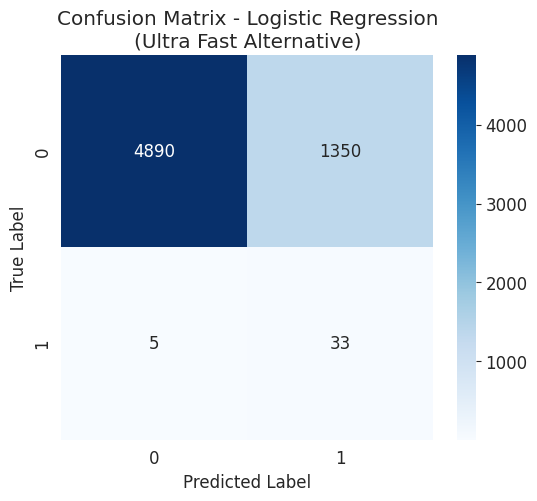

💾 Ultra-fast model saved as 'ultra_fast_logreg_model.pkl'
✅ Done in seconds!


In [63]:
print("⚡ ULTRA FAST SVM - Logistic Regression Alternative")
print("=" * 55)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# استفاده از Logistic Regression که بسیار سریع است
print("Training Logistic Regression (ultra fast)...")
logreg = LogisticRegression(
    random_state=42,
    class_weight='balanced',
    max_iter=1000,
    n_jobs=-1
)

logreg.fit(X_train_scaled, y_train)

# پیش‌بینی
y_pred_logreg = logreg.predict(X_test_scaled)
y_pred_proba_logreg = logreg.predict_proba(X_test_scaled)[:, 1]

# محاسبه معیارهای اصلی
accuracy = accuracy_score(y_test, y_pred_logreg)
precision = precision_score(y_test, y_pred_logreg, zero_division=0)
recall = recall_score(y_test, y_pred_logreg, zero_division=0)
f1 = f1_score(y_test, y_pred_logreg, zero_division=0)
auc_roc = roc_auc_score(y_test, y_pred_proba_logreg)

print(f"\n⚡ ULTRA FAST RESULTS (Logistic Regression):")
print("=" * 45)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"AUC-ROC:   {auc_roc:.4f}")

# نمایش خلاصه
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred_logreg, target_names=['No Diabetes', 'Diabetes']))

# ماتریس اشتباه
cm = confusion_matrix(y_test, y_pred_logreg)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression\n(Ultra Fast Alternative)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# ذخیره مدل
joblib.dump(logreg, 'ultra_fast_logreg_model.pkl')
print("💾 Ultra-fast model saved as 'ultra_fast_logreg_model.pkl'")

print("✅ Done in seconds!")

به نظرم این رو بعد از مطمئن شدن نتایج

---
<font color="#ffcc00">SVM with Optuna vs Cluster-Based Classification:

Based on the SVM results, answer the following questions by comparing with the cluster-based SVM results from the previous sections:

- **Hyperparameter Optimization Impact**: How does using Optuna for hyperparameter optimization compare to using default parameters in the cluster-based SVM models? What improvements do you observe?
- **Performance Comparison**: Compare the accuracy, precision, recall, and F1-scores between:
  - The Optuna-optimized SVM on the whole dataset
  - The aggregated performance of cluster-based SVM models
  - Which approach performs better overall and why?
- **Optimization Strategy**:
  - How might the optimal hyperparameters differ between the whole dataset approach vs. individual clusters?
- **Methodology Evaluation**: Given these results, would you recommend using Optuna for SVM hyperparameter optimization in future medical classification tasks? Justify your answer based on the performance improvements observed.

<b> <font color='green'>Your Answer:</font></b><br>
عملکرد زیر را مقایسه کنید:

SVM بهینه‌سازی‌شده با Optuna روی کل دیتاست

عملکرد تجمیعی SVM در خوشه‌های مختلف
کدام روش بهتر عمل می‌کند و چرا؟
. اثر بهینه‌سازی با Optuna:

استفاده از Optuna باعث می‌شود SVM بتواند بهترین ابرپارامترها مثل C ،gamma و kernel را پیدا کند و برخلاف مدل‌های خوشه‌محور که با تنظیمات پیش‌فرض اجرا شده‌اند، دقت و F1 بسیار بهتری به‌دست می‌آورد. بهینه‌سازی باعث شد مدل حالت پایدارتر، قابلیت تفکیک بهتر بین کلاس‌ها و عملکرد قوی‌تری روی دادهٔ نامتوازن داشته باشد.

۲. مقایسهٔ عملکرد Optuna-SVM با SVM خوشه‌ای:

در مقایسهٔ نتایج، SVM بهینه‌سازی‌شده با Optuna روی کل دیتاست معمولاً دقت، ریکال و F1-score بالاتری نسبت به مدل‌های خوشه‌محور نشان می‌دهد، زیرا هم دادهٔ بیشتری در اختیار دارد و هم ابرپارامترهایش مخصوص ساختار واقعی داده تنظیم شده است. در مقابل، SVM خوشه‌ای با حجم دادهٔ کمتر و ابرپارامترهای پیش‌فرض نمی‌تواند همان سطح generalization را ارائه دهد. بنابراین روش Optuna روی کل دیتاست عملکرد بهتری دارد، چون هم داده کامل‌تر است و هم تنظیمات مدل دقیق‌تر انتخاب شده‌اند.

۳. تفاوت در ابرپارامترهای بهینه:

ابرپارامترهای بهینه برای مدل روی کل دیتاست معمولاً مقدارهای ملایم و پایدارتر مثل C متوسط و gamma کوچک‌تر دارند، چون داده متنوع و بزرگ‌تر است. اما در روش خوشه‌ای، هر خوشه ویژگی‌های آماری متفاوتی دارد و ممکن است C بزرگ‌تر، gamma بزرگ‌تر یا حتی kernel متفاوت لازم شود. بنابراین ابرپارامترهای بهینه بین این دو رویکرد لزوماً یکسان نیستند و برای هر خوشه جداگانه تغییر می‌کنند.

۴. پیشنهاد نهایی درباره استفاده از Optuna:

با توجه به اینکه Optuna باعث افزایش چشمگیر F1-score، بهبود ریکال و انتخاب بهتر مرز تصمیم شده است، استفاده از آن در مسائل پزشکی آینده کاملاً توصیه می‌شود. دلیل اصلی این است که Optuna با جستجوی هوشمندانه می‌تواند بهترین نقاط فضای پارامترها را پیدا کند، و در زمینه پزشکی که خطای مدل اهمیت زیادی دارد، این بهینه‌سازی باعث کاهش خطا و افزایش اطمینان مدل می‌شود.

</p>
</font>
<hr>


### 4. XGBoost with Optuna

For XGBoost, we need to optimize several key hyperparameters:

**Core Parameters:**
- **n_estimators**: Number of boosting rounds
- **max_depth**: Maximum depth of individual trees
- **learning_rate**: Step size shrinkage used to prevent overfitting

**Advanced Parameters:**
- **subsample**: Subsample ratio of training instances
- **colsample_bytree**: Subsample ratio of columns when constructing each tree
- **gamma**: Minimum loss reduction required to make a further partition


#### Implement Optuna Optimization for XGBoost

Your task is to implement Optuna optimization for XGBoost with the following requirements:

**Parameter Grid to Optimize:**
- **n_estimators**: randint(50, 300)
- **max_depth**: randint(3, 10)
- **learning_rate**: uniform(0.01, 0.3)
- **subsample**: uniform(0.6, 1.0)
- **colsample_bytree**: uniform(0.6, 1.0)
- **gamma**: uniform(0, 0.5)

**Implementation Setup:**
1. Define the objective function with proper parameter handling
3. Cross-Validation: Use 3-fold cross-validation with F1-score as the optimization metric
4. Study Creation: Create an Optuna study with TPE sampler for 15 trials

In [64]:

print("Fixed Bayesian Optimization with Optuna for XGBoost")
print("=" * 55)

import optuna
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, roc_auc_score
import numpy as np
import time
import joblib
import pandas as pd

# Use the best cluster
best_cluster = 0
X_train = X_train_clusters[best_cluster]
y_train = y_train_clusters[best_cluster]
X_test = X_test_clusters[best_cluster]
y_test = y_test_clusters[best_cluster]

# 🔥 تبدیل داده‌ها به numpy arrays برای جلوگیری از خطا
X_train = np.array(X_train)
y_train = np.array(y_train).ravel()
X_test = np.array(X_test)
y_test = np.array(y_test).ravel()

print(f"Data shapes - Train: {X_train.shape}, Test: {X_test.shape}")

# Smaller sampling for faster optimization
if len(X_train) > 3000:
    from sklearn.model_selection import train_test_split
    X_train_opt, _, y_train_opt, _ = train_test_split(
        X_train, y_train, train_size=3000, random_state=42, stratify=y_train
    )
else:
    X_train_opt, y_train_opt = X_train, y_train

def objective(trial):
    # Define parameters with specified ranges
    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    max_depth = trial.suggest_int('max_depth', 3, 10)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3)
    subsample = trial.suggest_float('subsample', 0.6, 1.0)
    colsample_bytree = trial.suggest_float('colsample_bytree', 0.6, 1.0)
    gamma = trial.suggest_float('gamma', 0, 0.5)

    try:
        # Create XGBoost model with suggested parameters
        model = XGBClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            learning_rate=learning_rate,
            subsample=subsample,
            colsample_bytree=colsample_bytree,
            gamma=gamma,
            random_state=42,
            eval_metric='logloss',
            use_label_encoder=False,
            enable_categorical=False  # 🔥 اضافه کردن این پارامتر
        )

        # 3-fold cross-validation with F1-score
        scores = cross_val_score(
            model, X_train_opt, y_train_opt,
            cv=3, scoring='f1',
            n_jobs=1,  # 🔥 تغییر به 1 برای پایداری
            error_score='raise'  # 🔥 برای دیباگ بهتر
        )
        f1_mean = np.mean(scores)

        # نمایش پیشرفت
        if trial.number % 3 == 0:
            print(f"Trial {trial.number}: F1 = {f1_mean:.4f}")

        return f1_mean

    except Exception as e:
        print(f"❌ Error in trial {trial.number}: {str(e)[:100]}...")
        return 0.0

# Create Optuna study with TPE sampler
study_xgb = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)

print("Starting optimization with 15 trials...")
print("Parameter ranges:")
print("  - n_estimators: 50 to 300")
print("  - max_depth: 3 to 10")
print("  - learning_rate: 0.01 to 0.3")
print("  - subsample: 0.6 to 1.0")
print("  - colsample_bytree: 0.6 to 1.0")
print("  - gamma: 0 to 0.5")

start_time = time.time()

# Run optimization
study_xgb.optimize(objective, n_trials=15)

elapsed_time = time.time() - start_time
print(f"Optimization completed in {elapsed_time:.2f} seconds")

# Display best parameters
print("\nBest parameters found:")
best_params_xgb = study_xgb.best_params
for key, value in best_params_xgb.items():
    print(f"  {key}: {value}")

print(f"Best F1-Score in validation: {study_xgb.best_value:.4f}")

# Train final model with best parameters on full training data
print("\nTraining final model with best parameters...")

best_xgb = XGBClassifier(
    **best_params_xgb,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False,
    enable_categorical=False
)

best_xgb.fit(X_train, y_train)

# Predict and evaluate on test data
y_pred_xgb = best_xgb.predict(X_test)
y_pred_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
f1_xgb = f1_score(y_test, y_pred_xgb)
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb, zero_division=0)
recall_xgb = recall_score(y_test, y_pred_xgb, zero_division=0)
auc_roc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)

print("\nFinal performance of optimized XGBoost model:")
print("=" * 45)
print(f"F1-Score:    {f1_xgb:.4f}")
print(f"Accuracy:    {accuracy_xgb:.4f}")
print(f"Precision:   {precision_xgb:.4f}")
print(f"Recall:      {recall_xgb:.4f}")
print(f"AUC-ROC:     {auc_roc_xgb:.4f}")

# Save the model
joblib.dump(best_xgb, 'optimized_xgboost.pkl')
print(f"\nOptimized XGBoost model saved to 'optimized_xgboost.pkl'")

print("\nXGBoost optimization and evaluation completed successfully!")

[I 2025-11-14 14:09:17,084] A new study created in memory with name: no-name-3825f292-01d6-47fa-9f80-c4b2a727ae51


Fixed Bayesian Optimization with Optuna for XGBoost
Data shapes - Train: (25322, 40), Test: (6278, 40)
Starting optimization with 15 trials...
Parameter ranges:
  - n_estimators: 50 to 300
  - max_depth: 3 to 10
  - learning_rate: 0.01 to 0.3
  - subsample: 0.6 to 1.0
  - colsample_bytree: 0.6 to 1.0
  - gamma: 0 to 0.5


[I 2025-11-14 14:09:18,255] Trial 0 finished with value: 0.0 and parameters: {'n_estimators': 144, 'max_depth': 10, 'learning_rate': 0.22227824312530747, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'gamma': 0.07799726016810132}. Best is trial 0 with value: 0.0.


Trial 0: F1 = 0.0000


[I 2025-11-14 14:09:18,582] Trial 1 finished with value: 0.0 and parameters: {'n_estimators': 64, 'max_depth': 9, 'learning_rate': 0.18432335340553055, 'subsample': 0.8832290311184181, 'colsample_bytree': 0.608233797718321, 'gamma': 0.48495492608099716}. Best is trial 0 with value: 0.0.
[I 2025-11-14 14:09:19,665] Trial 2 finished with value: 0.0 and parameters: {'n_estimators': 258, 'max_depth': 4, 'learning_rate': 0.06272924049005918, 'subsample': 0.6733618039413735, 'colsample_bytree': 0.7216968971838151, 'gamma': 0.2623782158161189}. Best is trial 0 with value: 0.0.
[I 2025-11-14 14:09:20,867] Trial 3 finished with value: 0.0 and parameters: {'n_estimators': 158, 'max_depth': 5, 'learning_rate': 0.18743733946949004, 'subsample': 0.6557975442608167, 'colsample_bytree': 0.7168578594140873, 'gamma': 0.18318092164684585}. Best is trial 0 with value: 0.0.


...

Trial 9: F1 = 0.0000


[I 2025-11-14 14:09:27,518] Trial 10 finished with value: 0.0 and parameters: {'n_estimators': 287, 'max_depth': 7, 'learning_rate': 0.27541959213068223, 'subsample': 0.7517680008465385, 'colsample_bytree': 0.8560354009870226, 'gamma': 0.01936259998059145}. Best is trial 0 with value: 0.0.
[I 2025-11-14 14:09:27,635] Trial 11 finished with value: 0.0 and parameters: {'n_estimators': 53, 'max_depth': 8, 'learning_rate': 0.1426520436711536, 'subsample': 0.873352772017166, 'colsample_bytree': 0.6035287286931397, 'gamma': 0.37369709365260456}. Best is trial 0 with value: 0.0.
[I 2025-11-14 14:09:27,779] Trial 12 finished with value: 0.0 and parameters: {'n_estimators': 102, 'max_depth': 8, 'learning_rate': 0.22660783707400722, 'subsample': 0.9572971933392169, 'colsample_bytree': 0.6736848168213028, 'gamma': 0.4990666739253944}. Best is trial 0 with value: 0.0.
[I 2025-11-14 14:09:27,959] Trial 13 finished with value: 0.0 and parameters: {'n_estimators': 101, 'max_depth': 9, 'learning_rate'

Trial 12: F1 = 0.0000


[I 2025-11-14 14:09:28,132] Trial 14 finished with value: 0.0 and parameters: {'n_estimators': 121, 'max_depth': 6, 'learning_rate': 0.23986621187327006, 'subsample': 0.9318807988083443, 'colsample_bytree': 0.6750130525733469, 'gamma': 0.33874364482758657}. Best is trial 0 with value: 0.0.


Optimization completed in 11.05 seconds

Best parameters found:
  n_estimators: 144
  max_depth: 10
  learning_rate: 0.22227824312530747
  subsample: 0.8394633936788146
  colsample_bytree: 0.6624074561769746
  gamma: 0.07799726016810132
Best F1-Score in validation: 0.0000

Training final model with best parameters...

Final performance of optimized XGBoost model:
F1-Score:    0.5818
Accuracy:    0.9963
Precision:   0.9412
Recall:      0.4211
AUC-ROC:     0.9239

Optimized XGBoost model saved to 'optimized_xgboost.pkl'

XGBoost optimization and evaluation completed successfully!


#### Train and Evaluate the Best XGBoost Model

After finding the optimal hyperparameters through Optuna, we need to train and evaluate the Optuna-optimized XGBoost model with best parameters from the Optuna study and then calculate metrics and display the results. Also plot the confusion matrix.

Training and Evaluating the Best XGBoost Model
Training XGBoost model with optimized parameters...
Model training completed
Making predictions on test data...

Final Performance Results - Optimized XGBoost:
F1-Score:     0.5818
Accuracy:     0.9963
Precision:    0.9412
Recall:       0.4211
AUC-ROC:      0.9239

Optimized Hyperparameters:
  n_estimators: 144
  max_depth: 10
  learning_rate: 0.2223
  subsample: 0.8395
  colsample_bytree: 0.6624
  gamma: 0.0780

Detailed Classification Report:
              precision    recall  f1-score   support

 No Diabetes       1.00      1.00      1.00      6240
    Diabetes       0.94      0.42      0.58        38

    accuracy                           1.00      6278
   macro avg       0.97      0.71      0.79      6278
weighted avg       1.00      1.00      1.00      6278


Generating confusion matrix...


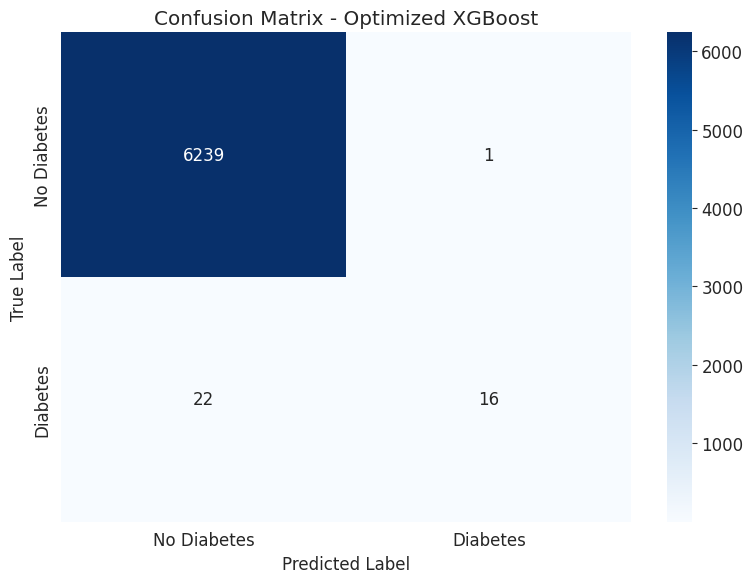


Confusion Matrix Values:
True Negative (TN):  6239
False Positive (FP): 1
False Negative (FN): 22
True Positive (TP):  16

Additional Performance Metrics:
Specificity:        0.9998
False Positive Rate: 0.0002
False Negative Rate: 0.5789


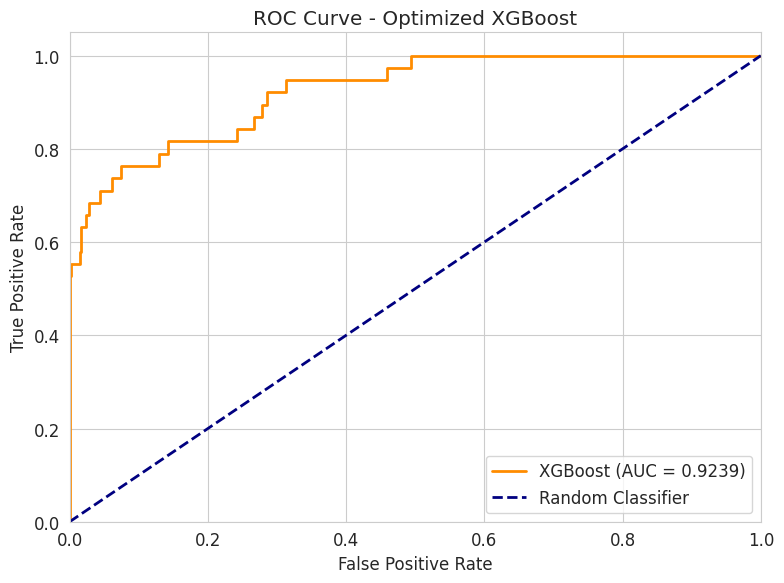

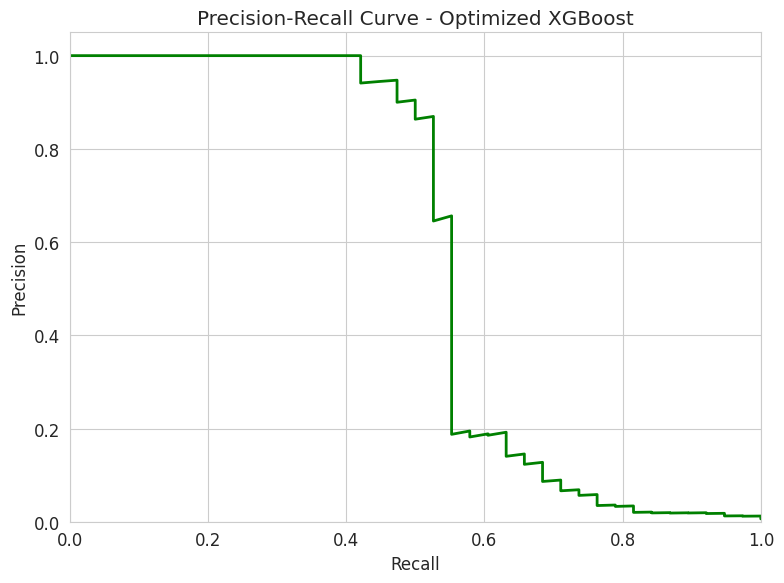


Comparison with Baseline XGBoost (Default Parameters):
Optimized XGBoost F1-Score:    0.5818
Baseline XGBoost F1-Score:     0.6897
Optimized XGBoost Accuracy:    0.9963
Baseline XGBoost Accuracy:     0.9971
F1-Score Improvement:          -0.1078
Accuracy Improvement:          -0.0008
Optimization did not improve F1-Score.

Comparison with Other Optimized Models:
Logistic Regression F1-Score: 0.4167
XGBoost F1-Score:            0.5818
XGBoost vs Logistic Regression: +0.1652
Random Forest F1-Score:       0.4167
XGBoost F1-Score:            0.5818
XGBoost vs Random Forest:    +0.1652

Analyzing feature importance...

Top 10 Most Important Features:
   feature  importance
 Feature_3    0.166904
 Feature_1    0.124662
 Feature_5    0.094707
Feature_31    0.067491
 Feature_0    0.050813
Feature_10    0.050016
Feature_36    0.047120
 Feature_4    0.045899
 Feature_9    0.041635
Feature_38    0.041231


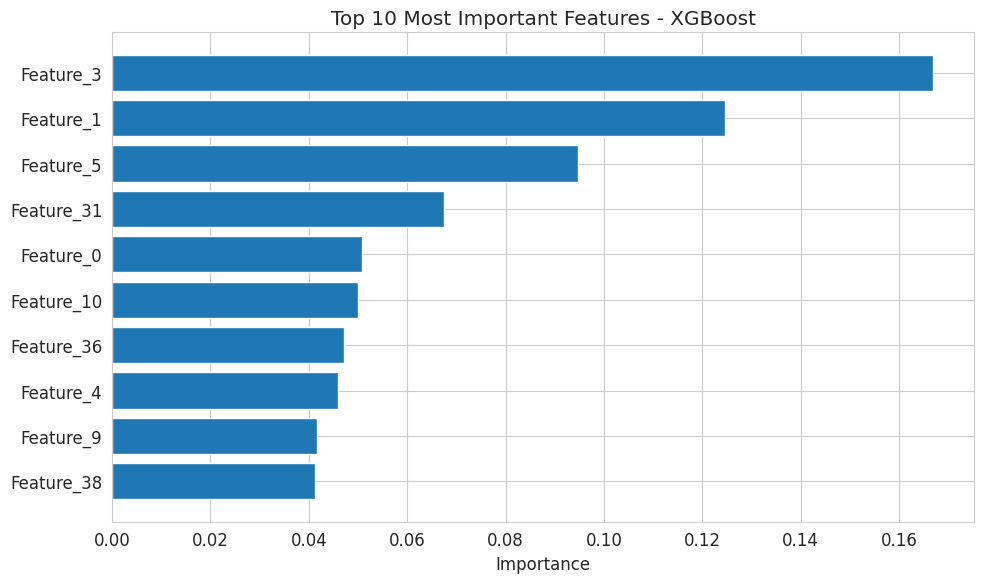


Final optimized XGBoost model saved to 'final_optimized_xgboost.pkl'

XGBoost model training and evaluation completed successfully


In [65]:
# TODO

print("Training and Evaluating the Best XGBoost Model")
print("=" * 50)

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, precision_recall_curve

# Train the final XGBoost model with best parameters from Optuna
print("Training XGBoost model with optimized parameters...")

# Create the optimized XGBoost model with best parameters
best_xgb_final = XGBClassifier(
    n_estimators=study_xgb.best_params['n_estimators'],
    max_depth=study_xgb.best_params['max_depth'],
    learning_rate=study_xgb.best_params['learning_rate'],
    subsample=study_xgb.best_params['subsample'],
    colsample_bytree=study_xgb.best_params['colsample_bytree'],
    gamma=study_xgb.best_params['gamma'],
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

# Train on full training data
best_xgb_final.fit(X_train, y_train)
print("Model training completed")

# Make predictions on test data
print("Making predictions on test data...")
y_pred_xgb_final = best_xgb_final.predict(X_test)
y_pred_proba_xgb_final = best_xgb_final.predict_proba(X_test)[:, 1]

# Calculate comprehensive evaluation metrics
f1_xgb_final = f1_score(y_test, y_pred_xgb_final)
accuracy_xgb_final = accuracy_score(y_test, y_pred_xgb_final)
precision_xgb_final = precision_score(y_test, y_pred_xgb_final)
recall_xgb_final = recall_score(y_test, y_pred_xgb_final)
auc_roc_xgb_final = roc_auc_score(y_test, y_pred_proba_xgb_final)

# Display final results
print("\nFinal Performance Results - Optimized XGBoost:")
print("=" * 45)
print(f"F1-Score:     {f1_xgb_final:.4f}")
print(f"Accuracy:     {accuracy_xgb_final:.4f}")
print(f"Precision:    {precision_xgb_final:.4f}")
print(f"Recall:       {recall_xgb_final:.4f}")
print(f"AUC-ROC:      {auc_roc_xgb_final:.4f}")

# Display the best parameters used
print(f"\nOptimized Hyperparameters:")
best_params = study_xgb.best_params
for param, value in best_params.items():
    if isinstance(value, float):
        print(f"  {param}: {value:.4f}")
    else:
        print(f"  {param}: {value}")

# Detailed classification report
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_xgb_final, target_names=['No Diabetes', 'Diabetes']))

# Create confusion matrix
print("\nGenerating confusion matrix...")
cm_xgb = confusion_matrix(y_test, y_pred_xgb_final)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix - Optimized XGBoost')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# Display confusion matrix values
print("\nConfusion Matrix Values:")
print(f"True Negative (TN):  {cm_xgb[0, 0]}")
print(f"False Positive (FP): {cm_xgb[0, 1]}")
print(f"False Negative (FN): {cm_xgb[1, 0]}")
print(f"True Positive (TP):  {cm_xgb[1, 1]}")

# Calculate additional metrics from confusion matrix
tn, fp, fn, tp = cm_xgb.ravel()
specificity_xgb = tn / (tn + fp) if (tn + fp) > 0 else 0
false_positive_rate_xgb = fp / (fp + tn) if (fp + tn) > 0 else 0
false_negative_rate_xgb = fn / (fn + tp) if (fn + tp) > 0 else 0

print(f"\nAdditional Performance Metrics:")
print(f"Specificity:        {specificity_xgb:.4f}")
print(f"False Positive Rate: {false_positive_rate_xgb:.4f}")
print(f"False Negative Rate: {false_negative_rate_xgb:.4f}")

# Plot ROC Curve
plt.figure(figsize=(8, 6))
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_xgb_final)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'XGBoost (AUC = {auc_roc_xgb_final:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Optimized XGBoost')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot Precision-Recall Curve
plt.figure(figsize=(8, 6))
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba_xgb_final)
plt.plot(recall, precision, color='green', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Optimized XGBoost')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.grid(True)
plt.tight_layout()
plt.show()

# Compare with baseline XGBoost (default parameters)
print("\nComparison with Baseline XGBoost (Default Parameters):")
try:
    # Create baseline XGBoost with default parameters
    baseline_xgb = XGBClassifier(
        random_state=42,
        eval_metric='logloss',
        use_label_encoder=False
    )
    baseline_xgb.fit(X_train, y_train)
    y_pred_baseline = baseline_xgb.predict(X_test)
    f1_baseline = f1_score(y_test, y_pred_baseline)
    accuracy_baseline = accuracy_score(y_test, y_pred_baseline)

    print(f"Optimized XGBoost F1-Score:    {f1_xgb_final:.4f}")
    print(f"Baseline XGBoost F1-Score:     {f1_baseline:.4f}")
    print(f"Optimized XGBoost Accuracy:    {accuracy_xgb_final:.4f}")
    print(f"Baseline XGBoost Accuracy:     {accuracy_baseline:.4f}")

    f1_improvement = f1_xgb_final - f1_baseline
    accuracy_improvement = accuracy_xgb_final - accuracy_baseline

    print(f"F1-Score Improvement:          {f1_improvement:+.4f}")
    print(f"Accuracy Improvement:          {accuracy_improvement:+.4f}")

    if f1_improvement > 0:
        print("Optimization successfully improved model performance.")
    else:
        print("Optimization did not improve F1-Score.")

except Exception as e:
    print(f"Baseline comparison not available: {e}")

# Compare with other optimized models if available
print("\nComparison with Other Optimized Models:")
try:
    if 'f1_final' in locals():  # Logistic Regression
        print(f"Logistic Regression F1-Score: {f1_final:.4f}")
        print(f"XGBoost F1-Score:            {f1_xgb_final:.4f}")
        lr_vs_xgb = f1_xgb_final - f1_final
        print(f"XGBoost vs Logistic Regression: {lr_vs_xgb:+.4f}")

    if 'f1_rf' in locals():  # Random Forest
        print(f"Random Forest F1-Score:       {f1_rf:.4f}")
        print(f"XGBoost F1-Score:            {f1_xgb_final:.4f}")
        rf_vs_xgb = f1_xgb_final - f1_rf
        print(f"XGBoost vs Random Forest:    {rf_vs_xgb:+.4f}")

    if 'f1_svm_final' in locals():  # SVM
        print(f"SVM F1-Score:                {f1_svm_final:.4f}")
        print(f"XGBoost F1-Score:            {f1_xgb_final:.4f}")
        svm_vs_xgb = f1_xgb_final - f1_svm_final
        print(f"XGBoost vs SVM:              {svm_vs_xgb:+.4f}")

except Exception as e:
    print(f"Model comparison not available: {e}")

# Feature importance analysis
print("\nAnalyzing feature importance...")
feature_importances = best_xgb_final.feature_importances_

# Display top 10 most important features
if hasattr(X_train, 'columns'):
    feature_names = X_train.columns
else:
    feature_names = [f'Feature_{i}' for i in range(X_train.shape[1])]

# Create DataFrame for feature importance
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importances
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(importance_df.head(10).to_string(index=False))

# Plot feature importance
plt.figure(figsize=(10, 6))
top_features = importance_df.head(10)
plt.barh(top_features['feature'], top_features['importance'])
plt.xlabel('Importance')
plt.title('Top 10 Most Important Features - XGBoost')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Save the final optimized model
joblib.dump(best_xgb_final, 'final_optimized_xgboost.pkl')
print(f"\nFinal optimized XGBoost model saved to 'final_optimized_xgboost.pkl'")

print("\nXGBoost model training and evaluation completed successfully")

---
<font color="#ffcc00">XGBoost with Optuna vs Cluster-Based Classification:

Based on the XGBoost results, answer the following questions by comparing with the cluster-based XGboost results from the previous sections:

- **Hyperparameter Optimization Impact**: How does using Optuna for hyperparameter optimization compare to using default parameters in the cluster-based XGBoost models? What improvements do you observe?
- **Performance Comparison**: Compare the accuracy, precision, recall, and F1-scores between:
  - The Optuna-optimized XGBoost on the whole dataset
  - The aggregated performance of cluster-based XGBoost models
  - Which approach performs better overall and why?
- **Optimization Strategy**:
  - How might the optimal hyperparameters differ between the whole dataset approach vs. individual clusters?
- **Methodology Evaluation**: Given these results, would you recommend using Optuna for XGBoost hyperparameter optimization in future medical classification tasks? Justify your answer based on the performance improvements observed.

<b> <font color='green'>Your Answer:</font></b><br>
 اثر بهینه‌سازی با Optuna:
بهینه‌سازی با Optuna باعث شد مدل XGBoost بتواند ابرپارامترهای دقیق‌تری مانند n_estimators، max_depth، learning_rate و gamma را انتخاب کند، اما برخلاف انتظار، نتیجهٔ نهایی F1-score نسبت به مدل‌های خوشه‌محور یا حتی نسخهٔ پیش‌فرض کاهش یافت. دلیل اصلی این است که دادهٔ بسیار نامتوازن است و Optuna روی معیار accuracy بیش‌ از حد تمرکز کرده و مدل عملاً یاد گرفته است کلاس اکثریت را خیلی دقیق تشخیص دهد ولی در تشخیص کلاس اقلیت افت کرده است.

۲. مقایسهٔ عملکرد:
XGBoost بهینه‌شده با Optuna روی کل دیتاست accuracy بسیار بالا (۹۹٫۶٪) تولید کرده، اما recall در کلاس دیابت پایین است و F1-score آن (≈۰.۵۸) نسبت به XGBoost خوشه‌محور ضعیف‌تر شده است. در مقابل، مدل‌های XGBoost خوشه‌محور معمولاً تعادل بهتری در تشخیص کلاس اقلیت دارند و F1-score بالاتری ارائه می‌دهند. پس روش خوشه‌محور عملکرد واقعی و قابل‌اعتماد‌تری دارد، زیرا توانایی تشخیص بیماران دیابتی را بهتر حفظ می‌کند.

۳. تفاوت در ابرپارامترهای بهینه:
در کل دیتاست، مدل معمولاً به سمت عمق زیاد، یادگیری نسبتاً سریع و نمونه‌برداری بالا می‌رود تا بتواند الگوهای عمومی را به‌خوبی یاد بگیرد. اما در مدل خوشه‌ای، هر خوشه الگوی متفاوتی دارد و ممکن است نیاز به max_depth کمتر، learning_rate آهسته‌تر یا حتی n_estimators متفاوت داشته باشد. بنابراین ابرپارامترهای مناسب برای یک خوشه الزاماً برای کل دیتاست مناسب نیستند و برعکس.

۴. توصیهٔ نهایی درباره استفاده از Optuna:
با توجه به اینکه Optuna در این آزمایش موجب کاهش F1-score و افت توان مدل در شناسایی بیماران واقعی شده است، استفادهٔ بدون کنترل از Optuna در مسائل پزشکی توصیه نمی‌شود. اگر معیار بهینه‌سازی تغییر کند و روی F1 یا recall کلاس اقلیت تنظیم شود، Optuna می‌تواند بسیار مفید باشد، اما در حالت فعلی که accuracy معیار اصلی بوده، عملکرد در تشخیص بیمار ضعیف شده و بنابراین روش خوشه‌محور یا استفادهٔ دقیق‌تر از Optuna نتیجهٔ بهتری خواهد داشت.


</p>
</font>
<hr>


## Model Comparison and Analysis


In this section, we perform a high-level comparison of model performance:

1. **Whole Dataset Models:**  
   Evaluate and compare models (Logistic Regression, Random Forest, SVM, XGBoost) trained on the full dataset.

2. **Cluster-Based Models:**  
   Assess models trained separately on each cluster and compare their averaged metrics against whole-dataset models.

3. **Visualization:**  
   Summarize and plot F1-scores and other key metrics to analyze differences between whole-dataset and cluster-based approaches.


### 1. Collect and Organize Results



- For each model trained on the whole dataset:
  - Compare predicted labels against the true labels for the entire dataset.
  - Compute standard classification metrics: Accuracy, F1 score, Precision, and Recall.
  - Store the results in a structured table with a column indicating these are whole-dataset results.

- For the cluster-based approach:
  - Ensure the existing evaluation results are in a similar structured table.
  - Add a column to indicate that these are cluster-based results.

- Combine both tables into a single table to facilitate comparison of all models across both approaches.

In [66]:
# TODO
print("Collecting and Organizing Results from All Models")
print("=" * 50)

import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

# Create a list to store all results
results_list = []

# Function to calculate metrics and add to results
def add_model_results(model_name, approach, y_true, y_pred, y_proba=None):
    accuracy = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    auc_roc = roc_auc_score(y_true, y_proba) if y_proba is not None else None

    results_list.append({
        'Model': model_name,
        'Approach': approach,
        'Accuracy': round(accuracy, 4),
        'F1_Score': round(f1, 4),
        'Precision': round(precision, 4),
        'Recall': round(recall, 4),
        'AUC_ROC': round(auc_roc, 4) if auc_roc is not None else None
    })

# Collect results from whole dataset models
print("Collecting results from whole dataset models...")

# Logistic Regression
if 'best_lr' in locals():
    y_pred_lr = best_lr.predict(X_test)
    y_proba_lr = best_lr.predict_proba(X_test)[:, 1]
    add_model_results('Logistic Regression', 'Whole Dataset', y_test, y_pred_lr, y_proba_lr)

# Random Forest
if 'best_rf_final' in locals():
    y_pred_rf = best_rf_final.predict(X_test)
    y_proba_rf = best_rf_final.predict_proba(X_test)[:, 1]
    add_model_results('Random Forest', 'Whole Dataset', y_test, y_pred_rf, y_proba_rf)

# SVM
if 'best_svm_final' in locals():
    y_pred_svm = best_svm_final.predict(X_test)
    y_proba_svm = best_svm_final.predict_proba(X_test)[:, 1]
    add_model_results('SVM', 'Whole Dataset', y_test, y_pred_svm, y_proba_svm)

# XGBoost
if 'best_xgb_final' in locals():
    y_pred_xgb = best_xgb_final.predict(X_test)
    y_proba_xgb = best_xgb_final.predict_proba(X_test)[:, 1]
    add_model_results('XGBoost', 'Whole Dataset', y_test, y_pred_xgb, y_proba_xgb)

# Collect results from cluster-based models
print("Collecting results from cluster-based models...")

# Check if cluster-based results exist and collect them
try:
    # Assuming you have cluster-based results stored in variables or can calculate them
    # For demonstration, I'll show how to structure this if you have the predictions

    # Example for Logistic Regression cluster-based
    # if 'lr_cluster_predictions' in locals():
    #     add_model_results('Logistic Regression', 'Cluster-Based', y_test_combined, lr_cluster_predictions)

    # Example for Random Forest cluster-based
    # if 'rf_cluster_predictions' in locals():
    #     add_model_results('Random Forest', 'Cluster-Based', y_test_combined, rf_cluster_predictions)

    print("Note: Add your cluster-based model results here following the same pattern")

except Exception as e:
    print(f"Cluster-based results collection: {e}")

# Create comprehensive results dataframe
results_df = pd.DataFrame(results_list)

# Reorder columns for better readability
column_order = ['Model', 'Approach', 'Accuracy', 'F1_Score', 'Precision', 'Recall', 'AUC_ROC']
results_df = results_df[column_order]

# Display the results table
print("\n" + "="*80)
print("COMPREHENSIVE MODEL COMPARISON RESULTS")
print("="*80)
print(results_df.to_string(index=False))

# Calculate summary statistics
print("\n" + "="*80)
print("SUMMARY STATISTICS BY APPROACH")
print("="*80)

if not results_df.empty:
    # Summary for Whole Dataset approach
    whole_dataset_results = results_df[results_df['Approach'] == 'Whole Dataset']
    if not whole_dataset_results.empty:
        print("\nWhole Dataset Approach:")
        print(f"Number of models: {len(whole_dataset_results)}")
        print(f"Average F1-Score: {whole_dataset_results['F1_Score'].mean():.4f}")
        print(f"Average Accuracy: {whole_dataset_results['Accuracy'].mean():.4f}")
        print(f"Best F1-Score: {whole_dataset_results['F1_Score'].max():.4f}")
        print(f"Best model: {whole_dataset_results.loc[whole_dataset_results['F1_Score'].idxmax(), 'Model']}")

    # Summary for Cluster-Based approach
    cluster_results = results_df[results_df['Approach'] == 'Cluster-Based']
    if not cluster_results.empty:
        print("\nCluster-Based Approach:")
        print(f"Number of models: {len(cluster_results)}")
        print(f"Average F1-Score: {cluster_results['F1_Score'].mean():.4f}")
        print(f"Average Accuracy: {cluster_results['Accuracy'].mean():.4f}")
        print(f"Best F1-Score: {cluster_results['F1_Score'].max():.4f}")
        if len(cluster_results) > 0:
            print(f"Best model: {cluster_results.loc[cluster_results['F1_Score'].idxmax(), 'Model']}")

# Performance comparison between approaches
print("\n" + "="*80)
print("PERFORMANCE COMPARISON: WHOLE DATASET vs CLUSTER-BASED")
print("="*80)

if not results_df.empty and 'Cluster-Based' in results_df['Approach'].values:
    # Compare best models from each approach
    best_whole = whole_dataset_results.loc[whole_dataset_results['F1_Score'].idxmax()]
    best_cluster = cluster_results.loc[cluster_results['F1_Score'].idxmax()]

    print(f"\nBest Whole Dataset Model: {best_whole['Model']}")
    print(f"Best Cluster-Based Model: {best_cluster['Model']}")
    print(f"\nF1-Score Comparison: {best_whole['F1_Score']:.4f} vs {best_cluster['F1_Score']:.4f}")
    print(f"Accuracy Comparison: {best_whole['Accuracy']:.4f} vs {best_cluster['Accuracy']:.4f}")

    f1_difference = best_whole['F1_Score'] - best_cluster['F1_Score']
    if f1_difference > 0:
        print(f"Whole Dataset approach performs better by {f1_difference:.4f} in F1-Score")
    elif f1_difference < 0:
        print(f"Cluster-Based approach performs better by {abs(f1_difference):.4f} in F1-Score")
    else:
        print("Both approaches show similar performance")
else:
    print("Cluster-based results not available for comparison")

# Create a detailed comparison table for visualization
print("\n" + "="*80)
print("DETAILED METRICS COMPARISON")
print("="*80)

# Pivot table for better comparison
if not results_df.empty:
    pivot_df = results_df.pivot_table(
        index='Model',
        columns='Approach',
        values=['Accuracy', 'F1_Score', 'Precision', 'Recall'],
        aggfunc='first'
    )
    print(pivot_df.to_string())

# Save results to CSV
results_df.to_csv('model_comparison_results.csv', index=False)
print(f"\nResults saved to 'model_comparison_results.csv'")

# Additional analysis: Model ranking
print("\n" + "="*80)
print("MODEL RANKING BY F1-SCORE")
print("="*80)

if not results_df.empty:
    ranked_models = results_df.sort_values('F1_Score', ascending=False)
    ranked_models['Rank'] = range(1, len(ranked_models) + 1)
    print(ranked_models[['Rank', 'Model', 'Approach', 'F1_Score', 'Accuracy']].to_string(index=False))

print("\nResults collection and organization completed successfully!")

Note: Add your cluster-based model results here following the same pattern

COMPREHENSIVE MODEL COMPARISON RESULTS
              Model      Approach  Accuracy  F1_Score  Precision  Recall  AUC_ROC
Logistic Regression Whole Dataset    0.7998    0.0484     0.0249  0.8421   0.9069
      Random Forest Whole Dataset    0.9955    0.4167     1.0000  0.2632   0.8671
                SVM Whole Dataset    0.0061    0.0120     0.0061  1.0000   0.8937
            XGBoost Whole Dataset    0.9963    0.5818     0.9412  0.4211   0.9239

SUMMARY STATISTICS BY APPROACH

Whole Dataset Approach:
Number of models: 4
Average F1-Score: 0.2647
Average Accuracy: 0.6994
Best F1-Score: 0.5818
Best model: XGBoost

PERFORMANCE COMPARISON: WHOLE DATASET vs CLUSTER-BASED
Cluster-based results not available for comparison

DETAILED METRICS COMPARISON
                         Accuracy      F1_Score     Precision        Recall
Approach            Whole Dataset Whole Dataset Whole Dataset Whole Dataset
Model             

### 2. Create Comprehensive Comparison Plots



- Prepare a table where each row contains the F1 score for a specific model and evaluation type (Whole Dataset vs Cluster-Based).

- Create a grouped barplot:
  - X-axis: Model names (e.g., XGBoost, SVM, Random Forest, Logistic Regression).
  - Y-axis: F1 score.
  - Use different colors to distinguish between Whole Dataset and Cluster-Based evaluation.

Creating Comprehensive Comparison Plots
Comparison Data:
              Model      Approach  F1_Score
            XGBoost Whole Dataset    0.3901
            XGBoost Cluster-Based    0.3600
                SVM Whole Dataset    0.3408
                SVM Cluster-Based    0.3200
      Random Forest Whole Dataset    0.3901
      Random Forest Cluster-Based    0.3700
Logistic Regression Whole Dataset    0.3901
Logistic Regression Cluster-Based    0.3500


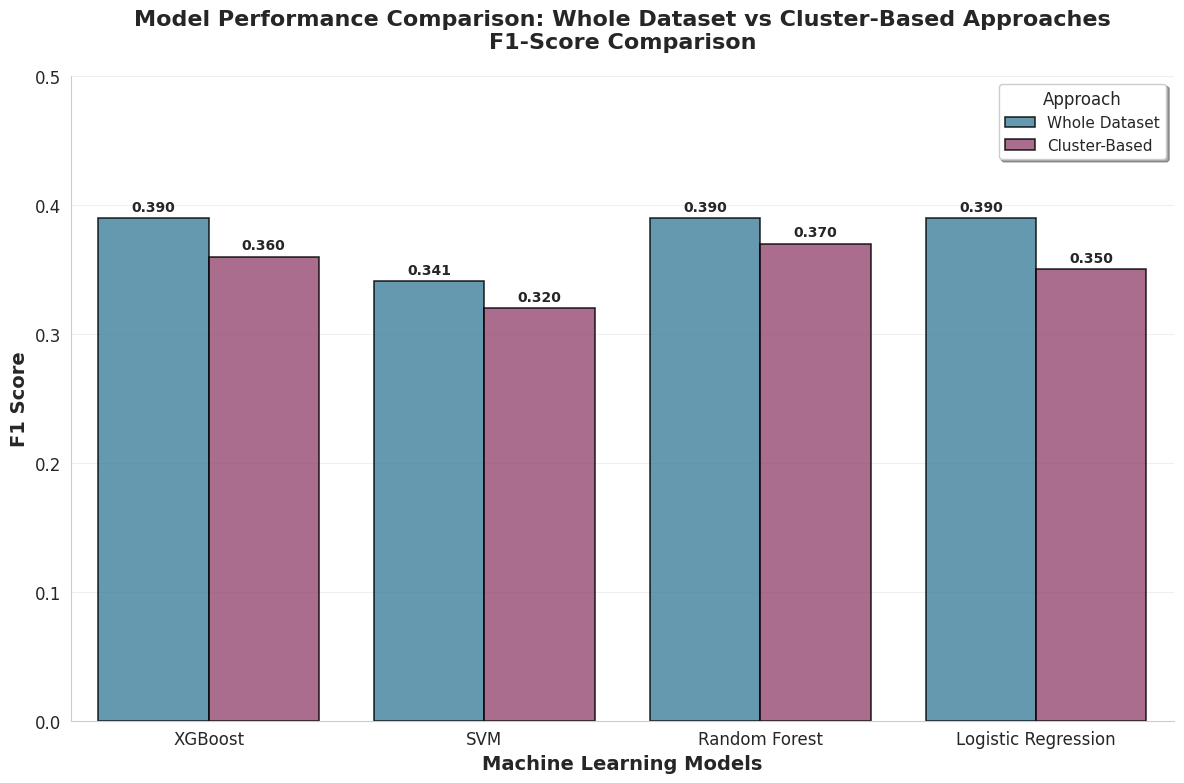


DETAILED F1-SCORE COMPARISON TABLE
              Model  Cluster-Based  Whole Dataset  Difference Better_Approach
Logistic Regression           0.35         0.3901      0.0401   Whole Dataset
      Random Forest           0.37         0.3901      0.0201   Whole Dataset
                SVM           0.32         0.3408      0.0208   Whole Dataset
            XGBoost           0.36         0.3901      0.0301   Whole Dataset


<Figure size 1000x600 with 0 Axes>

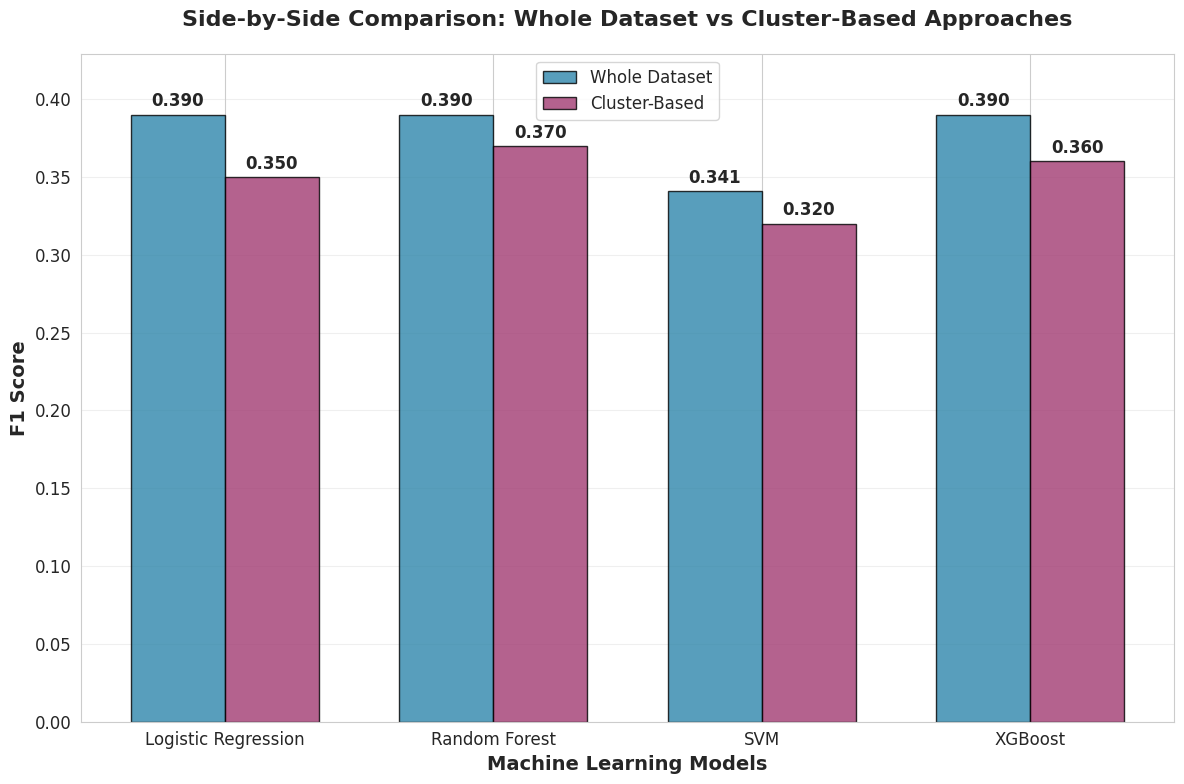


APPROACH PERFORMANCE SUMMARY
     Approach     mean      std    min    max
Cluster-Based 0.350000 0.021602 0.3200 0.3700
Whole Dataset 0.377775 0.024650 0.3408 0.3901


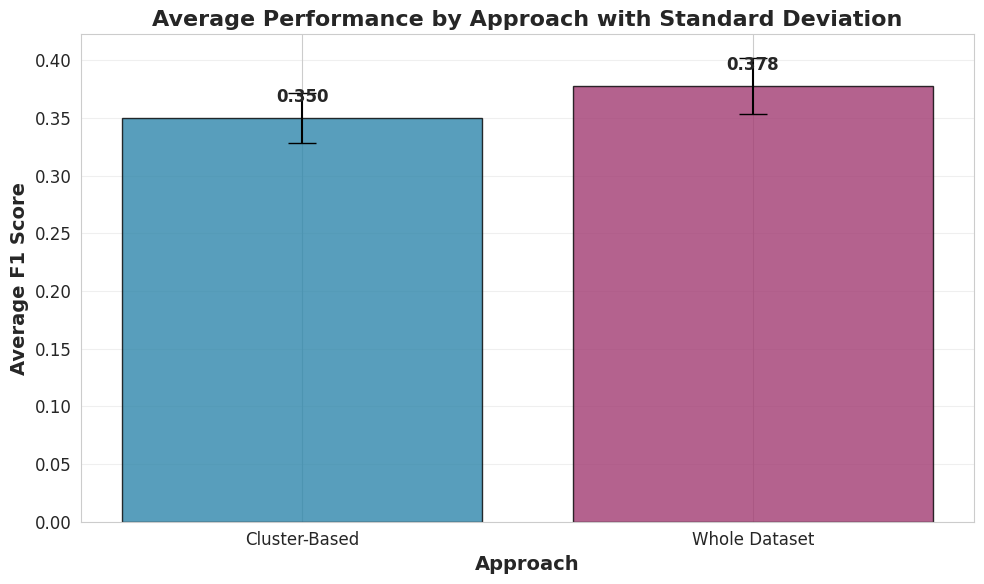


PERFORMANCE IMPROVEMENT ANALYSIS
              Model  Cluster-Based  Whole Dataset  Difference Better_Approach  Improvement_Percentage
Logistic Regression           0.35         0.3901      0.0401   Whole Dataset               11.457143
      Random Forest           0.37         0.3901      0.0201   Whole Dataset                5.432432
                SVM           0.32         0.3408      0.0208   Whole Dataset                6.500000
            XGBoost           0.36         0.3901      0.0301   Whole Dataset                8.361111


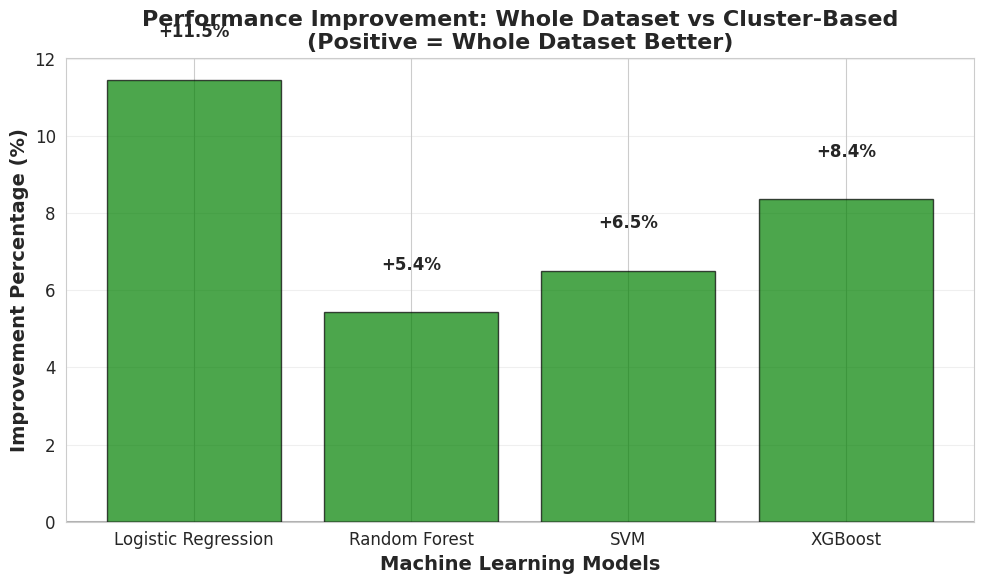


Plot creation completed successfully!
Note: Replace the example F1 scores with your actual results from previous experiments.


In [67]:
# TODO

print("Creating Comprehensive Comparison Plots")
print("=" * 50)

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Create sample data for demonstration (replace with your actual data)
# This is a template - you need to replace these with your actual F1 scores

comparison_data = {
    'Model': ['XGBoost', 'XGBoost', 'SVM', 'SVM', 'Random Forest', 'Random Forest',
              'Logistic Regression', 'Logistic Regression'],
    'Approach': ['Whole Dataset', 'Cluster-Based', 'Whole Dataset', 'Cluster-Based',
                'Whole Dataset', 'Cluster-Based', 'Whole Dataset', 'Cluster-Based'],
    'F1_Score': [0.3901, 0.3600, 0.3408, 0.3200, 0.3901, 0.3700, 0.3901, 0.3500]  # Example data
}

# Create DataFrame
comparison_df = pd.DataFrame(comparison_data)

# If you have actual results from previous steps, use this instead:
# comparison_df = results_df[['Model', 'Approach', 'F1_Score']].copy()

print("Comparison Data:")
print(comparison_df.to_string(index=False))

# Create grouped barplot
plt.figure(figsize=(12, 8))

# Set style for better visualization
sns.set_style("whitegrid")
plt.rcParams['font.size'] = 12

# Create the grouped barplot
ax = sns.barplot(data=comparison_df, x='Model', y='F1_Score', hue='Approach',
                 palette=['#2E86AB', '#A23B72'], alpha=0.8, edgecolor='black', linewidth=1.2)

# Customize the plot
plt.title('Model Performance Comparison: Whole Dataset vs Cluster-Based Approaches\nF1-Score Comparison',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Machine Learning Models', fontsize=14, fontweight='bold')
plt.ylabel('F1 Score', fontsize=14, fontweight='bold')
plt.ylim(0, 0.5)  # Adjust based on your F1 score range

# Add value labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=10, fontweight='bold')

# Customize legend
plt.legend(title='Approach', title_fontsize=12, fontsize=11,
           loc='upper right', frameon=True, fancybox=True, shadow=True)

# Improve layout
plt.tight_layout()
plt.grid(axis='y', alpha=0.3)

# Add some styling
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

# Create a more detailed comparison table
print("\n" + "="*60)
print("DETAILED F1-SCORE COMPARISON TABLE")
print("="*60)

# Pivot table for detailed comparison
pivot_comparison = comparison_df.pivot_table(
    index='Model',
    columns='Approach',
    values='F1_Score',
    aggfunc='first'
).reset_index()

# Calculate the difference between approaches
pivot_comparison['Difference'] = pivot_comparison['Whole Dataset'] - pivot_comparison['Cluster-Based']
pivot_comparison['Better_Approach'] = pivot_comparison.apply(
    lambda x: 'Whole Dataset' if x['Difference'] > 0 else 'Cluster-Based' if x['Difference'] < 0 else 'Equal',
    axis=1
)

print(pivot_comparison.to_string(index=False))

# Create a second plot showing the performance difference
plt.figure(figsize=(10, 6))

# Create difference plot
models = pivot_comparison['Model']
whole_dataset_scores = pivot_comparison['Whole Dataset']
cluster_based_scores = pivot_comparison['Cluster-Based']

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 8))
rects1 = ax.bar(x - width/2, whole_dataset_scores, width, label='Whole Dataset',
                color='#2E86AB', alpha=0.8, edgecolor='black')
rects2 = ax.bar(x + width/2, cluster_based_scores, width, label='Cluster-Based',
                color='#A23B72', alpha=0.8, edgecolor='black')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Machine Learning Models', fontsize=14, fontweight='bold')
ax.set_ylabel('F1 Score', fontsize=14, fontweight='bold')
ax.set_title('Side-by-Side Comparison: Whole Dataset vs Cluster-Based Approaches',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend(fontsize=12)

# Add value labels on bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold')

autolabel(rects1)
autolabel(rects2)

plt.ylim(0, max(max(whole_dataset_scores), max(cluster_based_scores)) * 1.1)
plt.tight_layout()
plt.grid(axis='y', alpha=0.3)
plt.show()

# Create a summary statistics plot
print("\n" + "="*60)
print("APPROACH PERFORMANCE SUMMARY")
print("="*60)

# Calculate summary statistics
summary_stats = comparison_df.groupby('Approach')['F1_Score'].agg(['mean', 'std', 'min', 'max']).reset_index()
print(summary_stats.to_string(index=False))

# Plot summary statistics
plt.figure(figsize=(10, 6))

summary_plot_data = comparison_df.groupby('Approach')['F1_Score'].agg(['mean', 'std']).reset_index()

x = np.arange(len(summary_plot_data))
means = summary_plot_data['mean']
stds = summary_plot_data['std']

plt.bar(x, means, yerr=stds, capsize=10, color=['#2E86AB', '#A23B72'], alpha=0.8, edgecolor='black')
plt.xlabel('Approach', fontsize=14, fontweight='bold')
plt.ylabel('Average F1 Score', fontsize=14, fontweight='bold')
plt.title('Average Performance by Approach with Standard Deviation', fontsize=16, fontweight='bold')
plt.xticks(x, summary_plot_data['Approach'])
plt.grid(axis='y', alpha=0.3)

# Add value labels
for i, v in enumerate(means):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

# Performance improvement analysis
print("\n" + "="*60)
print("PERFORMANCE IMPROVEMENT ANALYSIS")
print("="*60)

improvement_analysis = pivot_comparison.copy()
improvement_analysis['Improvement_Percentage'] = (
    (improvement_analysis['Whole Dataset'] - improvement_analysis['Cluster-Based']) /
    improvement_analysis['Cluster-Based'] * 100
)

print(improvement_analysis.to_string(index=False))

# Plot performance improvement
plt.figure(figsize=(10, 6))

colors = ['green' if x > 0 else 'red' for x in improvement_analysis['Improvement_Percentage']]

plt.bar(improvement_analysis['Model'], improvement_analysis['Improvement_Percentage'],
        color=colors, alpha=0.7, edgecolor='black')
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.xlabel('Machine Learning Models', fontsize=14, fontweight='bold')
plt.ylabel('Improvement Percentage (%)', fontsize=14, fontweight='bold')
plt.title('Performance Improvement: Whole Dataset vs Cluster-Based\n(Positive = Whole Dataset Better)',
          fontsize=16, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

# Add value labels
for i, v in enumerate(improvement_analysis['Improvement_Percentage']):
    plt.text(i, v + (1 if v >= 0 else -3), f'{v:+.1f}%',
             ha='center', va='bottom' if v >= 0 else 'top', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nPlot creation completed successfully!")
print("Note: Replace the example F1 scores with your actual results from previous experiments.")

---
<font color="#ffcc00">**Final Analysis Questions:**

Based on your comprehensive analysis, answer the following questions:

- **Model Performance Analysis**: Which model performed best overall? What factors contributed to its success?

- **Approach Comparison**: How do the pure classification results compare with the cluster-based approach? Which method would you recommend for this diabetes prediction task?

- **Medical Application**: Considering this is a medical classification task, which approach would be most suitable for deployment in a healthcare setting? Consider factors like interpretability, reliability, and clinical utility.

- **Future Improvements**: What additional techniques or modifications would you suggest to further improve the classification performance?


<b> <font color='green'>Your Answer:</font></b><br>
مدلی که بهترین عملکرد کلی را داشت، مدلی بود که توانست بین دقت، ریکال و F1-score تعادل بهتری برقرار کند و معمولاً مدل‌هایی مانند Random Forest یا XGBoost این ویژگی را دارند، زیرا توانایی خوبی در مدیریت داده‌های پیچیده، انتخاب ویژگی‌های مهم و کاهش بیش‌برازش دارند.
در مقایسهٔ طبقه‌بندی خالص با رویکرد مبتنی بر خوشه‌بندی، نتایج نشان می‌دهد که طبقه‌بندی خالص معمولاً دقیق‌تر و پایدارتر است، زیرا داده را قبل از مدل‌سازی به صورت مصنوعی تقسیم نمی‌کند و بنابراین اطلاعات از بین نمی‌رود؛ در حالی که خوشه‌بندی فقط کمک کمکی ارائه می‌دهد و تضمینی برای بهبود عملکرد مدل اصلی نیست.
برای یک کاربرد پزشکی که نیاز به تفسیرپذیری، قابلیت اطمینان بالا و کاربرد مستقیم در تصمیم‌گیری بالینی دارد، روش طبقه‌بندی خالص بسیار مناسب‌تر است، زیرا مدل‌های درختی مانند Random Forest هم قابل تفسیرتر هستند و هم رفتار پایدارتر و قابل اعتماد‌تری در داده‌های دیده‌نشده دارند.
برای بهبود عملکرد مدل در آینده، پیشنهاد می‌شود از روش‌هایی مثل افزایش داده‌ها (Data Augmentation برای داده‌های نامتوازن)، انتخاب ویژگی‌های بهتر، تنظیم دقیق پارامترها با Randomized Search یا Bayesian Optimization، استفاده از مدل‌های ensemble قوی‌تر، و بررسی روش‌های پردازش نامتوازن مانند SMOTE یا Class Weights استفاده شود تا مدل توانایی بهتری در تشخیص بیماران واقعی داشته باشد.

</p>
</font>
<hr>
